# Transcription Factor Project - Replogle et al. (2022) K562 Dataset Figures
**Robin Anwyl, UCSD Subramaniam Lab**

**Goal:** Analyze the KOLF2.1J genome-wide Perturb-seq dataset from the Nourreddine et al. (2024) preprint to investigate the effects of transcription factor knockdowns (TF KDs). Compare to the Replogle et al. (2022) K562 genome-wide Perturb-seq dataset to explore cell-type-specific transcriptional regulatory networks in hiPSCs vs. chronic myeloid leukemia cells.

**Guiding Questions:** What do TF KD effects reveal about:
* the transcriptional regulatory network of hiPSCs and K562 cells?
* TF crosstalk and co-regulation?
* cell lineage?
* how TFs influence chromatin remodeling?

***

# Import statements

Using psp_env virtual env

In [1]:
import sys
import os
psp_root = "/home/ranwyl/KOLF2.1J_Perturbation_Cell_Atlas/"
if psp_root not in sys.path:
    sys.path.insert(0, psp_root)

import psp

In [2]:
import anndata as ad
import numpy as np
import pandas as pd
import decoupler as dc
import gseapy as gp
from tqdm_joblib import tqdm_joblib
from joblib import Parallel, delayed
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
from matplotlib.patches import Patch
import seaborn as sns
from PyComplexHeatmap import ClusterMapPlotter, HeatmapAnnotation, anno_simple
sns.set_style("white")
from biothings_client import get_client
import warnings
from contextlib import contextmanager

In [3]:
def validate_3_DGE_results_dfs(DGE_results_dfs: list[pd.DataFrame]
                               ) -> list[pd.DataFrame]:
    """
    Check that 3 DGE analysis results DFs have same rows and cols.
    """
    if not len(DGE_results_dfs) == 3:
        raise ValueError("Input must be list of 3 DataFrames")
    DGE_results_1 = DGE_results_dfs[0].sort_index()
    DGE_results_2 = DGE_results_dfs[1].sort_index()
    DGE_results_3 = DGE_results_dfs[2].sort_index()
    if not (DGE_results_1.index.equals(DGE_results_2.index) and 
            DGE_results_2.index.equals(DGE_results_3.index)):
        raise ValueError("DGE results DataFrames must have same index (genes)")
    if not ((set(DGE_results_1.columns) == set(DGE_results_2.columns)) &
            (set(DGE_results_2.columns) == set(DGE_results_3.columns))):
        raise ValueError("DGE results DataFrames must have same columns (KDs)")
    # Return DFs with sorted index
    return [DGE_results_1, DGE_results_2, DGE_results_3]

def build_3_run_DEGs_dict(
        DGE_results_dfs: list[pd.DataFrame],
        p_threshold: float,
        p_threshold_type: str="pvalue",
        report_direction: bool=False,
        remove_self_DEGs: bool=False,
        target_type: str="gRNA",
        lfc_threshold: float = 0,
        lfc_col: str = "log2FoldChange",
        validate: bool=True
        ) -> dict[str, set[str]] | dict[str, dict[str, set[str]]]:
    """
    For each KD, find genes that are DEGs of that KD (pass significance and 
    LFC thresholds) with the same LFC sign in at least 2 DGE analysis runs.
    If direction = True, return dict {'KD': {'UP': up_DEGs, 'DOWN': down_DEGs}}.
    If direction = False, return dict {'KD': all_DEGs}
    """
    # Check for valid significance threshold
    if p_threshold_type not in ("pvalue", "padj"):
        raise ValueError("p_threshold_type must be 'pvalue' or 'padj'")
    # Check for valid target type
    if target_type not in ("gRNA", "gene_target"):
        raise ValueError("target_type must be 'gRNA' or 'gene_target'")
    # Check that 3 DGE analysis results DFs have same rows and cols
    if validate:
        DGE_results_dfs = validate_3_DGE_results_dfs(DGE_results_dfs)
    
    # Find genes that are DEGs of the same KD in at least 2 DGE runs
    DGE_results_1, DGE_results_2, DGE_results_3 = \
        DGE_results_dfs[0], DGE_results_dfs[1], DGE_results_dfs[2]
    if target_type == "gRNA":
        targets = {"_".join(col.split("_")[:2]) for col in DGE_results_1.columns}
    else:
        targets = {col.split("_")[0] for col in DGE_results_1.columns}
    targets = sorted(list(targets))
    DEGs_dict = dict()
    for target in targets:
        target_p_col = f"{target}_{p_threshold_type}"
        target_lfc_col = f"{target}_{lfc_col}"
        DEGs_run1_up = set(
            DGE_results_1.loc[(DGE_results_1[target_p_col] < p_threshold) & 
            (DGE_results_1[target_lfc_col] > lfc_threshold)].index)
        DEGs_run1_down = set(
            DGE_results_1.loc[(DGE_results_1[target_p_col] < p_threshold) & 
            (DGE_results_1[target_lfc_col] < (-1*lfc_threshold))].index)
        DEGs_run2_up = set(
            DGE_results_2.loc[(DGE_results_2[target_p_col] < p_threshold) & 
            (DGE_results_2[target_lfc_col] > lfc_threshold)].index)
        DEGs_run2_down = set(
            DGE_results_2.loc[(DGE_results_2[target_p_col] < p_threshold) & 
            (DGE_results_2[target_lfc_col] < (-1*lfc_threshold))].index)
        DEGs_run3_up = set(
            DGE_results_3.loc[(DGE_results_3[target_p_col] < p_threshold) & 
            (DGE_results_3[target_lfc_col] > lfc_threshold)].index)
        DEGs_run3_down = set(
            DGE_results_3.loc[(DGE_results_3[target_p_col] < p_threshold) & 
            (DGE_results_3[target_lfc_col] < (-1*lfc_threshold))].index)
        DEGs_up = ((DEGs_run1_up & DEGs_run2_up) | (DEGs_run2_up & DEGs_run3_up) |
                   (DEGs_run1_up & DEGs_run3_up))
        DEGs_down = ((DEGs_run1_down & DEGs_run2_down) | 
                     (DEGs_run2_down & DEGs_run3_down) |
                     (DEGs_run1_down & DEGs_run3_down))
        # Remove gene target from DEG list
        if remove_self_DEGs:
            self_gene = target if target_type == "gene_target" else target.split("_")[0]
            DEGs_up = DEGs_up - {self_gene}
            DEGs_down = DEGs_down - {self_gene}
        DEGs_dict[target] = {"UP": DEGs_up, "DOWN": DEGs_down} if report_direction \
            else (DEGs_up | DEGs_down)
    return DEGs_dict

def build_3_run_n_DEGs_df(
        DEGs_dict: dict[str, set[str]] | dict[str, dict[str, set[str]]],
        report_direction: bool=False
        ) -> pd.DataFrame:
    """
    From a dict of DEGs for each KD, build a DataFrame reporting
    the number of DEGs per KD.
    """
    kds = list(DEGs_dict.keys())
    if not report_direction:
        if isinstance(next(iter(DEGs_dict.values())), dict):
            n_DEGs = [len(degs["UP"] | degs["DOWN"]) for degs in DEGs_dict.values()]
        else:
            n_DEGs = [len(DEGs_dict[kd]) for kd in kds]
        n_DEGs_df = pd.DataFrame(n_DEGs, index=kds, columns=["n_DEGs"])
    else:
        if isinstance(next(iter(DEGs_dict.values())), dict):
            n_up_DEGs = [len(degs["UP"]) for degs in DEGs_dict.values()]
            n_down_DEGs = [len(degs["DOWN"]) for degs in DEGs_dict.values()]
            n_DEGs_df = pd.DataFrame({"n_up_DEGs": n_up_DEGs,
                                      "n_down_DEGs": n_down_DEGs}, index=kds)
            n_DEGs_df["n_DEGs"] = n_DEGs_df["n_up_DEGs"] + n_DEGs_df["n_down_DEGs"]
        else:
            raise ValueError("No DEG direction provided")
    n_DEGs_df = n_DEGs_df.sort_values(by="n_DEGs", ascending=False)
    return n_DEGs_df

def build_3_run_DEGs_df(
        DEGs_dict: dict[str, set[str]] | dict[str, dict[str, set[str]]],
        kd_col: str="KD") -> pd.DataFrame:
    """
    From a dict of DEGs for each KD, build a DataFrame of each KD,
    DEG count, and DEGs.
    """
    kds = list(DEGs_dict.keys())
    if isinstance(next(iter(DEGs_dict.values())), dict):
        up_DEGs = [", ".join(degs["UP"]) for degs in DEGs_dict.values()]
        n_up_DEGs = np.array([len(degs["UP"]) for degs in DEGs_dict.values()])
        down_DEGs = [", ".join(degs["DOWN"]) for degs in DEGs_dict.values()]
        n_down_DEGs = np.array([len(degs["DOWN"]) for degs in DEGs_dict.values()])
        n_total_DEGs = n_up_DEGs + n_down_DEGs
        DEGs_df = pd.DataFrame({kd_col: kds,
                                "n_total_DEGs": n_total_DEGs,
                                "n_up_DEGs": n_up_DEGs,
                                "n_down_DEGs": n_down_DEGs,
                                "up_DEGs": up_DEGs,
                                "down_DEGs": down_DEGs})
        DEGs_df = DEGs_df.sort_values(by="n_total_DEGs", ascending=False)
    else:
        n_DEGs = [len(DEGs_dict[kd]) for kd in kds]
        DEGs = [", ".join(DEGs_dict[kd]) for kd in kds]
        DEGs_df = pd.DataFrame({kd_col: kds, "n_DEGs": n_DEGs, "DEGs": DEGs})
        DEGs_df = DEGs_df.sort_values(by="n_DEGs", ascending=False)
    DEGs_df = DEGs_df.reset_index(drop=True)
    return DEGs_df

def build_3_run_wald_dict(DGE_results_dfs: list[pd.DataFrame],
                          wald_col: str="stat",
                          wald_abs_threshold: float = 1,
                          validate: bool = True,
                          kds: list[str] | set[str] | None = None,
                          remove_target_gene: bool=True,
                          ) -> dict[str, set[str]]:
    """
    For each KD, find genes that have |Wald| > wald_abs_threshold 
    in at least 2 DGE analysis runs.
    """
    # Check that 3 DGE analysis results DFs have same rows and cols
    if validate:
        DGE_results_dfs = validate_3_DGE_results_dfs(DGE_results_dfs)

    # For each KD, find genes with |Wald| > 1 in at least 2 runs
    DGE_results_1, DGE_results_2, DGE_results_3 = \
        DGE_results_dfs[0], DGE_results_dfs[1], DGE_results_dfs[2]
    if kds is None:
        kds = {col.split("_")[0] for col in DGE_results_1.columns}
    kds = sorted(list(kds))
    wald_dict = dict()
    for kd in kds:
        kd_wald_col = f"{kd}_{wald_col}"
        wald_genes_run1 = set(DGE_results_1.loc[
            abs(DGE_results_1[kd_wald_col]) > wald_abs_threshold].index)
        wald_genes_run2 = set(DGE_results_2.loc[
            abs(DGE_results_2[kd_wald_col]) > wald_abs_threshold].index)
        wald_genes_run3 = set(DGE_results_3.loc[
            abs(DGE_results_3[kd_wald_col]) > wald_abs_threshold].index)                                
        wald_genes_at_least_2 = ((wald_genes_run1 & wald_genes_run2) | 
                                 (wald_genes_run2 & wald_genes_run3) |
                                 (wald_genes_run1 & wald_genes_run3))
        # Remove target gene from gene list
        if remove_target_gene:
            wald_genes_at_least_2 = wald_genes_at_least_2 - {kd}
        wald_dict[kd] = wald_genes_at_least_2
    return wald_dict

def build_cluster_DEGs_dict(DEGs_dict: dict[str, set[str]],
                            cluster_df: pd.DataFrame
                            ) -> dict[int, set[str]]:
    """
    Build dict of DEGs per cluster.
    """
    cluster_kd_dict = {
        int(cl): list(cluster_df[cl][cluster_df[cl].notna()])
        for cl in cluster_df.columns
    }
    cluster_DEGs_dict = {
        cl: set().union(*[DEGs_dict[kd] for kd in cluster_kd_dict[cl]])
        for cl in cluster_kd_dict
    }
    return cluster_DEGs_dict

def plot_n_DEGs_per_cluster(cluster_DEGs_dict: dict[int, set[str]],
                            title: str, 
                            figsize: tuple[int, int] = (6,3), 
                            xlabel: str="Cluster", 
                            xtick_rotation: int=90,
                            ymax: int | None = None,
                            color: str = "tab:blue"):
    """
    Given a dict of DEGs per cluster, plot number of DEGs per cluster.
    """
    clusters = [f"CL{str(cl)}" for cl in cluster_DEGs_dict.keys()]
    n_DEGs = [len(cluster_DEGs_dict[cl]) for cl in cluster_DEGs_dict.keys()]
    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(x=clusters, y=n_DEGs, ax=ax, color=color)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("# DEGs per cluster")
    for container in ax.containers:
        ax.bar_label(container, fmt='%.0f', padding=2, fontsize=10, rotation=90)
    plt.xticks(fontsize=11, rotation=xtick_rotation)
    plt.yticks(fontsize=11)
    ax.yaxis.set_major_formatter('{x:.0f}')
    if ymax:
        ax.set_ylim(0, ymax)
    ax.set_title(title)

def build_strong_kds_per_cluster_df(DEGs_dict: dict[str, set[str]],
                                    cluster_df: pd.DataFrame,
                                    DEG_threshold_inclusive: int=10,
                                    kd_label: str="KD"):
    kds = list(DEGs_dict.keys())
    n_DEGs = [len(DEGs_dict[kd]) for kd in kds]
    n_DEGs_df = pd.DataFrame(n_DEGs, index=kds, columns=["n_DEGs"])
    n_DEGs_df = n_DEGs_df[n_DEGs_df["n_DEGs"] >= DEG_threshold_inclusive]
    cluster_kd_dict = {
        int(cl): list(cluster_df[cl][cluster_df[cl].notna()])
        for cl in cluster_df.columns
    }
    cluster_strong_kd_dict = {
        cl: [kd for kd in cluster_kd_dict[cl] if kd in n_DEGs_df.index]
        for cl in cluster_kd_dict
    }
    strong_kds_per_cluster_df = \
        pd.DataFrame({f"{kd_label}s w/ ≥{DEG_threshold_inclusive} DEGs per cluster": 
                      [len(cluster_strong_kd_dict[cl]) 
                       for cl in cluster_strong_kd_dict]},
                       index=[cl for cl in cluster_kd_dict])
    return strong_kds_per_cluster_df

def plot_n_kds_per_cluster(
        cluster_df: pd.DataFrame, 
        title: str,
        kd_label: str="KD",
        figsize: tuple[int, int] = (6,3), 
        xlabel: str="Cluster", 
        xtick_rotation: int=90,
        ymax: int | None = None,
        color: str = "tab:blue"):
    """
    Plot number of perturbations per cluster.
    """
    sns.set_style("whitegrid")
    n_kds_per_cluster = cluster_df.count()
    xvals = [f"CL{str(i)}" for i in range(len(n_kds_per_cluster))]
    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(x=xvals, y=n_kds_per_cluster, ax=ax,
                color=color)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(f"# {kd_label}s in cluster")
    plt.xticks(fontsize=11, rotation=xtick_rotation)
    plt.yticks(fontsize=11)
    ax.yaxis.set_major_formatter('{x:.0f}')
    for container in ax.containers:
        ax.bar_label(container, fmt='%.0f', padding=2, fontsize=10)
    if ymax:
        ax.set_ylim(0, ymax)
    ax.set_title(title)

# Read in data

In [78]:
filepath = "/home/ranwyl/data_tf_project/K562_QC_NTC_norm_KDefficiency_Etest_gRNA_filtered.h5ad"
adata_k562 = psp.utils.read_anndata(filepath)
adata_k562

AnnData object with n_obs × n_vars = 244096 × 8246
    obs: 'gem_group', 'gene', 'gene_id', 'transcript', 'gene_transcript', 'sgID_AB', 'chromium_batch', 'sequencing_lane', 'well_plate', 'mitopercent', 'UMI_count', 'z_gemgroup_UMI', 'core_scale_factor', 'core_adjusted_UMI_count', 'celltype', 'perturbation_type', 'n_genes', 'perturbed', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'gene_target_expression (CPM)', 'NTC_target_gene_expression (CPM)', 'target_knockdown', 'target_detected', 'perturbation', 'perturbation_edist', 'perturbation_pvalue', 'perturbation_significant'
    var: 'gene_id', 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano', 'n_cells', 'mt', 'ribo', 'hb', 'n_cel

In [20]:
filepath1 = "/home/ranwyl/results_tf_project/K562_DE_results_KD_shrunk_seed42_5-14-26.pkl"
de_results_k562_1 = pd.read_pickle(filepath1)
filepath2 = "/home/ranwyl/results_tf_project/K562_DE_results_KD_shrunk_seed12_5-14-26.pkl"
de_results_k562_2 = pd.read_pickle(filepath2)
filepath3 = "/home/ranwyl/results_tf_project/K562_DE_results_KD_shrunk_seed123_5-14-26.pkl"
de_results_k562_3 = pd.read_pickle(filepath3)
de_results_k562 = [de_results_k562_1, de_results_k562_2, de_results_k562_3]

In [21]:
kd_deg_dict_k562 = build_3_run_DEGs_dict(de_results_k562, p_threshold=0.005,
                                         p_threshold_type="pvalue", target_type="gene_target",
                                         remove_self_DEGs=True)
n_degs_df_k562 = build_3_run_n_DEGs_df(kd_deg_dict_k562)
n_degs_df_k562[0:20]

,n_DEGs
DNMT1,405
CXXC1,164
MAX,149
MYB,140
TFDP1,127
TBX1,119
ETV4,106
NKX6-1,103
SETDB1,93
ZBTB17,76


In [22]:
kd_deg_dict_k562_self_degs = build_3_run_DEGs_dict(de_results_k562, p_threshold=0.005,
                                    p_threshold_type="pvalue", target_type="gene_target",
                                    remove_self_DEGs=False)
kd_deg_dict_k562_self_degs_direction = build_3_run_DEGs_dict(de_results_k562, p_threshold=0.005,
                                    p_threshold_type="pvalue", target_type="gene_target",
                                    remove_self_DEGs=False, report_direction=True)

In [23]:
kd_subset = set(n_degs_df_k562[n_degs_df_k562['n_DEGs'] > 4].index)
print(f"{len(kd_subset)} out of {len(n_degs_df_k562)} TF KDs have >4 DEGs (excluding self-DEGs)")

429 out of 916 TF KDs have >4 DEGs (excluding self-DEGs)


In [ ]:
kd_wald_dict_k562 = build_3_run_wald_dict(de_results_k562, remove_target_gene=True)

In [24]:
leiden_clusters_filepath = \
    "/home/ranwyl/output_files_tf_project/K562_leiden_clusters_spectral25-mde7-knn6-repulsive5_6-4-26.csv"
leiden_clusters_k562 = pd.read_csv(leiden_clusters_filepath, header=0, index_col=0)
leiden_clusters_k562.head(3)
tf_kd_to_leiden_cluster_k562 = {kd: int(cl) for cl in leiden_clusters_k562.columns for kd in 
                                set(leiden_clusters_k562[cl][leiden_clusters_k562[cl].notna()])}

In [25]:
hdbscan_clusters_filepath = \
    "/home/ranwyl/output_files_tf_project/K562_hdbscan_clusters_6-3-26.csv"
hdbscan_clusters_k562 = pd.read_csv(hdbscan_clusters_filepath, header=0, index_col=0)
hdbscan_clusters_k562.head(3)
tf_kd_to_hdbscan_cluster_k562 = {kd: int(cl) for cl in hdbscan_clusters_k562.columns for kd in 
                                set(hdbscan_clusters_k562[cl][hdbscan_clusters_k562[cl].notna()])}
non_hdbscan_tf_kds = set(tf_kd_to_leiden_cluster_k562.keys()) - set(tf_kd_to_hdbscan_cluster_k562.keys())
tf_kd_to_hdbscan_cluster_k562.update({kd: -1 for kd in non_hdbscan_tf_kds})

# Functions + references for GSEA, decoupler ULM TF + pathway activity inference, DEG heatmaps

In [4]:
@contextmanager
def handle_warnings(suppress):
    if suppress:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            yield
    else:
        yield

def prerank_gsea_all_kds(
        cluster_df: pd.DataFrame,
        DGE_results_dfs: list[pd.DataFrame],
        gene_set_name: str,
        cell_line: str,
        add_jitter: bool=True,
        wald_label: str="stat",
        min_term_size: int=15, 
        max_term_size: int=200,
        permutation_num: int=1000,
        n_cpus_per_job: int=4,
        n_jobs: int=8,
        random_seed: int=42,
        verbose: bool=False,
        kd_col: str="KD",
        cluster_col: str="Cluster",
        gene_set_col: str="Gene set",
        cell_line_col: str="Cell line",
        suppress_warnings: bool=False
        ) -> pd.DataFrame:
    """
    Run pre-ranked GSEA, using the given Enrichr library, on each 
    individual KD in a dataset. For each KD, compute mean Wald test
    statistic of each gene across 3 DGE analysis runs and rank genes by
    mean Wald. min_size controls minimum number of genes in the intersection
    of the dataset and each gene set term. max_size controls maximum number of
    genes in each gene set term.
    """
    # Get KDs
    kds = cluster_df.values.flatten().tolist()
    kds = [kd for kd in kds if isinstance(kd, str)] # Remove NaN column padding
    kd_to_cluster = {kd: int(col) for col in cluster_df.columns 
                     for kd in cluster_df[col].dropna()}
    # Check for duplicates
    assert len(kd_to_cluster) == len(kds), (
        f"{len(kds) - len(kd_to_cluster)} KD(s) appear in multiple clusters")

    # Get Enrichr library
    gene_set = gp.get_library(gene_set_name, organism="Human",
                              min_size=min_term_size, max_size=max_term_size)
    
    # Check that 3 DGE analysis results DFs have same rows and cols
    DGE_results_dfs = validate_3_DGE_results_dfs(DGE_results_dfs)
    # Subset DGE results to Wald columns only
    wald_cols = [col for col in DGE_results_dfs[0].columns if col.endswith(f"_{wald_label}")]
    DGE_results_dfs = [df[wald_cols] for df in DGE_results_dfs]
    
    # Helper function to run GSEA on single KD
    def process_kd(kd):
        # Compute mean Wald per gene
        wald_col = f"{kd}_{wald_label}"
        wald_df_1 = pd.DataFrame(DGE_results_dfs[0][wald_col].values,
                                 index=DGE_results_dfs[0].index, 
                                 columns=[wald_label])
        wald_df_2 = pd.DataFrame(DGE_results_dfs[1][wald_col].values,
                                 index=DGE_results_dfs[1].index, 
                                 columns=[wald_label])
        wald_df_3 = pd.DataFrame(DGE_results_dfs[2][wald_col].values,
                                 index=DGE_results_dfs[2].index, 
                                 columns=[wald_label])
        wald_df = (wald_df_1 + wald_df_2 + wald_df_3) / 3
        # Drop NaN genes and gene that was KD
        if kd in wald_df.index:
            wald_df.loc[kd] = np.nan
        wald_df.dropna(axis="index", inplace=True)
        # Sort and format Wald DF
        wald_df.sort_values(by=wald_label, ascending=False, inplace=True)
        wald_df.index.name = "gene"
        # Add negligible jitter to break ties
        if add_jitter:
            jitter = 1e-9 * np.arange(len(wald_df))
            wald_df[wald_label] = wald_df[wald_label].values - jitter

        # Run pre-ranked GSEA
        kd_gsea_result = \
            gp.prerank(rnk=wald_df,
                        gene_sets=gene_set,
                        threads=n_cpus_per_job,
                        min_size=min_term_size,
                        max_size=max_term_size,
                        permutation_num=permutation_num,
                        outdir=None,
                        seed=random_seed,
                        verbose=verbose,
                        )
        return kd_gsea_result
    
    # Run pre-ranked GSEA on all KDs
    with handle_warnings(suppress_warnings):
        with tqdm_joblib(desc="Running pre-ranked GSEA", 
                                total=len(kds)):
            kd_gsea_results = Parallel(n_jobs=n_jobs)(
                delayed(process_kd)(kd) for kd in kds)
    kd_gsea_results_dict = dict(zip(kds, kd_gsea_results))

    # Build results DF
    gsea_results_list = list()
    for kd in kd_gsea_results_dict: # Build results DF for KD
        kd_res_df = kd_gsea_results_dict[kd].res2d.copy()
        kd_res_df.insert(0, kd_col, [kd]*kd_res_df.shape[0]) # KD column
        kd_res_df.drop(columns=["Name"], inplace=True)
        gsea_results_list.append(kd_res_df)
    gsea_results_df = pd.concat(gsea_results_list)
    # Add gene set, cluster, and cell line info
    gsea_results_df.insert(1, gene_set_col, [gene_set_name]*len(gsea_results_df))
    gsea_results_df.insert(0, cluster_col, gsea_results_df[kd_col].map(kd_to_cluster))
    gsea_results_df.insert(0, cell_line_col, [cell_line]*len(gsea_results_df))

    # Check that all KDs are in DF
    gsea_kds = set(gsea_results_df[kd_col])
    missing_kds = set(kds) - gsea_kds
    if missing_kds:
        print(f"Warning: {len(missing_kds)} KDs missing from GSEA results ({', '.join(missing_kds)})")
    
    return gsea_results_df

In [5]:
def build_enriched_gsea_terms_df(
        gsea_results_df: pd.DataFrame,
        DGE_results_dfs: list[pd.DataFrame],
        fdr_threshold: float=0.05,
        fdr_col: str="FDR q-val",
        min_absolute_nes: None | float = None, 
        nes_col: str="NES",
        DGE_p_threshold: float = 0.05,
        DGE_p_threshold_type: str="pvalue",
        wald_label: str = "stat",
        wald_abs_threshold: int=1,
        leading_genes_col: str="Lead_genes",
        genes_sep_char: str=";",
        kd_DEG_dict: dict[str, set[str]] | None = None,
        kd_wald_dict: dict[str, set[str]] | None = None,
        cluster_col: str="Cluster",
        kd_col: str="KD",
    ) -> pd.DataFrame:
    """
    Subset the GSEA results DF to only enriched terms
    and add info on leading genes that are DEGs and
    that have |Wald| > 1 in at least 2 DGE analysis runs.
    """
    # Check that 3 DGE analysis results DFs have same rows and cols
    DGE_results_dfs = validate_3_DGE_results_dfs(DGE_results_dfs)

    # Subset to enriched terms (by FDR and NES)
    gsea_results_df = \
        gsea_results_df[gsea_results_df[fdr_col] < fdr_threshold]
    if min_absolute_nes:
        gsea_results_df = \
            gsea_results_df[gsea_results_df[nes_col] >= min_absolute_nes]
    enriched_results_df = gsea_results_df.copy()
    
    # Add info on leading genes that pass DE significance threshold
    #   and have |Wald| > threshold in at least 2 DGE runs
    # Build dict {KD: {DEGs}}
    kds = set(gsea_results_df[kd_col].values)
    if not kd_DEG_dict:
        kd_DEG_dict = build_3_run_DEGs_dict(DGE_results_dfs, 
                                            p_threshold=DGE_p_threshold,
                                            p_threshold_type=DGE_p_threshold_type,
                                            validate=False)
    kd_DEG_dict = {k:v for k,v in kd_DEG_dict.items() if k in kds}
    # Build dict {KD: {genes with |Wald| > threshold}}
    if not kd_wald_dict:
        kd_wald_dict = build_3_run_wald_dict(DGE_results_dfs, 
                                            wald_col=wald_label,
                                            wald_abs_threshold=wald_abs_threshold,
                                            validate=False)
    kd_wald_dict = {k:v for k,v in kd_wald_dict.items() if k in kds}
    
    # Get leading gene DE + Wald info
    kds_arr = enriched_results_df[kd_col].to_numpy()
    lead_genes_arr = enriched_results_df[leading_genes_col].to_numpy()
    n_de_leading, de_leading_str, n_wald_leading, wald_leading_str = [], [], [], []
    for kd, lead_genes in zip(kds_arr, lead_genes_arr):
        leading_genes = set(s for s in lead_genes.split(genes_sep_char) if s)
        de_leading = leading_genes & kd_DEG_dict.get(kd, set())
        wald_leading = leading_genes & kd_wald_dict.get(kd, set())
        n_de_leading.append(len(de_leading))
        de_leading_str.append(genes_sep_char.join(sorted(de_leading)))
        n_wald_leading.append(len(wald_leading))
        wald_leading_str.append(genes_sep_char.join(sorted(wald_leading)))
    
    # Add leading gene DE + Wald info to DF
    enriched_results_df.insert(10, "# DE lead genes", n_de_leading)
    enriched_results_df.insert(11, f"# lead genes w/ |Wald| > {wald_abs_threshold}", 
                               n_wald_leading)
    enriched_results_df["DE_lead_genes"] = de_leading_str
    enriched_results_df["Wald_lead_genes"] = wald_leading_str
    
    # Sort DF
    enriched_results_df.sort_values(by=[cluster_col, kd_col, nes_col],
                                    ascending=[True, True, False],
                                    inplace=True, ignore_index=True)
    
    return enriched_results_df

def build_shared_gsea_terms_df(
        enriched_results_df: pd.DataFrame,
        n_kds: int,
        kd_col: str="KD",
        nes_col: str="NES",
        gene_set_col: str="Gene set",
        cell_line_col: str="Cell line",
        tag_percent_col: str="Tag %",
        ) -> pd.DataFrame:
    """
    Count how many KDs are enriched for the same term with the same direction
    of enrichment.
    """
    if enriched_results_df[cell_line_col].nunique() != 1:
        raise ValueError("Results must be restricted to one cell line")
    summary_entries = list()
    gene_sets = set(enriched_results_df[gene_set_col])
    for gene_set in gene_sets:
        gene_set_results_df = enriched_results_df[
        enriched_results_df[gene_set_col] == gene_set]
        term_groups = dict(list(gene_set_results_df.groupby("Term", sort=False)))
        for term in term_groups:
            term_df = term_groups[term]
            term_size = term_df[tag_percent_col].values[0].split("/")[1]
            # Up terms
            term_df_up = term_df[(term_df["Term"] == term) &
                                  (term_df[nes_col] > 0)]
            if len(term_df_up) > 0:
                summary_entries.append({
                    gene_set_col: gene_set,
                    "Term": term,
                    "Term Size": term_size,
                    "Direction": "UP",
                    f"# {kd_col}s": term_df_up[kd_col].nunique(),
                    "Mean NES": term_df_up[nes_col].mean().round(3)
                })
            # Down terms
            term_df_down = term_df[(term_df["Term"] == term) &
                                    (term_df[nes_col] < 0)]
            if len(term_df_down) > 0:
                summary_entries.append({
                    gene_set_col: gene_set,
                    "Term": term,
                    "Term Size": term_size,
                    "Direction": "DOWN",
                    f"# {kd_col}s": term_df_down[kd_col].nunique(),
                    "Mean NES": term_df_down[nes_col].mean().round(3)
                })
    summary_df = pd.DataFrame(summary_entries)
    summary_df.insert(4, f"% {kd_col}s", 
        (100*summary_df[f"# {kd_col}s"]/n_kds).astype(int))
    # Rename gene sets
    gene_set_shortnames = {'MSigDB_Hallmark_2020': 'Hallmark',
                           'GO_Biological_Process_2025': 'GO:BP',
                           'Reactome_Pathways_2024': 'Reactome',
                           'KEGG_2026': 'KEGG',
                           'ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X': 'ECC'}
    summary_df[gene_set_col] = summary_df[gene_set_col].map(gene_set_shortnames)
    summary_df.sort_values(by=f"# {kd_col}s", ascending=False, 
                           ignore_index=True, inplace=True)
    return summary_df

def build_cluster_shared_gsea_terms_df(
        enriched_results_df: pd.DataFrame,
        gene_set_name: str,
        cell_line: str,
        min_cluster_kds: int=3,
        min_term_size: int=15, 
        max_term_size: int=200,
        kd_col: str="KD",
        cluster_col: str="Cluster", 
        nes_col: str="NES",
        gene_set_col: str="Gene set",
        cell_line_col: str="Cell line",
        leading_genes_col: str="Lead_genes",
        DE_leading_genes_col: str="DE_lead_genes",
        wald_leading_genes_col: str="Wald_lead_genes",
        wald_abs_threshold: float = 1
        ) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Given a pre-ranked GSEA results DF for a single gene set that contains 
    enriched terms and info on genes that pass DE and |Wald| thresholds, 
    find terms shared between multiple cluster KDs. Return 2 DFs: 
    shared_terms_df containing all shared enriched terms (multiple rows
    per term per cluster) and summary_df where each row summarizes one shared 
    enriched term (one row per term per cluster).
    """
    cluster_results_dfs, summary_entries = list(), list()
    # Get Enrichr library
    enrichr_library = gp.get_library(gene_set_name, organism="Human",
                                 min_size=min_term_size, max_size=max_term_size)
    # Loop through clusters
    clusters = sorted(enriched_results_df[cluster_col].unique().tolist(), key=int)
    for cl in clusters:
        # Get cluster DF
        cl_df = enriched_results_df[enriched_results_df[cluster_col] == cl]
        if cl_df.empty:
            continue
        # Group cluster DF by term for fast lookup
        term_groups = dict(list(cl_df.groupby("Term", sort=False)))
        # Subset to shared terms
        term_counts = cl_df["Term"].value_counts()
        cl_shared_terms = set(term_counts[term_counts >= min_cluster_kds].index)
        cl_shared_direction_terms = set()
        for term in cl_shared_terms:
            # Get only shared terms where all TF KDs have same NES sign
            cl_term_df = term_groups[term]
            nes_values = cl_term_df[nes_col].to_numpy()
            if not (np.all(nes_values > 0) or np.all(nes_values < 0)):
                continue
            cl_shared_direction_terms.add(term)
            # Build summary entry and add to list
            term_kds = sorted(cl_term_df[kd_col].unique().tolist())
            term_lead_genes = \
                {g for genes in cl_term_df[leading_genes_col].values 
                 for g in genes.split(";") if g}
            term_DE_lead_genes = \
                {g for genes in cl_term_df[DE_leading_genes_col].values 
                 for g in genes.split(";") if g}
            term_wald_lead_genes = \
                {g for genes in cl_term_df[wald_leading_genes_col].values 
                 for g in genes.split(";") if g}
            wald_lead_genes_col = f"Total leading genes w/ |Wald| > {wald_abs_threshold}"
            summary_entries.append(
                {cluster_col: cl, 
                 "Term": term, 
                 f"# {kd_col}s": len(term_kds),
                 f"{kd_col}s": ", ".join(term_kds),
                 "Mean NES": round(cl_term_df[nes_col].mean(), 2),
                 "Term size": len(enrichr_library[term]),
                 "Total leading genes": len(term_lead_genes),
                 "Total DE leading genes": len(term_DE_lead_genes),
                 wald_lead_genes_col: len(term_wald_lead_genes)}
                 )
        # Add cluster shared terms DF to list
        cl_df = cl_df[cl_df["Term"].isin(cl_shared_direction_terms)]
        cl_df.sort_values(by=["Term", kd_col], inplace=True)
        cluster_results_dfs.append(cl_df)
    
    # If no enriched terms
    if len(cluster_results_dfs) == 0:
        return pd.DataFrame(), pd.DataFrame()
    
    # Build shared terms DF
    if len(cluster_results_dfs) > 1:
        shared_terms_df = pd.concat(cluster_results_dfs)
        shared_terms_df.reset_index(drop=True, inplace=True)
    else:
        shared_terms_df = cluster_results_dfs[0]
    # Build summary DF
    summary_df = pd.DataFrame(summary_entries)
    summary_df.insert(0, cell_line_col, [cell_line]*len(summary_df))
    summary_df.insert(1, gene_set_col, [gene_set_name]*len(summary_df))
    summary_df.sort_values(by=[cluster_col, "Mean NES", f"# {kd_col}s"], 
                           ascending=[True, False, False],
                           inplace=True, ignore_index=True)

    return shared_terms_df, summary_df

def combine_gsea_dfs(gsea_dfs: list[pd.DataFrame],
                     cluster_col: str="Cluster",
                     kd_col: str="KD",
                     nes_col: str="NES") -> pd.DataFrame:
    """
    Concatenate and sort multiple GSEA results DFs where each row is a term.
    """
    gsea_df = pd.concat(gsea_dfs)
    gsea_df.sort_values(by=[cluster_col, kd_col, nes_col],
                        ascending=[True, True, False],
                        inplace=True, ignore_index=True)
    return gsea_df

def summarize_gsea_df(gsea_df: pd.DataFrame,
                    cluster_df: pd.DataFrame,
                    gene_set_col: str="Gene set",
                    kd_col: str="KD",
                    fdr_threshold: float=0.05,
                    fdr_col: str="FDR q-val",
                    cluster_col: str="Cluster"
                    ) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Given a GSEA results DF where each row is a term, summarize the
    number of enriched terms and enriched KDs per gene set and per cluster.
    """
    gsea_df = gsea_df[gsea_df[fdr_col] < fdr_threshold]

    # Gene set info
    kds = cluster_df.values.flatten().tolist()
    kds = [kd for kd in kds if isinstance(kd, str)]
    total_n_kds = len(kds)
    gene_sets = sorted(gsea_df[gene_set_col].unique().tolist())
    gene_set_n_enriched_terms = list()
    gene_set_n_enriched_kds = list()
    for gene_set in gene_sets:
        df_subset = gsea_df[gsea_df[gene_set_col] == gene_set]
        gene_set_n_enriched_terms.append(len(df_subset))
        gene_set_n_enriched_kds.append(
            f"{df_subset[kd_col].nunique()}/{total_n_kds}")
    gene_set_summary_df = pd.DataFrame({
        "# enriched terms": gene_set_n_enriched_terms,
        f"# {kd_col}s with enriched term(s)": gene_set_n_enriched_kds
        }, index=gene_sets)
    gene_set_summary_df.index.name = gene_set_col
    gene_set_summary_df.sort_values(by="# enriched terms", 
                                    ascending=False, inplace=True)
    
    # Cluster info
    clusters_n_kds = {int(cl): len(cluster_df[cl][cluster_df[cl].notna()])
                      for cl in cluster_df.columns}
    clusters_n_kds = {cl: clusters_n_kds[cl] for cl in sorted(clusters_n_kds.keys())}
    cluster_n_enriched_terms = list()
    cluster_n_enriched_kds = list()
    for cl in clusters_n_kds.keys():
        cl_n_enriched_terms = 0
        cl_n_enriched_kds = 0
        if cl in gsea_df[cluster_col].values:
            df_subset = gsea_df[gsea_df[cluster_col] == cl]
            cl_n_enriched_terms = len(df_subset)
            cl_n_enriched_kds = df_subset[kd_col].nunique()
        cluster_n_enriched_terms.append(cl_n_enriched_terms)
        cluster_n_enriched_kds.append(
            f"{cl_n_enriched_kds}/{clusters_n_kds[cl]}")
    cluster_summary_df = pd.DataFrame({
        "# enriched terms": cluster_n_enriched_terms,
        f"# cluster {kd_col}s w/ enriched terms": cluster_n_enriched_kds
        }, index=list(clusters_n_kds.keys()))
    cluster_summary_df.sort_values(by="# enriched terms", ascending=False,
                                   inplace=True)
    cluster_summary_df.index.name = cluster_col
    return gene_set_summary_df, cluster_summary_df

def combine_gsea_shared_summary_dfs(gsea_shared_summary_dfs: list[pd.DataFrame],
                                    cluster_col: str="Cluster",
                                    kd_col: str="KD") -> pd.DataFrame:
    """
    Concatenate and sort multiple GSEA results DFs where each row corresponds
    to a term shared by multiple KDs in a cluster.
    """
    gsea_shared_df = pd.concat(gsea_shared_summary_dfs)
    gsea_shared_df.sort_values(by=[cluster_col, "Mean NES", f"# {kd_col}s"], 
                                ascending=[True, False, False],
                                inplace=True, ignore_index=True)
    return gsea_shared_df

def summarize_gsea_shared_df(gsea_shared_df: pd.DataFrame,
                            cluster_df: pd.DataFrame,
                            gene_set_col: str="Gene set",
                            kd_col: str="KD",
                            cluster_col: str="Cluster"
                            ) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Given a GSEA results DF where each row corresponds to a term shared 
    by multiple KDs in a cluster, summarize the number of shared enriched terms 
    and KDs with shared enriched terms per gene set and per cluster.
    """
    # Gene set info
    kds = cluster_df.values.flatten().tolist()
    kds = [kd for kd in kds if isinstance(kd, str)]
    total_n_kds = len(kds)
    gene_sets = sorted(gsea_shared_df[gene_set_col].unique().tolist())
    gene_set_n_shared_terms = list()
    gene_set_n_shared_kds = list()
    for gene_set in gene_sets:
        df_subset = gsea_shared_df[gsea_shared_df[gene_set_col] == gene_set]
        gene_set_n_shared_terms.append(len(df_subset))
        gs_kd_vals = list(df_subset[f"{kd_col}s"].values)
        gs_n_shared_kds = len({kd for val in gs_kd_vals 
                               for kd in val.split(", ")})
        gene_set_n_shared_kds.append(f"{gs_n_shared_kds}/{total_n_kds}")
    gene_set_summary_df = pd.DataFrame({
        "# shared terms": gene_set_n_shared_terms,
        f"# {kd_col}s w/ shared terms": gene_set_n_shared_kds
        }, index=gene_sets)
    gene_set_summary_df.index.name = gene_set_col
    gene_set_summary_df.sort_values(by="# shared terms", 
                                    ascending=False, inplace=True)
    
    # Cluster info
    clusters_n_kds = {int(cl): len(cluster_df[cl][cluster_df[cl].notna()])
                      for cl in cluster_df.columns}
    clusters_n_kds = {cl: clusters_n_kds[cl] for cl in sorted(clusters_n_kds.keys())}
    cluster_n_shared_terms = list()
    cluster_n_shared_kds = list()
    for cl in clusters_n_kds.keys():
        cl_n_shared_terms = 0
        cl_n_shared_kds = 0
        if cl in gsea_shared_df[cluster_col].values:
            df_subset = gsea_shared_df[gsea_shared_df[cluster_col] == cl]
            cl_n_shared_terms = len(df_subset)
            cl_kd_vals = list(df_subset[f"{kd_col}s"].values)
            cl_n_shared_kds = len({kd for val in cl_kd_vals 
                                   for kd in val.split(", ")})
        cluster_n_shared_terms.append(cl_n_shared_terms)
        cluster_n_shared_kds.append(
            f"{cl_n_shared_kds}/{clusters_n_kds[cl]}")
    cluster_summary_df = pd.DataFrame({
        "# shared enriched terms": cluster_n_shared_terms,
        f"# cluster {kd_col}s w/ shared enriched terms": cluster_n_shared_kds
        }, index=list(clusters_n_kds.keys()))
    cluster_summary_df.sort_values(by="# shared enriched terms", ascending=False,
                                   inplace=True)
    cluster_summary_df.index.name = cluster_col
    return gene_set_summary_df, cluster_summary_df

def get_shared_term_leading_genes(
        gsea_results_df: pd.DataFrame,
        term: str,
        term_gene_set: str,
        gene_set_col: str="Gene set",
        leading_genes_col: str="Lead_genes",
        genes_sep_char: str=";",
        fdr_threshold: float=0.05,
        fdr_col: str="FDR q-val",
        min_absolute_nes: float | None = None,
        nes_col: str="NES"
        ) -> pd.DataFrame:
    """
    For a given GSEA term enriched in multiple conditions, 
    count the number of occurrences of each leading gene.
    """
    # Subset to term
    gsea_results_df = gsea_results_df[
        (gsea_results_df["Term"] == term) &
        (gsea_results_df[gene_set_col] == term_gene_set)]
    # Apply FDR and NES thresholds
    gsea_results_df = \
        gsea_results_df[gsea_results_df[fdr_col] < fdr_threshold]
    if min_absolute_nes:
        gsea_results_df = \
            gsea_results_df[gsea_results_df[nes_col] >= min_absolute_nes]

    # Get leading genes
    leading_genes_entries = list(gsea_results_df[leading_genes_col].values)
    leading_genes_nested = [entry.split(genes_sep_char) for entry in
                            leading_genes_entries]
    leading_genes_all = pd.Series([gene for entry_list in leading_genes_nested 
                        for gene in entry_list])
    leading_genes_counts = pd.DataFrame(leading_genes_all.value_counts())
    leading_genes_counts.index.name = "Leading gene"
    return leading_genes_counts

def get_kd_term_leading_genes(
        gsea_results_df: pd.DataFrame,
        kd: str,
        term: str,
        gene_set: str,
        kd_col: str="KD",
        gene_set_col: str="Gene set",
        leading_genes_col: str="Lead_genes",
        genes_sep_char: str=";",
    ) -> set:
    """
    Get the leading genes for a given term, gene set, and KD.
    """
    term_df = gsea_results_df[
        (gsea_results_df[kd_col] == kd) &
        (gsea_results_df["Term"] == term) & 
        (gsea_results_df[gene_set_col] == gene_set)]
    if term_df.empty:
        print("Term not found")
        return set()
    if len(term_df) != 1:
        print("Multiple terms found, processing first entry") 
    lead_genes_str = term_df[leading_genes_col].values[0]
    lead_genes = lead_genes_str.split(genes_sep_char)
    return set(lead_genes)

def build_mean_nes_inside_outside_kd_set_df(
        gsea_results_df: pd.DataFrame,
        kds: list[str] | set[str],
        terms_gene_sets: list[tuple[str, str]],
        kd_set_label: str="Cluster",
        round: bool=True,
        fdr_threshold: float=0.05,
        fdr_col: str="FDR q-val",
        kd_col: str="KD",
        nes_col: str="NES",
        gene_set_col: str="Gene set",
        term_col: str="Term",
        n_dataset_kds: int | None = None
        ) -> pd.DataFrame:
    """
    Calculate mean NES of each GSEA term for all KDs in a set 
    and all KDs outside the set.
    """
    gene_set_shortnames = {'MSigDB_Hallmark_2020': 'Hallmark',
                            'Reactome_Pathways_2024': 'Reactome',
                            'KEGG_2026': 'KEGG',
                            'ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X': 'ECC'}
    # Count KDs inside/outside cluster
    total_n_kds = n_dataset_kds if n_dataset_kds is not None \
        else gsea_results_df[kd_col].nunique()
    total_n_inside = len(kds)
    total_n_outside = total_n_kds - total_n_inside
    # Apply FDR threshold
    gsea_results_df = gsea_results_df[gsea_results_df[fdr_col] < fdr_threshold]
    # Build DF entry for each term
    nes_df_entries = []
    for term, gene_set in terms_gene_sets:
        inside = gsea_results_df[
            (gsea_results_df[kd_col].isin(set(kds))) &
            (gsea_results_df[gene_set_col] == gene_set) &
            (gsea_results_df[term_col] == term)][nes_col]
        inside_nes = inside.mean()
        n_inside = inside.count()
        outside = gsea_results_df[
            ~(gsea_results_df[kd_col].isin(set(kds))) &
            (gsea_results_df[gene_set_col] == gene_set) &
            (gsea_results_df[term_col] == term)][nes_col]
        outside_nes = outside.mean()
        n_outside = outside.count()
        term_entry = f"{term} ({gene_set_shortnames[gene_set]})" \
            if gene_set in gene_set_shortnames else term
        nes_df_entries.append(
            {"Term": term_entry,
             f"NES inside {kd_set_label}": inside_nes,
             f"NES outside {kd_set_label}": outside_nes,
             f"# enriched {kd_col}s inside": f"{n_inside}/{total_n_inside}",
             f"# enriched {kd_col}s outside": f"{n_outside}/{total_n_outside}"})
    inside_outside_nes_df = pd.DataFrame(nes_df_entries)
    if round:
        inside_outside_nes_df = inside_outside_nes_df.round(
            {f"NES inside {kd_set_label}": 2, 
             f"NES outside {kd_set_label}": 2})
    return inside_outside_nes_df

In [6]:
def gsea_kd_dotplot(
        gsea_results_df: pd.DataFrame,
        title: str,
        kd: str | None = None,
        cell_line: str | None = None,
        terms: list[str] | set[str] | None = None,
        n_terms: int | None = None,
        cmap = plt.cm.viridis,
        figsize=(3,5),
        fdr_col: str="FDR q-val",
        fdr_threshold: float=0.05,
        gene_set_col: str="Gene set",
        nes_col: str="NES",
        kd_col: str="KD",
        cell_line_col: str="Cell line",
        dot_size: int=7,
        xmax: int = 3,
        wrap_width: bool = False
        ):
    """
    Generate dotplot of GSEA results for a single KD.
    """
    # Subset to cell line
    if cell_line is not None:
        gsea_results_df = gsea_results_df[
            gsea_results_df[cell_line_col] == cell_line]
    else:
        if gsea_results_df[cell_line_col].nunique() != 1:
            raise ValueError("Dataframe must be restricted to one cell line")
    # Subset to KD
    if kd is not None:
        gsea_results_df = gsea_results_df[
            gsea_results_df[kd_col] == kd]
    else:
        if gsea_results_df[kd_col].nunique() != 1:
            raise ValueError("Dataframe must be restricted to one KD")
    # Apply FDR threshold
    gsea_results_df = gsea_results_df[
        gsea_results_df[fdr_col] < fdr_threshold]
    # Subset terms (by number or specific terms)
    if terms is not None:
        gsea_results_df = gsea_results_df[
            gsea_results_df["Term"].isin(terms)]
        n_terms = len(gsea_results_df)
    else:
        if n_terms is None:
            n_terms=10
        gsea_results_df.sort_values(by=nes_col, key=abs, inplace=True)
        gsea_results_df = gsea_results_df.head(n_terms)
        terms = set(gsea_results_df["Term"])
    # Rename terms
    gene_set_shortnames = {'MSigDB_Hallmark_2020': 'Hallmark',
                           'Reactome_Pathways_2024': 'Reactome',
                           'KEGG_2026': 'KEGG',
                           'ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X': 'ECC'}
    terms_rename = dict()
    for term in terms:
        term_entry = gsea_results_df[
            gsea_results_df["Term"] == term]
        if term_entry.empty:
            continue
        term_gene_set = term_entry[gene_set_col].values[0]
        if term_gene_set == "GO_Biological_Process_2025":
            continue
        terms_rename[term] = f"{term} ({gene_set_shortnames[term_gene_set]})"
    gsea_results_df["Term"] = gsea_results_df["Term"].replace(terms_rename)

    # Plot
    ax = gp.dotplot(gsea_results_df,
                    column=fdr_col,
                    title=title,
                    cmap=cmap,
                    size=dot_size,
                    figsize=figsize,
                    wrap_width=wrap_width,
                    top_term=n_terms
                    )
    ax.set_xlim((-1*xmax), xmax)

def plot_gsea_heatmap(
        gsea_results_df: pd.DataFrame,
        title: str | None = None,
        cluster: int | str | None = None,
        kds: list[str] | set[str] | None = None,
        terms: list[str] | set[str] | None = None,
        term_blacklist: list[str] | set[str] | None = None,
        n_terms: int | None = None,
        rename_kds: dict[str, str] | None = None,
        xlabel: str | None = None,
        ylabel: str | None = "GSEA Term",
        cmap: str="RdBu_r",
        drop_nan_rows: bool=True,
        sort_rows: bool=True,
        sort_columns: bool=True,
        fdr_col: str="FDR q-val",
        fdr_threshold: float=0.05,
        kd_col: str="KD",
        gene_set_col: str="Gene set",
        cluster_col: str="Cluster",
        nes_col: str="NES",
        cell_line: str | None = None,
        cell_line_col: str="Cell line",
        show_numeric_labels: bool=True,
        min_enriched_per_kd: int=0,
        xticklabels: list[str] | None = None,
        figsize: tuple=(6,6),
        vmin: float | None = None,
        vmax: float | None = None,
        cbar_size: float=1.0,
        cbar_label: str="NES",
        save_path: str | None = None,
        save_format: str="png",
        dpi: int=300):
    """
    Given a DF of full GSEA results (enriched and non-enriched terms),
    plot a heatmap of terms and NES scores for each KD in the given cluster.
    Heatmap has x-axis = KDs and y-axis = enriched terms.
    If terms = None, show the n_terms terms shared by the highest number
    of cluster KDs.
    """
    # Subset to cell line
    if cell_line is not None:
        gsea_results_df = gsea_results_df[
            gsea_results_df[cell_line_col] == cell_line]
    else:
        if gsea_results_df[cell_line_col].nunique() != 1:
            raise ValueError("Dataframe must be restricted to one cell line")
    # Subset to cluster or KD set
    if (cluster is None and kds is None) or \
            (cluster is not None and kds is not None):
        raise ValueError("Must provide either cluster label or set of KDs")
    if cluster is not None:
        gsea_results_df = gsea_results_df[
            (gsea_results_df[cluster_col] == int(cluster)) | 
            (gsea_results_df[cluster_col] == str(cluster))
            ]
    if kds is not None:
        gsea_results_df = gsea_results_df[
            gsea_results_df[kd_col].isin(set(kds))]
    # Subset columns to gene set, term, FDR, and NES
    gsea_results_df = gsea_results_df[[kd_col, gene_set_col, "Term", fdr_col, nes_col]]
    # Remove terms in blacklist
    if term_blacklist is not None:
        gsea_results_df = gsea_results_df[
            ~gsea_results_df["Term"].isin(term_blacklist)]
    
    # Subset terms
    if terms is None: # Shared enriched terms
        if n_terms is None:
            n_terms = 10
        gsea_results_df_fdr = gsea_results_df[
            gsea_results_df[fdr_col] < fdr_threshold]
        terms = gsea_results_df_fdr["Term"].value_counts().head(n_terms).index
    gsea_results_df = gsea_results_df[gsea_results_df["Term"].isin(terms)]
    # Rename terms
    gene_set_shortnames = {'MSigDB_Hallmark_2020': 'Hallmark',
                           'Reactome_Pathways_2024': 'Reactome',
                           'KEGG_2026': 'KEGG',
                           'ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X': 'ECC'}
    terms_rename = dict()
    for term in terms:
        term_entry = gsea_results_df[
            gsea_results_df["Term"] == term]
        if term_entry.empty:
            continue
        term_gene_set = term_entry[gene_set_col].values[0]
        if term_gene_set == "GO_Biological_Process_2025":
            continue
        terms_rename[term] = f"{term} ({gene_set_shortnames[term_gene_set]})"
    gsea_results_df["Term"] = gsea_results_df["Term"].replace(terms_rename)

    # Set NES of non-significant terms to NaN
    gsea_results_df.loc[gsea_results_df[fdr_col] >= fdr_threshold, nes_col] = np.nan
    # Build DF where rows = terms, cols = KDs, and values = NES
    heatmap_df = gsea_results_df.pivot_table(
        index="Term",
        columns=kd_col,
        values=nes_col,
        dropna=False)
    heatmap_df = heatmap_df.astype(float)
    # Add 'KD' to end of each KD
    cols_rename = {kd: f"{kd} KD" for kd in heatmap_df.columns}
    heatmap_df = heatmap_df.rename(columns=cols_rename)

    # Drop KDs with too few enrichments
    keep_cols = heatmap_df.columns[heatmap_df.count(axis=0) >= min_enriched_per_kd]
    heatmap_df = heatmap_df[keep_cols]
    # Handle case of all-NaN DF
    if np.all(np.isnan(heatmap_df)):
        drop_nan_rows = False
    # Drop rows (terms) with all NaN values
    if drop_nan_rows:
        heatmap_df = heatmap_df.dropna(how="all")
    # Sort rows
    if sort_rows: # Sort terms by fewest NaNs, then enrichment magnitude
        row_sort_keys = pd.DataFrame({
            "n_valid": heatmap_df.count(axis=1),
            "row_mean": heatmap_df.abs().mean(axis=1),
        })
        heatmap_df = heatmap_df.loc[
            row_sort_keys.sort_values(["n_valid", "row_mean"], 
                                    ascending=False).index]
    elif isinstance(terms, list): # Sort terms by list order
        heatmap_df = heatmap_df.reindex([terms_rename[term] if term in terms_rename else term 
                                         for term in terms])
    # Sort columns (KDs)
    if sort_columns: # Sort KDs by fewest NaNs, then enrichment magnitude
        col_sort_keys = pd.DataFrame({
                    "n_valid": heatmap_df.count(axis=0),
                    "col_mean": heatmap_df.abs().mean(axis=0),
                })
        heatmap_df = heatmap_df[
            col_sort_keys.sort_values(["n_valid", "col_mean"], 
                                        ascending=False).index]
    elif isinstance(kds, list): # Sort KDs by list order
        if not kds[0].endswith(" KD"):
            kds = [f"{kd} KD" for kd in kds]
        heatmap_df = heatmap_df[kds]
    # Rename KDs with user input
    if rename_kds is not None:
        heatmap_df = heatmap_df.rename(columns=rename_kds)

    # Add annotations and handle NaN values
    na_mask = heatmap_df.isna()
    if show_numeric_labels: # 2 significant figures, NaN values -> "nan"
        annot_df = heatmap_df.map("{:.2g}".format)
    else:
        annot_df = pd.DataFrame(" ", index=heatmap_df.index, columns=heatmap_df.columns)
    annot_df = annot_df.where(~na_mask, "ns") # set NaN values to "ns"
    heatmap_df = heatmap_df.fillna(0)

    # Set colorbar
    if vmin is None or vmax is None:
        min_nes = np.floor(heatmap_df.min().min())
        min_nes = 0 if np.isnan(min_nes) else int(min_nes)
        max_nes = np.ceil(heatmap_df.max().max())
        max_nes = 0 if np.isnan(max_nes) else int(max_nes)
        vlim = max(min_nes*-1, max_nes)
        (vmin, vmax) = (vlim*-1, vlim) if vlim != 0 else (-1,1)
    # Plot heatmap
    plt.figure(figsize=figsize)
    ax = sns.heatmap(heatmap_df, cmap=cmap, annot=annot_df.values, annot_kws={"size": 8},
                     fmt="", vmin=vmin, vmax=vmax, xticklabels=True,
                     linewidths=0.2, linecolor="black", clip_on=False,
                     cbar_kws={"shrink": cbar_size})
    if xlabel is None:
        xlabel = kd_col
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    if xticklabels is None:
        xticklabels = ax.get_xticklabels()
    ax.set_xticklabels(xticklabels, fontsize=11, rotation=90)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=11)
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=10)
    cbar.set_label(cbar_label, loc='center', fontsize=11, 
                   labelpad=5, rotation=90)
    plt.grid(False)
    if title is not None:
        plt.title(title, pad=10, fontsize=14)
    # Save
    if save_path is not None:
        if save_format not in {"svg", "png", "pdf", "jpg"}:
            raise ValueError("save_format must be svg, png, pdf, or jpg")
        if save_format == "png":
            plt.savefig(save_path, format=save_format, dpi=dpi, bbox_inches="tight")
        else:
            plt.savefig(save_path, format=save_format, bbox_inches="tight")
    else:
        plt.show()

In [7]:
collectri = dc.op.collectri(organism="human")
progeny = dc.op.progeny(organism="human")

In [ ]:
encode2014 = gp.get_library("ENCODE_TF_ChIP-seq_2014", organism="Human", min_size=15, max_size=5000)
encode2015 = gp.get_library("ENCODE_TF_ChIP-seq_2015", organism="Human", min_size=15, max_size=5000)
chea = gp.get_library("ChEA_2022", organism="Human", min_size=15, max_size=5000)

2026-07-31 15:48:05 | [INFO] Downloading and generating Enrichr library gene sets...


2026-07-31 15:48:07 | [INFO] 0183 gene_sets have been filtered out when max_size=5000 and min_size=15
2026-07-31 15:48:08 | [INFO] Downloading and generating Enrichr library gene sets...
2026-07-31 15:48:08 | [INFO] Library is already downloaded in: /home/ranwyl/.cache/gseapy/Enrichr.ENCODE_TF_ChIP-seq_2015.gmt, use local file
2026-07-31 15:48:08 | [INFO] 0008 gene_sets have been filtered out when max_size=5000 and min_size=15
2026-07-31 15:48:08 | [INFO] Downloading and generating Enrichr library gene sets...
2026-07-31 15:48:08 | [INFO] Library is already downloaded in: /home/ranwyl/.cache/gseapy/Enrichr.ChEA_2022.gmt, use local file
2026-07-31 15:48:08 | [INFO] 0001 gene_sets have been filtered out when max_size=5000 and min_size=15


In [8]:
def find_encode_chea_tf_experiments(
        tfs: str | set[str] | list[str],
        cell_lines: str | set[str] | list[str]):
    """
    Print any experiments in ENCODE 2014, ENCODE 2015, or ChEA 2022 Enrichr libraries 
    matching the provided collection of TFs and cell line.
    """
    if isinstance(tfs, str):
        tfs = [tfs]
    if isinstance(cell_lines, str):
        cell_lines = [cell_lines]
    for tf in tfs:
        for cell_line in cell_lines:
            result_encode2014 = [expt for expt in encode2014 if tf in expt and cell_line.lower() in expt.lower()]
            if result_encode2014:
                print(f"ENCODE 2014: {result_encode2014}")
            result_encode2015 = [expt for expt in encode2015 if tf in expt and cell_line.lower() in expt.lower()]
            if result_encode2015:
                print(f"ENCODE 2015: {result_encode2015}")
            result_chea = [expt for expt in chea if tf in expt and cell_line.lower() in expt.lower()]
            if result_chea:
                print(f"ChEA 2022: {result_chea}")

In [9]:
def build_wald_df(
        DGE_results_dfs: list[pd.DataFrame],
        input_col: str="stat",
        mask_kd_genes: bool = True,
        kds: list[str] | str | None = None,
        cluster_label: int | str | None = None,
        cluster_df: pd.DataFrame | None = None,
        dropna: bool=True
        ) -> pd.DataFrame:
    """
    For each gene and KD, compute mean Wald test statistic across 3 DGE 
    analysis runs. Then for a cluster of KDs, compute mean Wald across 
    all cluster KDs. Build a DataFrame of genes and mean Wald values
    (single row representing KD or cluster, where each column is a gene) 
    as input to decoupler.
    """
    if isinstance(kds, str): # Single KD
        sample_name = f"{kds} KD"
        kds = [kds]
    else:
        if cluster_label is None:
            raise ValueError("Must provide cluster number")
        sample_name = f"Cluster {cluster_label}"
    if kds is None:
        if cluster_df is None:
            raise ValueError("Must provide KD list or cluster DataFrame")
        # Cluster of KDs, build KD list from DF
        if isinstance(cluster_df.columns[0], str):
            kds = list(cluster_df[str(cluster_label)][
                cluster_df[str(cluster_label)].notna()])
        else:
            kds = list(cluster_df[int(cluster_label)][
                cluster_df[int(cluster_label)].notna()])
    
    # Compute mean Wald of each gene for each KD across 3 DGE runs
    kd_cols = [f"{kd}_{input_col}" for kd in kds]
    wald_df_run1 = DGE_results_dfs[0][kd_cols]
    wald_df_run2 = DGE_results_dfs[1][kd_cols]
    wald_df_run3 = DGE_results_dfs[2][kd_cols]
    wald_df = pd.concat([wald_df_run1, wald_df_run2, wald_df_run3]
                               ).groupby(level=0).mean()
    # Mask KD genes (eg. in Gene A KD condition, set Wald of Gene A to NaN)
    if mask_kd_genes:
        for kd in kds:
            wald_df.at[kd, f"{kd}_{input_col}"] = np.nan
    # For cluster, compute mean Wald of each gene across cluster KDs
    if len(kds) > 1:  
        wald_df = pd.DataFrame(wald_df.mean(axis=1))
    wald_df = wald_df.T # Transform so columns = genes
    if dropna:
        wald_df = wald_df.dropna(axis=1) # Drop genes with NaN Wald
    wald_df = wald_df.rename(index={wald_df.index[0]: sample_name})
    return wald_df

def build_wald_df_all_clusters(
        DGE_results_dfs: list[pd.DataFrame],
        cluster_df: pd.DataFrame,
        input_col: str="stat",
        mask_kd_genes: bool = True
        ) -> pd.DataFrame:
    """
    Run build_wald_df() on each cluster in cluster_df.
    """
    clusters = list(cluster_df.columns)
    clusters = sorted(clusters, key=int)
    wald_dfs = [build_wald_df(DGE_results_dfs,
                             cluster_df=cluster_df,
                             cluster_label=cl,
                             input_col=input_col,
                             mask_kd_genes=mask_kd_genes,
                             dropna=False)
                for cl in clusters]
    return pd.concat(wald_dfs)

def build_wald_df_all_kds(
        DGE_results_dfs: list[pd.DataFrame],
        cluster_df: pd.DataFrame,
        input_col: str="stat",
        mask_kd_genes: bool = True
        ) -> pd.DataFrame:
    """
    Run build_wald_df() on each KD in cluster_df.
    """
    # Get KDs
    kds = cluster_df.values.flatten().tolist()
    # Remove NaN column padding
    kds = [kd for kd in kds if isinstance(kd, str)]
    wald_dfs = [build_wald_df(DGE_results_dfs,
                              cluster_df=cluster_df,
                              kds=kd,
                              input_col=input_col,
                              mask_kd_genes=mask_kd_genes,
                              dropna=False)
                for kd in kds]
    return pd.concat(wald_dfs)

def filter_wald_df_to_degs(wald_df: pd.DataFrame,
                           degs: set[str] | list[str]):
    """
    Given a single-row DataFrame of Wald values where each column 
    is a gene, filter genes to DEGs only.
    """
    deg_cols = wald_df.columns.intersection(set(degs))
    return wald_df.loc[:, deg_cols]

In [10]:
def tf_activity_inference(
        wald_df: pd.DataFrame,
        grn: str | pd.DataFrame = "collectri",
        dorothea_levels: list[str] = ["A", "B"],
        padj_threshold: float=0.05
        ) -> pd.DataFrame:
    """
    Run TF activity inference on a cluster of KDs or an individual KD using 
    decoupler.run_ulm() with the mean Wald DF as input. Filter TF activities 
    by padj. Return significant TF activities DF.
    """
    # Get gene regulatory network
    if isinstance(grn, str):
        if grn.lower() not in ("collectri", "dorothea"):
            raise ValueError("'grn' must be 'CollecTRI' or 'DoRothEA' (case-insensitive)")
        if grn.lower() == "collectri":
            grn = dc.op.collectri(organism="human")
        elif grn.lower() == "dorothea":
            grn = dc.op.dorothea(organism="human", levels=dorothea_levels)

    # TF activity inference
    tf_activities, tf_padj = dc.mt.ulm(data=wald_df, net=grn)
    # Filter by padj
    msk = (tf_padj.T < padj_threshold).iloc[:, 0]
    tf_activities = tf_activities.loc[:, msk]
    return tf_activities

def tf_activity_inference_dataset(
        wald_df = pd.DataFrame,
        grn: str | pd.DataFrame = "collectri",
        dorothea_levels: list[str] = ["A", "B"],
        padj_threshold: float=0.05,
        n_jobs: int = 4,
        ) -> dict[str, pd.DataFrame]:
    """
    Run tf_activity_inference() on all clusters or all KDs.
    """
    with tqdm_joblib(desc="Running TF activity inference", 
                     total=len(wald_df)):
        tf_acts_results = Parallel(n_jobs=n_jobs)(
            delayed(tf_activity_inference)(
                wald_df.iloc[[i]].dropna(axis=1),
                grn=grn,
                dorothea_levels=dorothea_levels,
                padj_threshold=padj_threshold
                ) 
            for i in range(len(wald_df)))
    return pd.concat(tf_acts_results)

def pathway_activity_inference(
        wald_df: pd.DataFrame,
        pathway_resource: str | pd.DataFrame = "progeny",
        padj_threshold: float = 0.05
        ) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Run pathway activity inference on a cluster of KDs or an individual KD using 
    decoupler.run_ulm() with the mean Wald DF as input. Filter pathway activities 
    by padj. Return significant pathway activities DF.
    """
    # Get pathway resource
    if isinstance(pathway_resource, str):
        if pathway_resource.lower() == "progeny":
            pathway_resource = dc.op.progeny(organism="human")
        else:
            raise ValueError("'pathway_resource' must be 'PROGENy' (case-insensitive)")
    # Pathway activity inference
    pw_activities, pw_padj = dc.mt.ulm(data=wald_df, net=pathway_resource)
    # Filter by padj
    msk = (pw_padj.T < padj_threshold).iloc[:, 0]
    pw_activities = pw_activities.loc[:, msk]
    return pw_activities

def pathway_activity_inference_dataset(
        wald_df: pd.DataFrame,
        pathway_resource: str | pd.DataFrame = "progeny",
        padj_threshold: float=0.05,
        n_jobs: int = 4,
        ) -> pd.DataFrame:
    """
    Run pathway_activity_inference() on all clusters or all KDs.
    """
    with tqdm_joblib(desc="Running pathway activity inference", 
                     total=len(wald_df)):
        pw_acts_results = Parallel(n_jobs=n_jobs)(
            delayed(pathway_activity_inference)(
                wald_df.iloc[[i]].dropna(axis=1),
                pathway_resource=pathway_resource,
                padj_threshold=padj_threshold) 
            for i in range(len(wald_df)))
    return pd.concat(pw_acts_results)

def build_shared_activity_df(
        activity_df: pd.DataFrame,
        activity_type: str,
        n_kds: int,
        kd_label: str="KD"
        ) -> pd.DataFrame:
    """
    Count how many KDs are enriched for the same TF or pathway with the 
    same direction of enrichment.
    """ 
    activity_up = pd.DataFrame(
        {f"{activity_type}": activity_df.columns,
        "Direction": ["UP"]*activity_df.shape[1],
        f"# {kd_label}s": (activity_df > 0).sum(axis=0).values,
        "Mean Activity": activity_df[activity_df > 0].mean(axis=0).round(3).values})
    activity_down = pd.DataFrame(
        {f"{activity_type}": activity_df.columns,
        "Direction": ["DOWN"]*activity_df.shape[1],
        f"# {kd_label}s": (activity_df < 0).sum(axis=0).values,
        "Mean Activity": activity_df[activity_df < 0].mean(axis=0).round(3).values})
    summary_df = pd.concat([activity_up, activity_down])
    summary_df = summary_df[summary_df[f"# {kd_label}s"] >= 1]
    summary_df.insert(3, f"% {kd_label}s", (100*summary_df[f"# {kd_label}s"]/n_kds).astype(int))
    summary_df = summary_df.sort_values(by=[f"# {kd_label}s", "Direction"], ascending=False,
                                        ignore_index=True)
    return summary_df

def build_mean_activity_inside_outside_kd_set_df(
        activity_df: pd.DataFrame,
        kds: list[str] | set[str],
        terms: list[str] | set[str],
        term_type: str,
        kd_set_label: str = "Cluster"
        ) -> pd.DataFrame:
    """
    Calculate mean activity of a TF or pathway 
    for all KDs in a set and all KDs outside the set.
    """
    if "kd" in activity_df.index[0].lower():
        if not list(kds)[0].lower().endswith("kd"):
            kds = [f"{kd} KD" for kd in kds]
    in_out_df_entries = []
    total_n_in = len(kds)
    total_n_out = len(activity_df) - total_n_in
    for term in terms:
        inside_activity = activity_df[
            activity_df.index.isin(kds)][term].mean()
        outside_activity = activity_df[
            ~activity_df.index.isin(kds)][term].mean()
        n_inside = activity_df[
            activity_df.index.isin(kds)][term].count()
        n_outside = activity_df[
            ~activity_df.index.isin(kds)][term].count()
        in_out_df_entries.append({
            term_type: term,
            f"Activity inside {kd_set_label}": inside_activity,
            f"Activity outside {kd_set_label}": outside_activity,
            "# enriched KDs inside": f"{n_inside}/{total_n_in}",
            "# enriched KDs outside": f"{n_outside}/{total_n_out}"})
    in_out_activity_df = pd.DataFrame(in_out_df_entries)
    if round:
        in_out_activity_df = in_out_activity_df.round(
            {f"Activity inside {kd_set_label}": 2,
             f"Activity outside {kd_set_label}": 2})
    return in_out_activity_df

In [67]:
def plot_tf_pw_activity_heatmap(
        activities_df: pd.DataFrame,
        ylabel: str,
        xlabel: str = "KD",
        xvals: str = "kds",
        title: str | None = None,
        kds: list[str] | set[str] | None = None,
        terms: list[str] | set[str] | None = None,
        annotations_for_bars: dict[str, list[str]] | None = None,
        annotation_colors: dict[str, str] | None = None,
        n_annotation_bars: int=1,
        annotation_bar_1_label: str | None = None,
        annot_legend_position: tuple[float, float] = (1.13, 0.57),
        cmap: str="RdBu_r",
        top: int | None = None,
        cluster_df: pd.DataFrame | None = None,
        cluster: int | str | None = None,
        show_numeric_labels: bool=True,
        sort_rows: bool=True,
        drop_nan_rows: bool=True,
        sort_columns: bool=False,
        min_activities_per_col: int=0,
        figsize: tuple=(5,4),
        vmin: float | None = None,
        vmax: float | None = None,
        cbar_label: str="ULM Activity Score",
        cbar_size: float=1.0,
        xlabel_pad: int=90,
        ylabel_pad: int=70,
        rename_columns: dict[str] | None = None,
        save_path: str | None = None,
        save_format: str="png",
        dpi: int=300):
    """
    Plot TF or pathway activities in a heatmap where x-axis = 
    clusters (if xvals="clusters") or KDs (if xvals = anything else)
    and y-axis = enriched TFs or pathways.
    """
    # Subset to KDs/clusters
    # If activity DF is clusters x TF activities
    if xvals.lower() in {"cluster", "clusters"}: 
        # Set cluster numbers
        if isinstance(activities_df.index[0], str):
            if "cluster" in activities_df.index[0].lower():
                cluster_nums = {col: col.split()[1] for col in activities_df.columns}
                activities_df = activities_df.rename(index=cluster_nums)
    # If activity DF is KDs x TF activities and clusters are provided
    elif not (cluster_df is None and cluster is None):
        cluster = int(cluster) if isinstance(cluster_df.columns[0], int) else str(cluster)
        cluster_kds = list(cluster_df[cluster][cluster_df[cluster].notna()])
        if "kd" in activities_df.index[0].lower():
            cluster_kds = [f"{kd} KD" for kd in cluster_kds]
        activities_df = activities_df[activities_df.index.isin(cluster_kds)]
    # If activity DF is KDs x TF activities and KDs are provided
    elif kds is not None:
        if "kd" in activities_df.index[0].lower():
            kds = [f"{kd} KD" for kd in kds]
        activities_df = activities_df[activities_df.index.isin(kds)]
    # Subset to terms
    if terms is not None:
        activities_df = activities_df.loc[:, activities_df.columns.isin(terms)]

    # Format DF and annotations for plotting
    heatmap_df = activities_df.T
    # Drop columns (clusters or KDs) with too few enrichments
    keep_cols = heatmap_df.columns[heatmap_df.count(axis=0) >= min_activities_per_col]
    heatmap_df = heatmap_df[keep_cols]
    # Handle case of all-NaN DF
    if np.all(np.isnan(heatmap_df)):
        drop_nan_rows = False
    # Drop rows (terms) with all NaN values
    if drop_nan_rows:
        heatmap_df = heatmap_df.dropna(how="all")
    # Sort rows
    if sort_rows: # Sort terms by fewest NaNs, then enrichment direction
        row_sort_keys = pd.DataFrame({
            "n_valid": heatmap_df.count(axis=1),
            "row_mean": heatmap_df.abs().mean(axis=1),
        })
        heatmap_df = heatmap_df.loc[
            row_sort_keys.sort_values(["n_valid", "row_mean"], 
                                    ascending=False).index]
        # Subset to top activities
        if isinstance(top, int):
            heatmap_df = heatmap_df.head(top)
    elif isinstance(terms, list): # Sort terms by list order
        heatmap_df = heatmap_df.reindex(terms)
    # Sort columns by fewest NaNs
    if sort_columns:
        col_sort_keys = pd.DataFrame({
            "n_valid": heatmap_df.count(axis=0),
            "col_mean": heatmap_df.abs().mean(axis=0),
        })
        heatmap_df = heatmap_df[
            col_sort_keys.sort_values(["n_valid", "col_mean"], 
                                      ascending=False).index]
    elif kds is not None:
        if isinstance(kds, list): # Sort KDs by list order
            if not kds[0].endswith(" KD"):
                kds = [f"{kd} KD" for kd in kds]
            heatmap_df = heatmap_df[kds]
    # Rename columns with user input
    if rename_columns is not None:
        heatmap_df = heatmap_df.rename(columns=rename_columns)

    # Add annotations and handle NaN values
    na_mask = heatmap_df.isna()
    if show_numeric_labels: # 2 significant figures, NaN values -> "nan"
        annot_df = heatmap_df.map("{:.2g}".format)
    else:
        annot_df = pd.DataFrame(" ", index=heatmap_df.index, columns=heatmap_df.columns)
    annot_df = annot_df.where(~na_mask, "ns") # set NaN values to "ns"
    heatmap_df = heatmap_df.fillna(0)

    # Set colorbar
    if vmin is None or vmax is None:
        min_act = int(np.floor(heatmap_df.min().min()))
        max_act = int(np.ceil(heatmap_df.max().max()))
        vlim = max(min_act*-1, max_act)
        vmin, vmax = vlim*-1, vlim

    # Plot heatmap
    plt.figure(figsize=figsize)
    # With annotations
    if annotations_for_bars is not None:
        if n_annotation_bars == 2:
            bar1_annot = pd.Series(
                {gene: annotation_bar_1_label for gene in 
                    annotations_for_bars[annotation_bar_1_label]}).reindex(heatmap_df.index)
            bar2_annot = pd.Series(
                {gene: category for category in annotations_for_bars
                for gene in annotations_for_bars[category]
                if category != annotation_bar_1_label}).reindex(heatmap_df.index)
            row_bars = HeatmapAnnotation(
                TFs1=anno_simple(bar1_annot, colors=annotation_colors, legend=False, height=4),
                TFs2=anno_simple(bar2_annot, colors=annotation_colors, legend=False, height=4),
                axis=0, label_side="bottom", label_kws={"fontsize": 9})
        else:
            bar_annot = pd.Series(
                        {gene: category for category in annotations_for_bars
                        for gene in annotations_for_bars[category]}).reindex(heatmap_df.index)
            row_bars = HeatmapAnnotation(
                            TFs=anno_simple(bar_annot, colors=annotation_colors, legend=False, height=4),
                            axis=0, label_side="bottom", label_kws={"fontsize": 9})
        cm = ClusterMapPlotter(
            data=heatmap_df,                       
            right_annotation=row_bars,
            row_cluster=False, col_cluster=False, 
            annot=annot_df, fmt=None, annot_kws={"size": 8},
            cmap=cmap, vmin=vmin, vmax=vmax, center=0,
            linewidths=0.2, linecolor="black",
            show_rownames=True, show_colnames=True,
            label=cbar_label, # colorbar title
            legend=True, legend_anchor="ax_heatmap",
            legend_kws={"cbar_height": 30}, legend_vpad=7, legend_hpad=15,
            clip_on=False, subplot_gap=0.15,
            xlabel=xlabel, xlabel_kws={"labelpad": xlabel_pad},
            ylabel=ylabel, ylabel_kws={"labelpad": ylabel_pad},
            xticklabels_kws={"labelsize": 13, "labelrotation": 90}, 
            yticklabels_kws={"labelsize": 13},
        )
        handles = [Patch(facecolor=c, edgecolor="black", label=k, linewidth=0) 
                    for k, c in annotation_colors.items()]
        cm.ax_heatmap.legend(
            handles=handles, title="TF category",
            loc="upper left", bbox_to_anchor=annot_legend_position,
            frameon=False, fontsize=13, title_fontsize=13, alignment="left")
        plt.title(title, fontsize=14, pad=40, loc="right")

    # Without annotations
    else:
        ax = sns.heatmap(heatmap_df, cmap=cmap, annot=annot_df.values, annot_kws={"size": 8},
                        fmt="", vmin=vmin, vmax=vmax, xticklabels=True,
                        linewidths=0.2, linecolor="black", clip_on=False,
                        cbar_kws={"shrink": cbar_size})
        ax.set_xlabel(xlabel, fontsize=12)
        ax.set_ylabel(ylabel, fontsize=12)
        xtick_rotation = 0 if xvals.lower() == "clusters" else 90
        ax.set_xticklabels(ax.get_xticklabels(), fontsize=11, rotation=xtick_rotation)
        ax.set_yticklabels(ax.get_yticklabels(), fontsize=11, rotation=0)
        cbar = ax.collections[0].colorbar
        cbar.ax.tick_params(labelsize=10)
        cbar.set_label(cbar_label, loc='center', fontsize=11, 
                    labelpad=5, rotation=90)
        plt.title(title, pad=10, fontsize=14)
    plt.grid(False)

    # Save
    if save_path is not None:
        if save_format not in {"svg", "png", "pdf", "jpg"}:
            raise ValueError("save_format must be svg, png, pdf, or jpg")
        if save_format == "png":
            plt.savefig(save_path, format=save_format, dpi=dpi, bbox_inches="tight")
        else:
            plt.savefig(save_path, format=save_format, bbox_inches="tight")
    else:
        plt.show()

def plot_activity_barplot(
        activity_df: pd.DataFrame,
        ylabel: str,
        cluster: int | None = None,
        title: str="Activity Scores",
        title_fontsize: int=14,
        figsize=(4,5),
        top: int=25,
        vertical: bool=False,
        cmap: str='RdBu_r',
        xmin: float | None = None,
        xmax: float | None = None,
        vmin: float | None = None,
        vmax: float | None = None):
    """
    Build TF or pathway activity score barplot with decoupler.pl.barplot()
    """
    # Select cluster if applicable
    if cluster is not None:
        activity_df = activity_df[
            activity_df.index == f"Cluster {cluster}"].dropna(axis=1)
    
    # Set xmin/max (x-axis) and vmin/max (color scale)
    if vmin is None:
        min_act = min(activity_df.iloc[0].values)
        if (min_act < -10) or (min_act > 0):
            vmin = None
        else:
            vmin = -10
    if vmax is None:
        max_act = max(activity_df.iloc[0].values)
        if (max_act > 10) or (max_act < 0):
            vmax = None
        else:
            vmax = 10
    
    # Plot
    fig = dc.pl.barplot(data=activity_df,
                        name=activity_df.index[0],
                        top=top,
                        figsize=figsize,
                        vmin=vmin,
                        vmax=vmax,
                        cmap=cmap,
                        vertical=vertical,
                        return_fig=True)
    ax, cbar_ax = fig.axes[0], fig.axes[-1]
    ax.set_title(title, fontsize=title_fontsize, pad=10)
    ax.set_xlabel("ULM Activity Score", fontsize=13)
    ax.set_ylabel(ylabel, fontsize=13, labelpad=4)
    ax.tick_params(labelsize=12)
    cbar_ax.tick_params(labelsize=11)
    # Set x-axis limits
    new_xmin = xmin if xmin is not None else vmin
    new_xmax = xmax if xmax is not None else vmax
    ax.set_xlim((new_xmin, new_xmax))
    # Show plot
    fig.tight_layout()
    fig.show()

def plot_tf_activity_network(
        grn: pd.DataFrame,
        wald_df: pd.DataFrame,
        tf_activities: pd.DataFrame,
        cluster: int | None = None,
        filter_genes_to_degs: bool=False,
        cluster_deg_dict: dict | None = None,
        degs: list[str] | None = None,
        sources: list[str] | set[str] | None = None,
        targets: int=10,
        n_up_sources: int=5,
        n_down_sources: int=5,
        title: str="Network Plot",
        title_fontsize: int=14,
        figsize=(8,8),
        size_node: int=30,
        size_label: float=1.5,
        source_cmap: str="RdBu_r",
        target_cmap: str="PuOr_r",
        vcenter: bool=True,
        by_abs: bool=True,
        color_pos_weight: str="indianred",
        color_neg_weight: str="royalblue"):
    """
    Build network plot with decoupler.pl.network().
    """
    # Select cluster if applicable
    if cluster is not None:
        wald_df = wald_df[wald_df.index == f"Cluster {cluster}"].dropna(axis=1)
        tf_activities = tf_activities[
            tf_activities.index == f"Cluster {cluster}"].dropna(axis=1)
    
    # Subset genes to DEGs
    if filter_genes_to_degs:
        if cluster is not None and cluster_deg_dict is not None:
            wald_df = filter_wald_df_to_degs(wald_df, cluster_deg_dict[cluster])
        elif cluster is None and degs is not None:
            wald_df = filter_wald_df_to_degs(wald_df, degs)
        else:
            raise ValueError("Must provide 'cluster_deg_dict' or 'degs' for DEG plot")

    # Get TFs to plot
    if sources is None:
        sources = list()
        if n_up_sources > 0:
            sources += list(tf_activities.iloc[0].nlargest(n_up_sources).index)
        if n_down_sources > 0:
            sources += list(tf_activities.iloc[0].nsmallest(n_down_sources).index)

    # Plot network
    try:
        fig = dc.pl.network(
                net=grn,
                data=wald_df,
                score=tf_activities,
                sources=sources,
                targets=targets,
                vcenter=vcenter,
                by_abs=by_abs,
                size_node=size_node,
                size_label=size_label,
                s_cmap=source_cmap,
                t_cmap=target_cmap,
                c_pos_w=color_pos_weight,
                c_neg_w=color_neg_weight,
                figsize=figsize,
                return_fig=True
                )
        fig.axes[0].set_title(title, fontsize=title_fontsize, pad=10)
        fig.tight_layout()
        fig.show()
    except ValueError:
        print("No network to plot")



In [12]:
def plot_DEG_LFC_heatmap(
    lfc_df: pd.DataFrame,
    title: str | None = None,
    xlabel: str = "KD",
    ylabel: str = "DEG",
    kds: list[str] | set[str] | None = None,
    degs: list[str] | set[str] | None = None,
    annotations_for_bars: dict[str, list[str]] | None = None,
    annotation_colors: dict[str, str] | None = None,
    n_annotation_bars: int=1,
    annotation_bar_1_label: str | None = None,
    annot_legend_position: tuple[float, float] = (1.13, 0.57),
    cmap: str="RdBu_r",
    top: int | None = None,
    cluster_df: pd.DataFrame | None = None,
    cluster: int | str | None = None,
    show_numeric_labels: bool=True,
    sort_rows: bool=True,
    sort_columns: bool=False,
    drop_nan_rows: bool=True,
    min_degs_per_col: int=0,
    figsize: tuple=(5,5),
    vmin: float | None = None,
    vmax: float | None = None,
    cbar_label: str="log2 Fold Change",
    cbar_size: float=1.0,
    xlabel_pad: int=90,
    ylabel_pad: int=70,
    rename_columns: dict[str] | None = None,
    save_path: str | None = None,
    save_format: str="png",
    dpi: int=300):
    """
    Plot heatmap of DEG LFCs for a set of KDs.
    lfc_df has rows = genes and cols = KDs.
    """
    # Subset to cluster KDs
    if not (cluster_df is None and cluster is None):
        cluster = int(cluster) if isinstance(cluster_df.columns[0], int) else str(cluster)
        cluster_kds = list(cluster_df[cluster][cluster_df[cluster].notna()])
        lfc_df = lfc_df.loc[:, lfc_df.columns.isin(sorted(cluster_kds))]
    # Subset to provided set of KDs
    elif kds is not None:
        lfc_df = lfc_df.loc[:, lfc_df.columns.isin(sorted(list(kds)))]
    # Subset to provided genes (DEGs)
    if degs is not None:
        lfc_df = lfc_df[lfc_df.index.isin(sorted(list(degs)))]

    # Format DF and annotations for plotting
    heatmap_df = lfc_df
    # Add 'KD' to end of each KD
    cols_rename = {kd: f"{kd} KD" for kd in heatmap_df.columns}
    heatmap_df = heatmap_df.rename(columns=cols_rename)
    # Drop columns (clusters or KDs) with too few enrichments
    keep_cols = heatmap_df.columns[heatmap_df.count(axis=0) >= min_degs_per_col]
    heatmap_df = heatmap_df[keep_cols]
    # Handle case of all-NaN DF
    if np.all(np.isnan(heatmap_df)):
        drop_nan_rows = False
    # Drop rows (genes) with all NaN values
    if drop_nan_rows:
        heatmap_df = heatmap_df.dropna(how="all")
    # Sort rows
    if sort_rows: # Sort genes by fewest NaNs, then LFC direction
        row_sort_keys = pd.DataFrame({
            "n_valid": heatmap_df.count(axis=1),
            "row_mean": heatmap_df.abs().mean(axis=1),
        })
        heatmap_df = heatmap_df.loc[
            row_sort_keys.sort_values(["n_valid", "row_mean"], 
                                    ascending=False).index]
        # Subset to top DEGs
        if isinstance(top, int):
            heatmap_df = heatmap_df.head(top)
    elif isinstance(degs, list): # Sort genes by input order
        heatmap_df = heatmap_df.reindex(degs)
    # Sort columns
    if sort_columns: # Sort KDs by fewest NaNs
        col_sort_keys = pd.DataFrame({
            "n_valid": heatmap_df.count(axis=0),
            "col_mean": heatmap_df.abs().mean(axis=0),
        })
        heatmap_df = heatmap_df[
            col_sort_keys.sort_values(["n_valid", "col_mean"], 
                                      ascending=False).index]
    elif isinstance(kds, list): # Sort KDs by list order
            if not kds[0].endswith(" KD"):
                kds = [f"{kd} KD" for kd in kds]
            heatmap_df = heatmap_df[kds]
    # Rename columns with user input
    if rename_columns is not None:
        heatmap_df = heatmap_df.rename(columns=rename_columns)

    # Add annotations and handle NaN values
    na_mask = heatmap_df.isna()
    if show_numeric_labels: # 2 significant figures, NaN values -> "nan"
        annot_df = heatmap_df.map("{:.2g}".format)
    else:
        annot_df = pd.DataFrame(" ", index=heatmap_df.index, columns=heatmap_df.columns)
    annot_df = annot_df.where(~na_mask, "ns") # set NaN values to "ns"
    heatmap_df = heatmap_df.fillna(0)

    # Set colorbar
    if vmin is None or vmax is None:
        min_lfc = np.floor(heatmap_df.min().min())
        min_lfc = 0 if np.isnan(min_lfc) else int(min_lfc)
        max_lfc = np.ceil(heatmap_df.max().max())
        max_lfc = 0 if np.isnan(max_lfc) else int(max_lfc)
        vlim = max(min_lfc*-1, max_lfc)
        (vmin, vmax) = (vlim*-1, vlim) if vlim != 0 else (-1,1)
    # Plot heatmap
    fig, ax = plt.subplots(figsize=figsize)
    # With gene annotations
    if annotations_for_bars is not None:
        if n_annotation_bars == 2:
            bar1_annot = pd.Series(
                {gene: annotation_bar_1_label for gene in 
                 annotations_for_bars[annotation_bar_1_label]}).reindex(heatmap_df.index)
            bar2_annot = pd.Series(
                {gene: category for category in annotations_for_bars
                for gene in annotations_for_bars[category]
                if category != annotation_bar_1_label}).reindex(heatmap_df.index)
            row_bars = HeatmapAnnotation(
                genes1=anno_simple(bar1_annot, colors=annotation_colors, legend=False, height=4),
                genes2=anno_simple(bar2_annot, colors=annotation_colors, legend=False, height=4),
                axis=0, label_side="bottom", label_kws={"fontsize": 9})
        else:
            bar_annot = pd.Series(
                        {gene: category for category in annotations_for_bars
                        for gene in annotations_for_bars[category]}).reindex(heatmap_df.index)
            row_bars = HeatmapAnnotation(
                            genes=anno_simple(bar_annot, colors=annotation_colors, legend=False, height=4),
                            axis=0, label_side="bottom", label_kws={"fontsize": 9})
        cm = ClusterMapPlotter(
            data=heatmap_df,                       
            right_annotation=row_bars,
            row_cluster=False, col_cluster=False, 
            annot=annot_df, fmt=None, annot_kws={"size": 8},
            cmap=cmap, vmin=vmin, vmax=vmax, center=0,
            linewidths=0.2, linecolor="black",
            show_rownames=True, show_colnames=True,
            label=cbar_label, # colorbar title
            legend=True, legend_anchor="ax_heatmap",
            legend_kws={"cbar_height": 30}, legend_vpad=7, legend_hpad=15,
            clip_on=False, subplot_gap=0.1,
            xlabel=xlabel, xlabel_kws={"labelpad": xlabel_pad},
            ylabel=ylabel, ylabel_kws={"labelpad": ylabel_pad},
            xticklabels_kws={"labelsize": 13, "labelrotation": 90}, 
            yticklabels_kws={"labelsize": 13},
        )
        handles = [Patch(facecolor=c, edgecolor="black", label=k, linewidth=0) 
                   for k, c in annotation_colors.items()]
        cm.ax_heatmap.legend(
            handles=handles, title="Gene category",
            loc="upper left", bbox_to_anchor=annot_legend_position,
            frameon=False, fontsize=13, title_fontsize=13, alignment="left")
        plt.title(title, fontsize=14, pad=40, loc="right")
    
    # Without gene annotations
    else:
        sns.heatmap(heatmap_df, cmap=cmap, annot=annot_df.values, annot_kws={"size": 8},
                        fmt="", vmin=vmin, vmax=vmax, xticklabels=True,
                        linewidths=0.2, linecolor="black", clip_on=False,
                        cbar_kws={"shrink": cbar_size}, ax=ax)
        ax.set_xlabel(xlabel, fontsize=12)
        ax.set_ylabel(ylabel, fontsize=12)
        ax.set_xticklabels(ax.get_xticklabels(), fontsize=11, rotation=90)
        ax.set_yticklabels(ax.get_yticklabels(), fontsize=11, rotation=0)
        cbar = ax.collections[0].colorbar
        cbar.ax.tick_params(labelsize=10)
        cbar.set_label(cbar_label, loc='center', fontsize=11, 
                    labelpad=5, rotation=90)
        plt.title(title, pad=10, fontsize=14) 
    plt.grid(False)

    # Save
    if save_path is not None:
        if save_format not in {"svg", "png", "pdf", "jpg"}:
            raise ValueError("save_format must be svg, png, pdf, or jpg")
        if save_format == "png":
            plt.savefig(save_path, format=save_format, dpi=dpi, bbox_inches="tight")
        else:
            plt.savefig(save_path, format=save_format, bbox_inches="tight")
    else:
        plt.show()

In [ ]:
# Replogle et al. gene expression cluster 15
replogle_erythroid_genes = "CHI3L2,OAT,BLVRB,KLF1,SLC2A1,NENF,NFE2,UROD,ASH2L,APOC1,HBZ,TMOD1,HEMGN,SLC39A8,SORD,MFGE8,SLC25A37,FEZ1,ERMAP,GFI1B,STAT3,FAM178B,TANGO2,C2orf88,HBG2,ANXA6,MYL4,MPIG6B,HBA1,HBG1,UCA1,HBD,PVT1,HMBS,AC079466.1,AC079801.1,AP001531.1"
replogle_erythroid_genes = sorted(replogle_erythroid_genes.split(","))
# Replogle et al. gene expression cluster 21
replogle_myeloid_genes = "WAS,PIK3CB,CYBA,SPI1,BAX,LGALS1,PYCARD,TNNT1,PLIN3,CD33,AIP,ARPC3,GNAI2,VAMP8,ELF1,VASP,RAC2,ARHGEF6,ARPC1B,GMFG,CAP1,DOCK2,PAPSS1,SLC27A2,EMP3,SH3BGRL3,EVA1B,CD53,PTPN7,PPP1R18,ABRACL,MSN,TAGLN2,LAPTM5,ARPC5,S100A11,TPM4,GPRC5C,CAVIN1,FMNL1,IFITM2,SOCS1,SMYD3,STAC3,SPN,CFD,TAFA2,AIF1,CLIC1"
replogle_myeloid_genes = sorted(replogle_myeloid_genes.split(","))

# Read in GSEA, ULM, DEG results for analysis

In [13]:
filepath = "/home/ranwyl/output_files_tf_project/K562_GSEA_results_7-20-26.pkl"
k562_gsea_results_full = pd.read_pickle(filepath)
k562_gsea_results = k562_gsea_results_full[~(k562_gsea_results_full["Leiden cluster"] == -1)]
filepath = "/home/ranwyl/output_files_tf_project/K562_GSEA_enriched_7-20-26.csv"
k562_gsea_enriched_full = pd.read_csv(filepath, index_col=0, header=0)
k562_gsea_enriched_not_embedded = k562_gsea_enriched_full[(k562_gsea_enriched_full["Leiden cluster"] == -1)]
k562_gsea_enriched = k562_gsea_enriched_full[~(k562_gsea_enriched_full["Leiden cluster"] == -1)]
k562_kd_shared_gsea_terms = build_shared_gsea_terms_df(k562_gsea_enriched, kd_col="TF KD", n_kds=429)

In [14]:
filepath = "/home/ranwyl/output_files_tf_project/K562_kds_wald_df_7-1-26.pkl"
k562_wald_df_kds = pd.read_pickle(filepath)
filepath = "/home/ranwyl/output_files_tf_project/K562_kds_tf_activities_7-1-26.csv"
k562_tf_acts_kds = pd.read_csv(filepath, header=0, index_col=0)
filepath = "/home/ranwyl/output_files_tf_project/K562_kds_pathway_activities_7-1-26.csv"
k562_pw_acts_kds = pd.read_csv(filepath, header=0, index_col=0)

In [15]:
filepath = "/home/ranwyl/output_files_tf_project/K562_KD_lfcs_for_heatmaps_6-4-26.csv"
k562_deg_lfcs = pd.read_csv(filepath, header=0, index_col=0)

# HDBSCAN Cluster 7

## Potential analysis

Determine potential cluster neighbors

In [16]:
cl7_potential_nbrs = ['SAFB', 'ZBTB4', 'ATMIN', 'CENPT', 'ZNF451', 'ZNF431', # Leiden CL5 
                        'HIC2'] # Leiden CL20

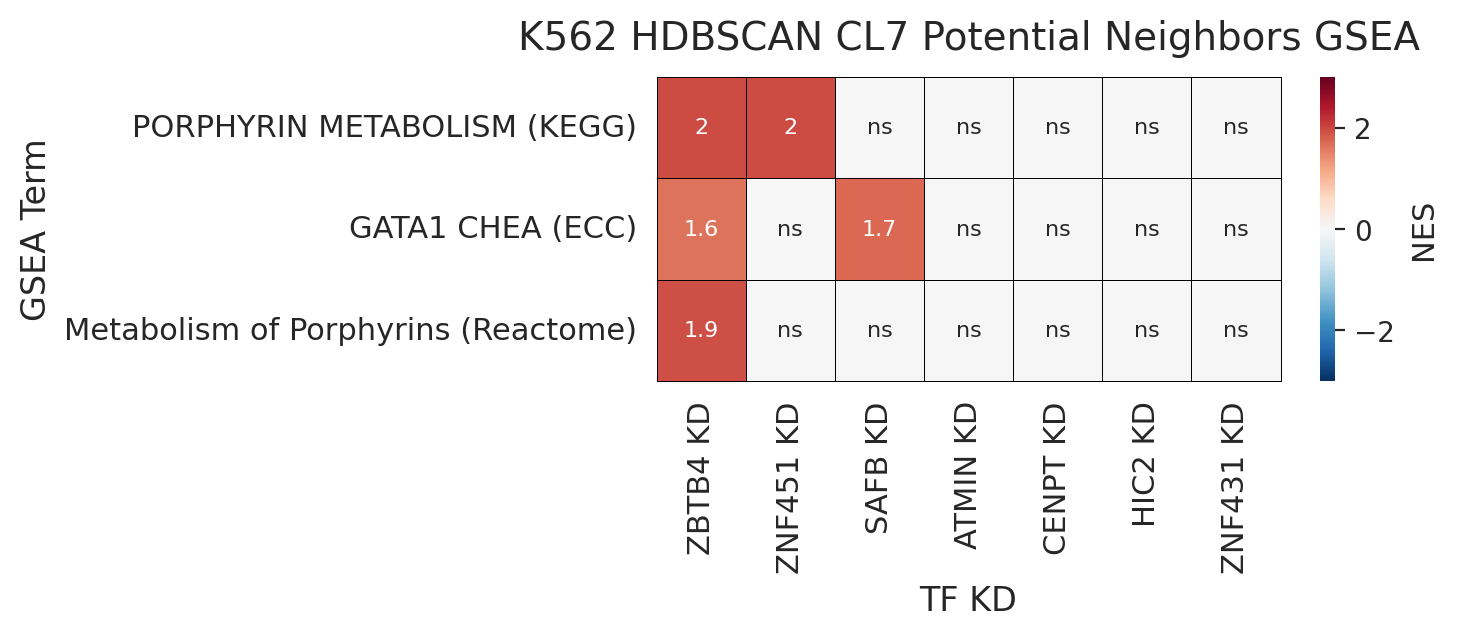

In [17]:
cl7_erythroid_terms = ['GATA1 CHEA', 'PORPHYRIN METABOLISM', 
    'Heme Metabolic Process (GO:0042168)',
    'Metabolism of Porphyrins']
_ = plot_gsea_heatmap(k562_gsea_results, kds=cl7_potential_nbrs,
                    title="K562 HDBSCAN CL7 Potential Neighbors GSEA",
                    terms=cl7_erythroid_terms,
                    kd_col="TF KD", xlabel="TF KD",
                    cbar_size=1, figsize=(5,2),
                    cbar_label="NES", vmin=-3, vmax=3)

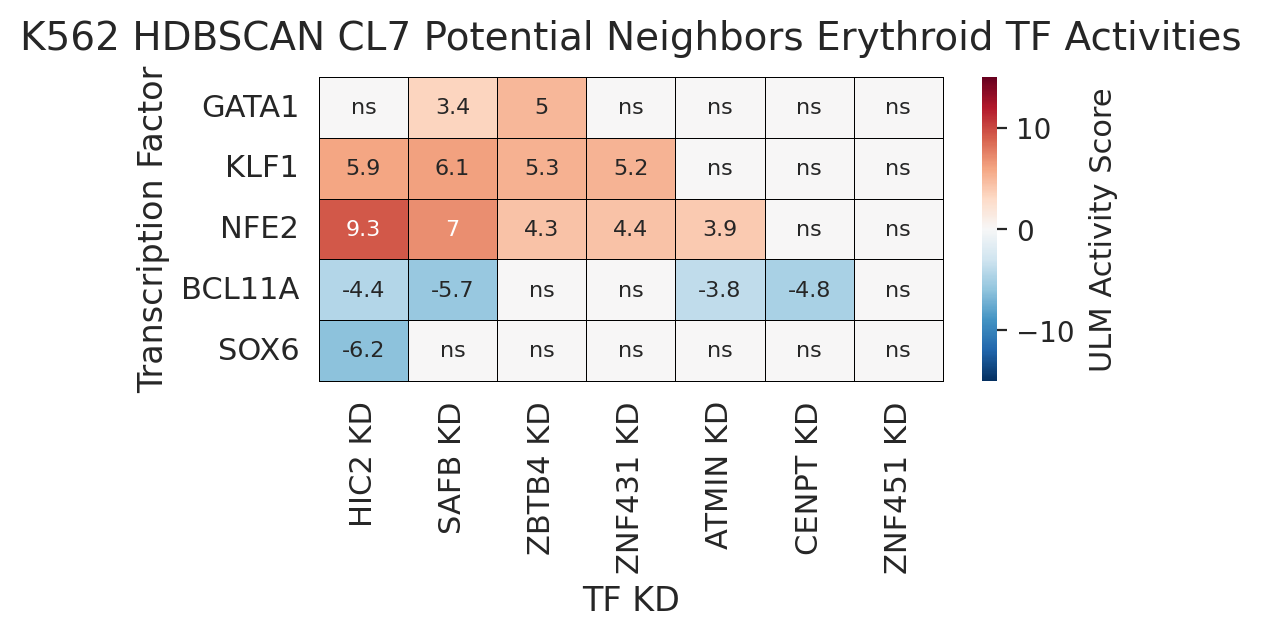

In [18]:
cl7_potential_tfs = ['GATA1', 'KLF1', 'NFE2', 'TAL1', 'GFI1B', 'ZFPM1', 'LMO2', 'BCL11A', 'SOX6']
cl7_potential_nbrs_kds = [f"{kd} KD" for kd in cl7_potential_nbrs]
tf_acts_cl7_potential_nbrs = \
    k562_tf_acts_kds[k562_tf_acts_kds.index.isin(cl7_potential_nbrs_kds)]
plot_tf_pw_activity_heatmap(tf_acts_cl7_potential_nbrs[cl7_potential_tfs],
                            title="K562 HDBSCAN CL7 Potential Neighbors Erythroid TF Activities",
                            xlabel="TF KD", ylabel="Transcription Factor", figsize=(5,2),
                            xvals="kds", top=25, sort_rows=False, sort_columns=True, 
                            cbar_size=1, vmin=-15, vmax=15)

Include HIC2, SAFB, ZBTB4

In [26]:
cl7_plus_nbrs = set(hdbscan_clusters_k562["7"][hdbscan_clusters_k562["7"].notna()]) | {'HIC2', 'SAFB', 'ZBTB4'}
cl7_nbrs_rename = {'HIC2 KD': 'HIC2 KD (nbr)', 'SAFB KD': 'SAFB KD (nbr)', 'ZBTB4 KD': 'ZBTB4 KD (nbr)'}

Full heatmap of all erythroid-related TFs

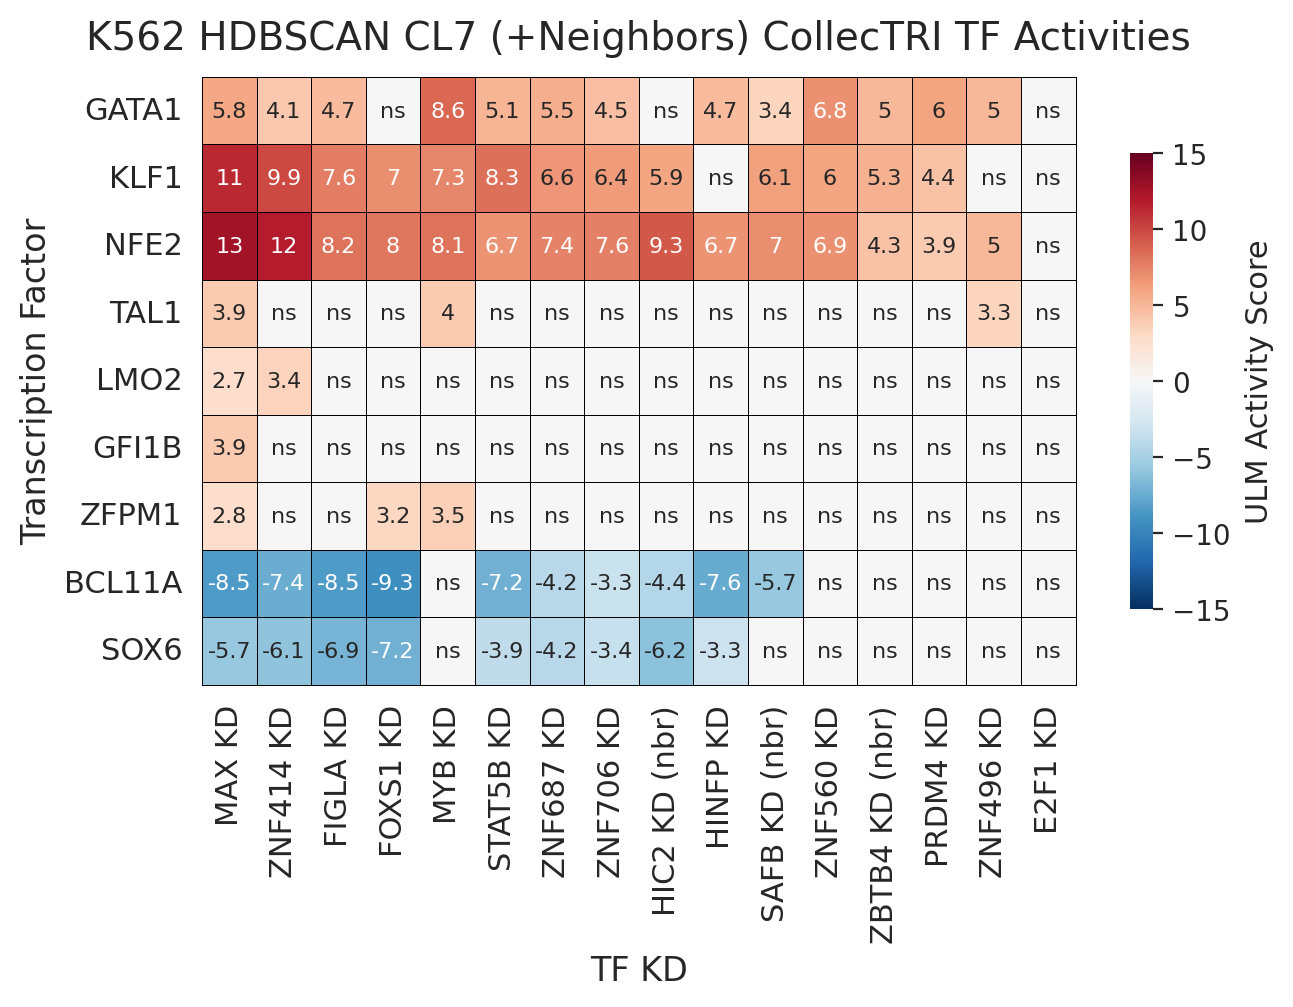

In [27]:
cl7_heatmap_tfs_all = ['GATA1', 'KLF1', 'NFE2', 'TAL1', 'LMO2', 'GFI1B', 'ZFPM1', 'BCL11A', 'SOX6']
plot_tf_pw_activity_heatmap(k562_tf_acts_kds[cl7_heatmap_tfs_all], kds=cl7_plus_nbrs,
                            rename_columns=cl7_nbrs_rename,
                            title="K562 HDBSCAN CL7 (+Neighbors) CollecTRI TF Activities",
                            xlabel="TF KD", ylabel="Transcription Factor", figsize=(7,4),
                            xvals="kds", top=25, sort_rows=False, sort_columns=True, 
                            cbar_size=0.75, vmin=-15, vmax=15)

Check a lot of erythroid genes

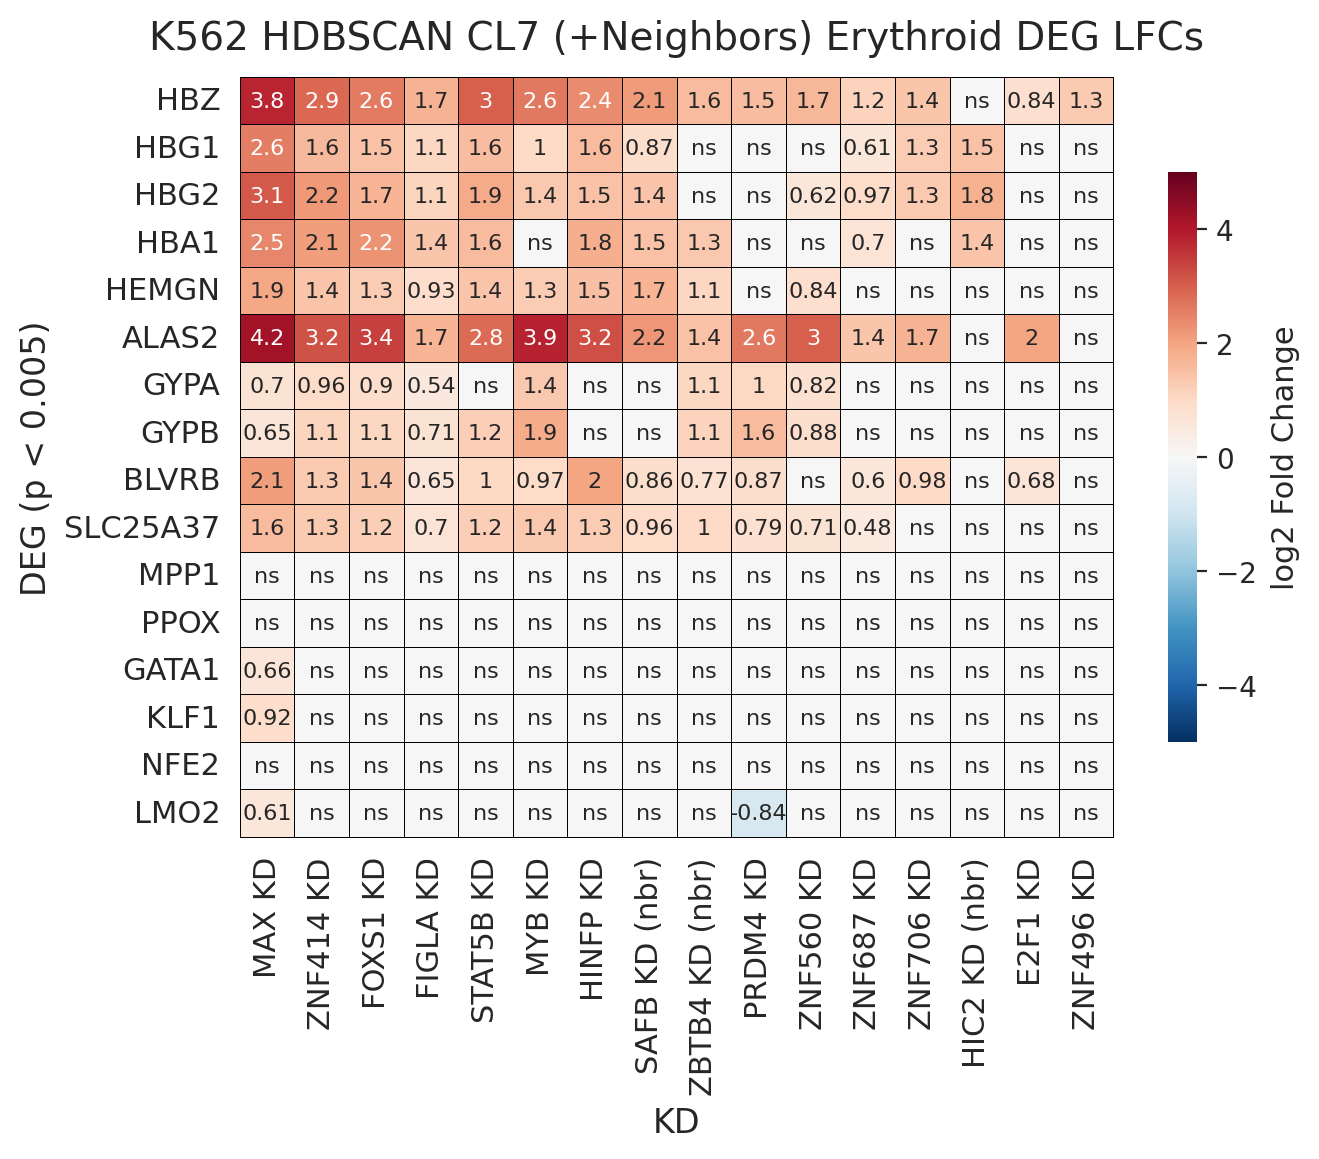

In [28]:
all_erythroid_genes = ['HBZ', 'HBG1', 'HBG2', 'HBA1', 'HEMGN', 'ALAS2', 'GYPA', 'GYPB', 'BLVRB', 
                          'SLC25A37', 'MPP1', 'PPOX', 'GATA1', 'KLF1', 'NFE2', 'LMO2']
_ = plot_DEG_LFC_heatmap(k562_deg_lfcs, 
                         title="K562 HDBSCAN CL7 (+Neighbors) Erythroid DEG LFCs",
                         ylabel="DEG (p < 0.005)", drop_nan_rows=False,
                         kds=cl7_plus_nbrs, rename_columns=cl7_nbrs_rename,
                         degs=all_erythroid_genes, sort_columns=True, sort_rows=False,
                         figsize=(7,5), cbar_size=0.75)

Pathways

In [ ]:
plot_tf_pw_activity_heatmap(k562_pw_acts_kds, kds=cl7_plus_nbrs,
                            rename_columns=cl7_nbrs_rename,
                            title="K562 HDBSCAN CL7 (+Neighbors) PROGENy Pathway Activities",
                            xlabel="TF KD", ylabel="Pathway", figsize=(7,4),
                            xvals="kds", top=25, sort_rows=False, sort_columns=True, 
                            cbar_size=0.75)

## Analysis

Erythroid maturation signature

In [62]:
cl7_plus_nbrs = set(hdbscan_clusters_k562["7"][hdbscan_clusters_k562["7"].notna()]) | {'HIC2', 'SAFB', 'ZBTB4'}
cl7_nbrs_rename = {'HIC2 KD': 'HIC2 KD (nbr)', 'SAFB KD': 'SAFB KD (nbr)', 'ZBTB4 KD': 'ZBTB4 KD (nbr)'}

In [28]:
n_degs_df_k562[n_degs_df_k562.index.isin(cl7_plus_nbrs)]

,n_DEGs
MAX,149
MYB,140
HINFP,57
FOXS1,51
PRDM4,50
ZBTB4,47
ZNF687,40
STAT5B,40
FIGLA,39
ZNF560,39


In [63]:
cl7_plus_nbrs_order = ['MAX', 'ZNF414', 'FOXS1', 'HINFP', 'STAT5B', 'FIGLA', 'ZBTB4', 'MYB', 
                       'PRDM4', 'ZNF687', 'ZNF560', 'SAFB', 'ZNF706', 'HIC2', 'E2F1', 'ZNF496']
print(', '.join(cl7_plus_nbrs_order))
print(len(cl7_plus_nbrs_order))

MAX, ZNF414, FOXS1, HINFP, STAT5B, FIGLA, ZBTB4, MYB, PRDM4, ZNF687, ZNF560, SAFB, ZNF706, HIC2, E2F1, ZNF496
16


In [64]:
erythroid_terms = ['GATA1 CHEA', 'PORPHYRIN METABOLISM', 
    'Heme Metabolic Process (GO:0042168)',
    'Metabolism of Porphyrins']

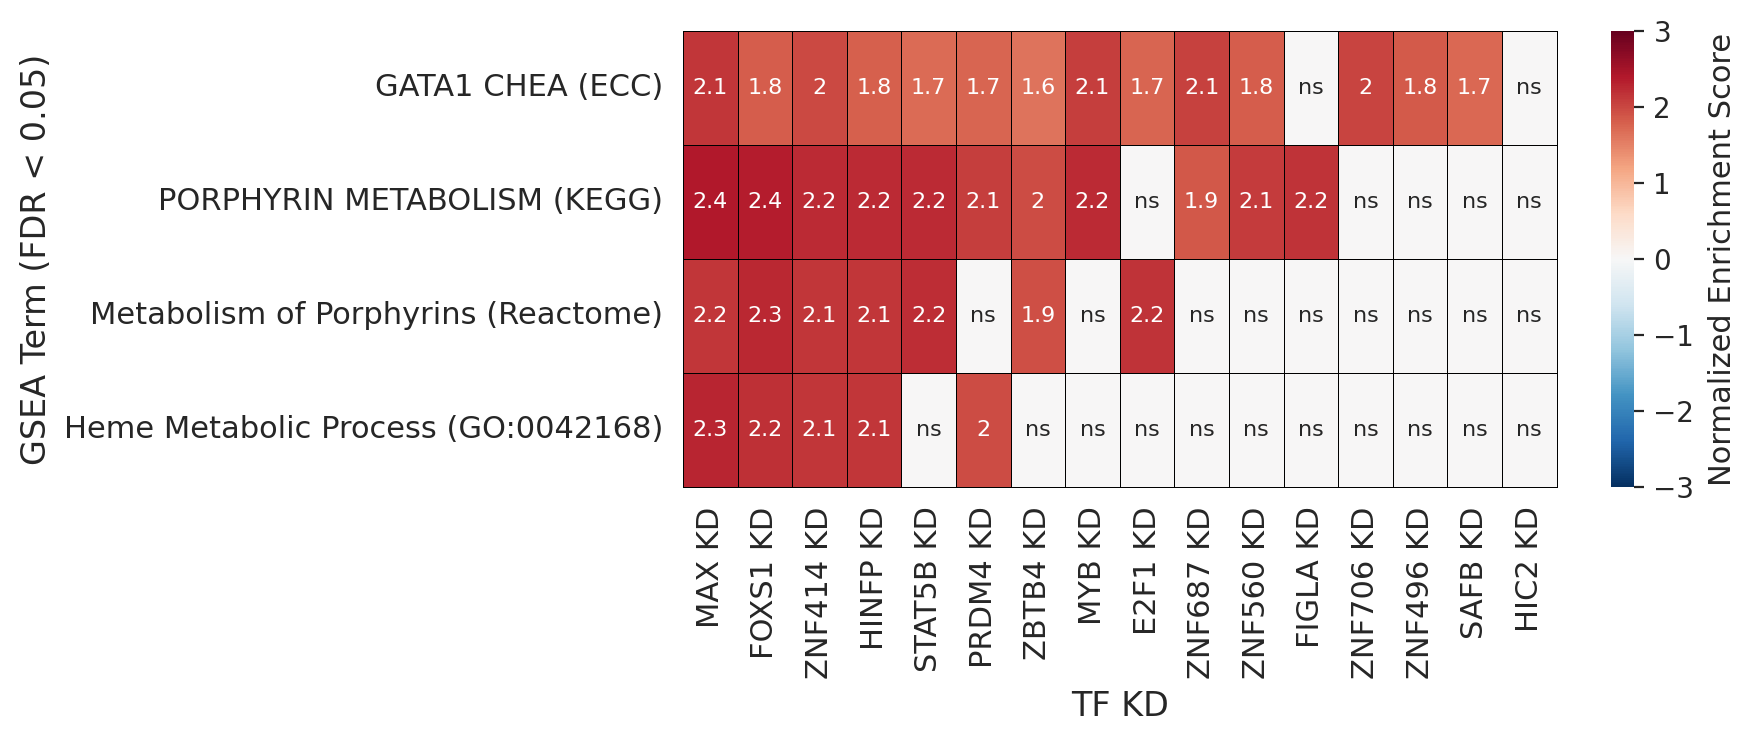

In [65]:
_ = plot_gsea_heatmap(k562_gsea_results, kds=cl7_plus_nbrs_order,
                    terms=erythroid_terms,
                    kd_col="TF KD", xlabel="TF KD",
                    sort_columns=True,
                    cbar_size=1, figsize=(7,3),
                    ylabel="GSEA Term (FDR < 0.05)",
                    cbar_label="Normalized Enrichment Score",
                    save_path="/home/ranwyl/figures_tf_project/k562_cl7_gsea_erythroid.png",
                    save_format="png", dpi=300)

In [ ]:
cl7_heatmap_tfs = ['GATA1', 'KLF1', 'NFE2', 'BCL11A', 'SOX6']
plot_tf_pw_activity_heatmap(k562_tf_acts_kds[cl7_heatmap_tfs], kds=cl7_plus_nbrs_order,
                            rename_columns=cl7_nbrs_rename,
                            xlabel="TF KD", ylabel="TF (FDR < 0.05)", figsize=(7,3),
                            xvals="kds", sort_rows=False, sort_columns=False, 
                            cbar_size=1, vmin=-15, vmax=15,
                            save_path="/home/ranwyl/figures_tf_project/k562_cl7_tf_acts.png",
                            save_format="png", dpi=300)

In [45]:
erythroid_tfs = ['GATA1', 'KLF1', 'NFE2', 'BCL11A', 'SOX6']
erythroid_tf_categories = {'Erythroid Activators': ['GATA1', 'KLF1', 'NFE2'],
                     'Fetal Globin Silencers': ['BCL11A', 'SOX6']}
erythroid_tf_colors = {'Erythroid Activators': '#CC78BC', 'Fetal Globin Silencers': '#0173B2'}

Starting..
Calculating row orders..
Reordering rows..
Calculating col orders..
Reordering cols..
Plotting matrix..
Plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 7.5 mm


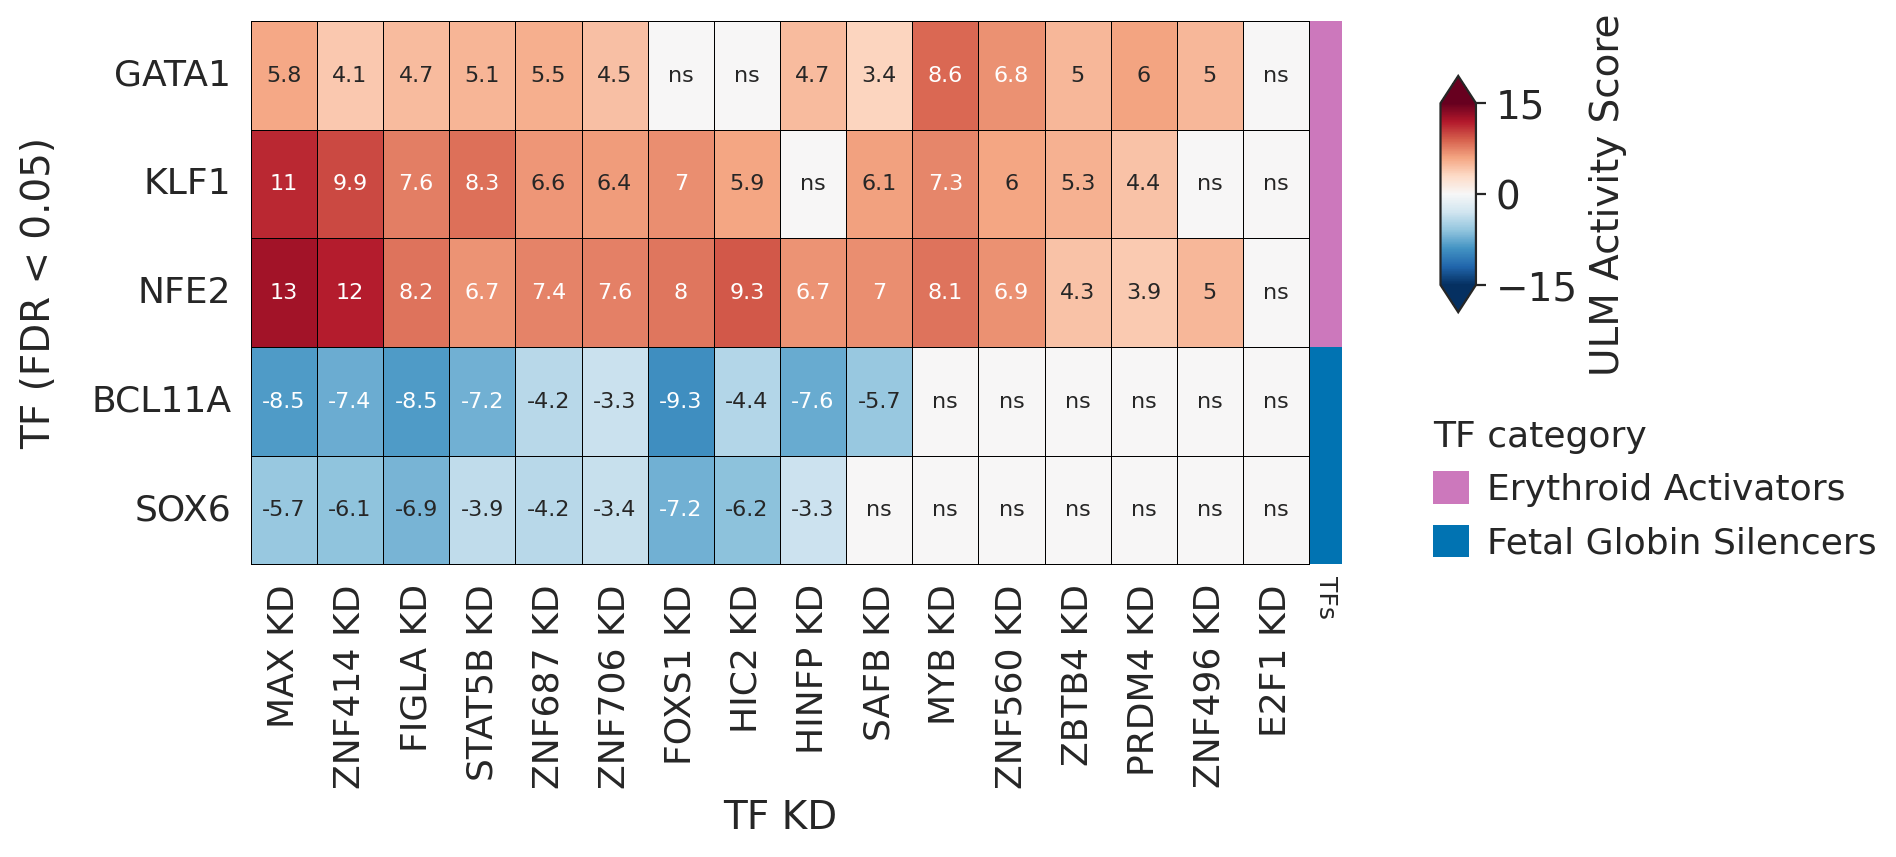

In [87]:
plot_tf_pw_activity_heatmap(k562_tf_acts_kds, kds=cl7_plus_nbrs_order,
                            terms=erythroid_tfs,
                            xlabel="TF KD", ylabel="TF (FDR < 0.05)", figsize=(7,3),
                            xvals="kds", sort_rows=False, sort_columns=True, 
                            vmin=-15, vmax=15, annot_legend_position=(1.1, 0.3),
                            annotations_for_bars=erythroid_tf_categories, 
                            annotation_colors=erythroid_tf_colors, ylabel_pad=65,
                            xlabel_pad=80,
                            save_path="/home/ranwyl/figures_tf_project/k562_cl7_tf_acts.png",
                            save_format="png", dpi=300)

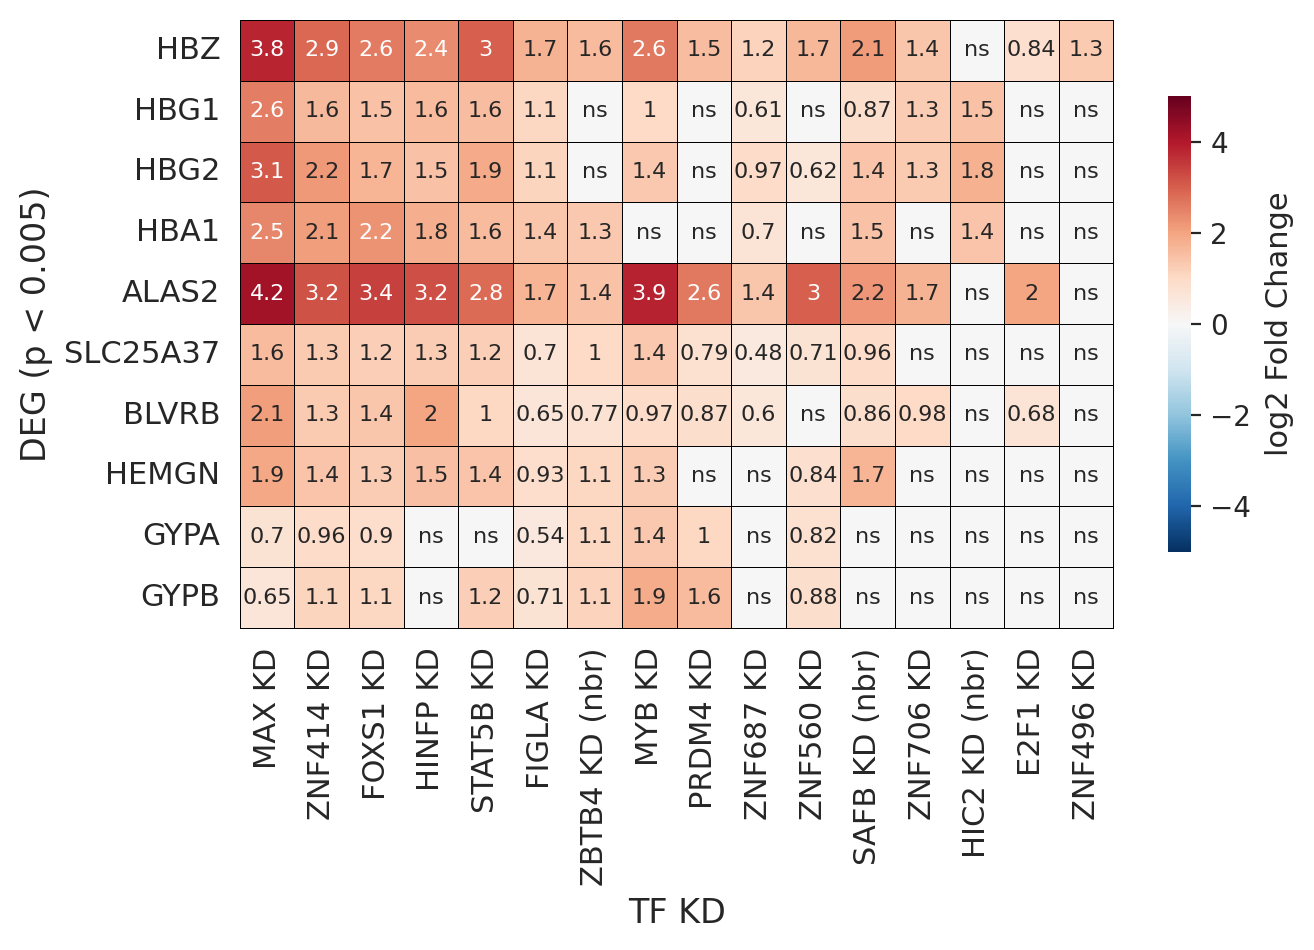

In [75]:
cl7_erythroid_degs = ['HBZ', 'HBG1', 'HBG2', 'HBA1', 
                      'ALAS2', 'SLC25A37', 'BLVRB', 
                      'HEMGN', 'GYPA', 'GYPB']
k562_deg_lfcs_for_heatmap = k562_deg_lfcs[
    k562_deg_lfcs.index.isin(cl7_erythroid_degs)].reindex(cl7_erythroid_degs)
_ = plot_DEG_LFC_heatmap(k562_deg_lfcs_for_heatmap, kds=cl7_plus_nbrs_order,
                         ylabel="DEG (p < 0.005)", drop_nan_rows=False,
                        rename_columns=cl7_nbrs_rename, xlabel="TF KD", xlabel_pad=70,
                         degs=cl7_erythroid_degs, sort_columns=False, sort_rows=False,
                         figsize=(7,4), cbar_size=0.75)

In [46]:
erythroid_degs = ['HBZ', 'HBG1', 'HBG2', 'HBA1', 
                      'SLC25A37', 'ALAS2', 'BLVRB', 
                      'HEMGN', 'GYPA', 'GYPB']
erythroid_deg_categories = {'Globins': ['HBZ', 'HBG1', 'HBG2', 'HBA1'],
                  'Heme Metabolism': ['ALAS2', 'SLC25A37', 'BLVRB'],
                  'Erythroid Markers': ['ALAS2', 'BLVRB', 'HEMGN', 'GYPA', 'GYPB']}
erythroid_deg_colors = {'Globins': '#56B4E9', 'Heme Metabolism': '#029E73', 
              'Erythroid Markers': '#CC78BC'}

Starting..
Calculating row orders..
Reordering rows..
Calculating col orders..
Reordering cols..
Plotting matrix..
Plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 7.5 mm


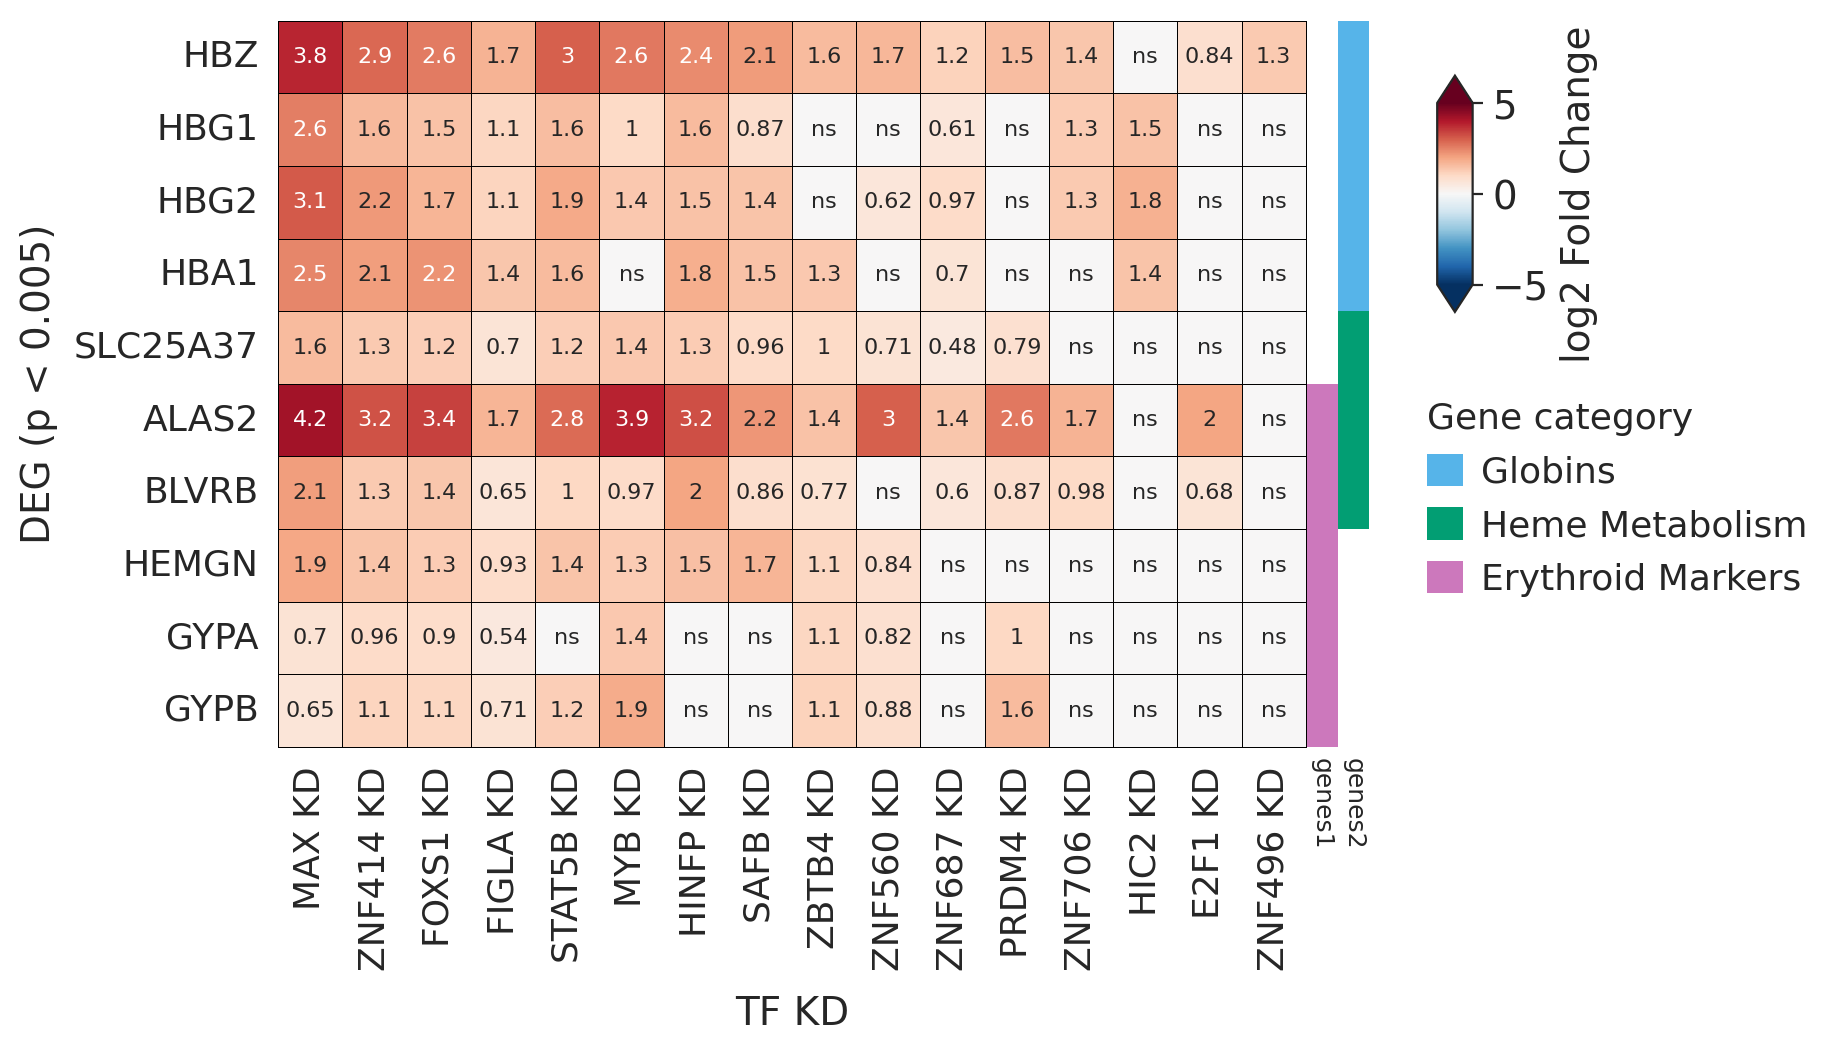

In [77]:
_ = plot_DEG_LFC_heatmap(k562_deg_lfcs, kds=cl7_plus_nbrs_order,
                         ylabel="DEG (p < 0.005)", drop_nan_rows=False,
                         xlabel="TF KD",
                         annotations_for_bars=erythroid_deg_categories, 
                         annotation_colors=erythroid_deg_colors,
                         annotation_bar_1_label='Erythroid Markers',
                         n_annotation_bars=2, 
                         annot_legend_position=(1.1, 0.5),
                         degs=erythroid_degs, sort_columns=True, sort_rows=False,
                         figsize=(7,4), ylabel_pad=75, xlabel_pad=85,
                         save_path="/home/ranwyl/figures_tf_project/k562_cl7_erythroid_degs.png",
                         save_format="png", dpi=300)

No cluster-wide "myeloid down" program observed in DEGs

In [70]:
myeloid_degs = ['AIF1', 'PYCARD', 'SPI1', 'CTSS', 'CYBA', 'DOCK2']
myeloid_deg_categories = {'Myeloid & Immune Cell': ['AIF1', 'PYCARD', 'SPI1', 'CTSS', 'CYBA', 'DOCK2']}
myeloid_deg_colors = {'Myeloid & Immune Cell': '#949494'}

Starting..
Calculating row orders..
Reordering rows..
Calculating col orders..
Reordering cols..
Plotting matrix..
Plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 7.5 mm


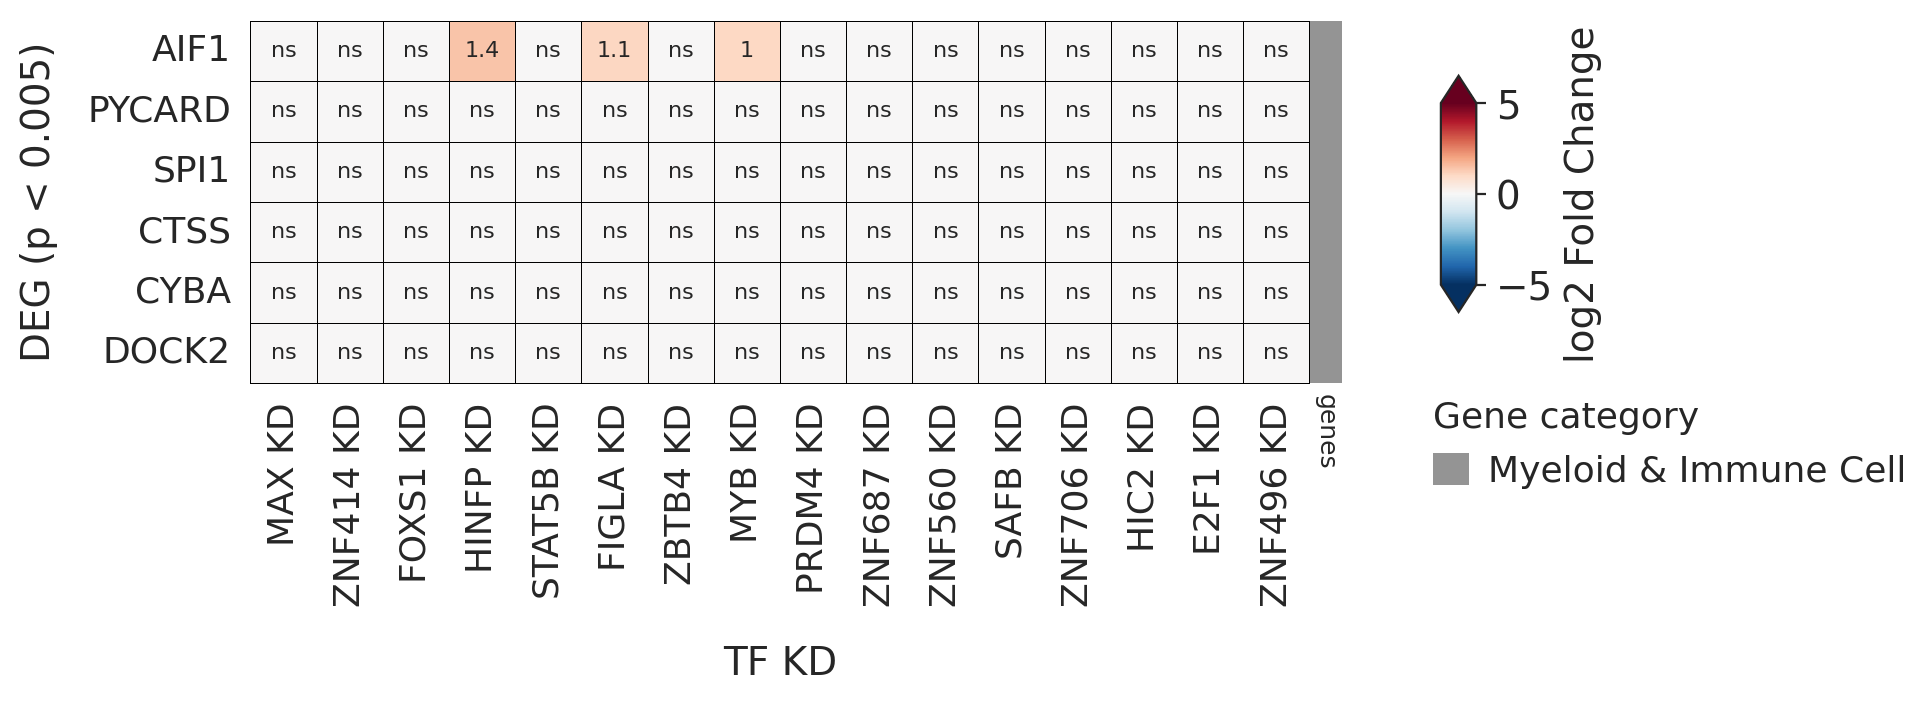

In [71]:
_ = plot_DEG_LFC_heatmap(k562_deg_lfcs,
                         ylabel="DEG (p < 0.005)", drop_nan_rows=False, xlabel="TF KD",
                         kds=cl7_plus_nbrs_order, 
                         degs=myeloid_degs, sort_columns=False, sort_rows=False,
                         annot_legend_position=(1.1, 0), ylabel_pad=65,
                         annotations_for_bars=myeloid_deg_categories, 
                         annotation_colors=myeloid_deg_colors,
                         figsize=(7,2), cbar_size=1, vmin=-5, vmax=5,
                         save_path="/home/ranwyl/figures_tf_project/k562_cl7_myeloid_degs.png",
                         save_format="png", dpi=300)

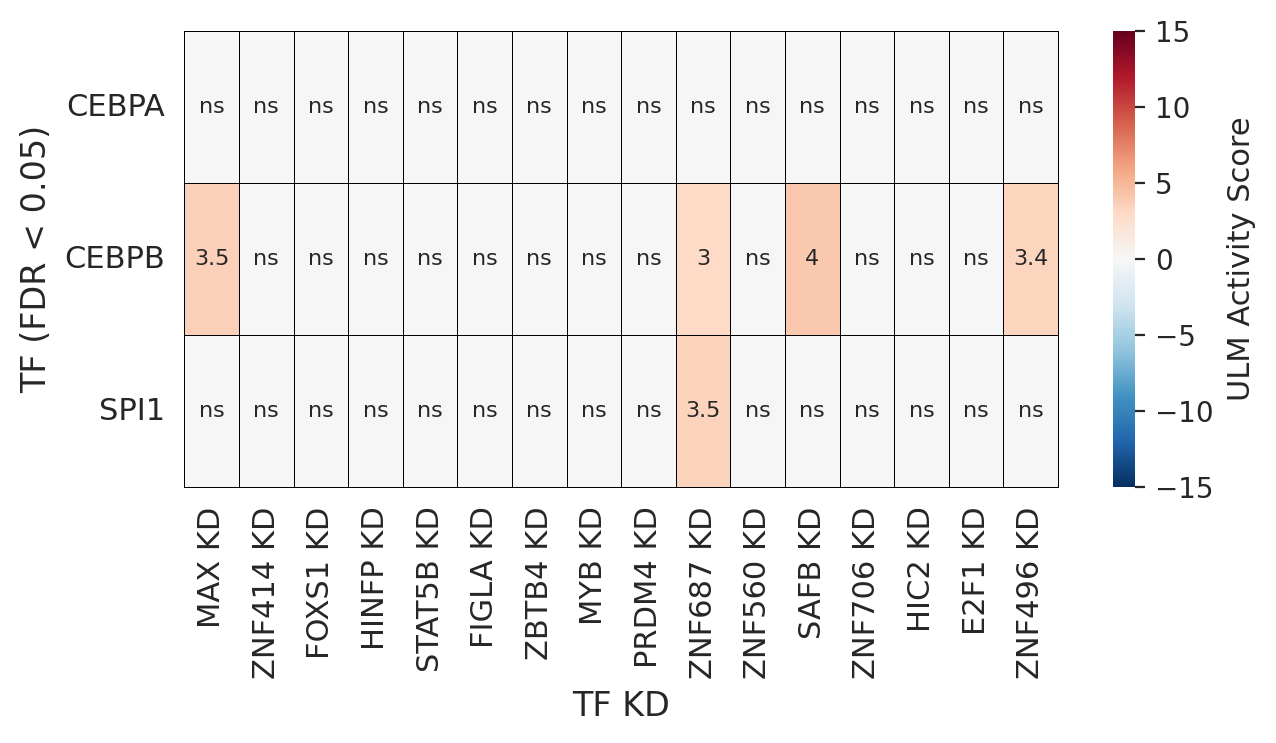

In [ ]:
plot_tf_pw_activity_heatmap(k562_tf_acts_kds, kds=cl7_plus_nbrs_order,
                            terms=['CEBPA', 'CEBPB', 'SPI1'],
                            xlabel="TF KD", ylabel="TF (FDR < 0.05)", figsize=(7,3),
                            xvals="kds", sort_rows=False, sort_columns=False, 
                            cbar_size=1, vmin=-15, vmax=15,
                            #save_path="/home/ranwyl/figures_tf_project/k562_cl7_tf_acts.png",
                            save_format="png", dpi=300)

Check which TF KDs have ChIP-seq data

In [ ]:
find_encode_chea_tf_experiments(cl7_plus_nbrs, "K562")

ENCODE 2015: ['MAX K562 hg19']


## Compare to generic terms/rest of dataset

In [ ]:
with pd.option_context('display.max_colwidth', 100):
    display(k562_kd_shared_gsea_terms[
        k562_kd_shared_gsea_terms["Term"].str.contains("heme", case=False)].sort_values(by="Term"))

,Gene set,Term,Direction,# TF KDs,% TF KDs,Mean NES
740,GO:BP,Heme Biosynthetic Process (GO:0006783),UP,5,1,2.062
517,GO:BP,Heme Metabolic Process (GO:0042168),UP,9,2,2.137
9,Hallmark,heme Metabolism,UP,232,54,1.889
1771,Hallmark,heme Metabolism,DOWN,1,0,-1.533


In [ ]:
with pd.option_context('display.max_colwidth', 100):
    display(k562_kd_shared_gsea_terms[
        k562_kd_shared_gsea_terms["Term"].str.contains("porphyrin", case=False)].sort_values(by="Term"))

,Gene set,Term,Direction,# TF KDs,% TF KDs,Mean NES
273,Reactome,Metabolism of Porphyrins,UP,21,4,2.066
161,KEGG,PORPHYRIN METABOLISM,UP,32,7,2.035
1013,GO:BP,Porphyrin-Containing Compound Biosynthetic Process (GO:0006779),UP,3,0,2.007


In [ ]:
with pd.option_context('display.max_colwidth', 100):
    display(k562_kd_shared_gsea_terms[
        k562_kd_shared_gsea_terms["Term"].str.contains("hydrogen peroxide", case=False)].sort_values(by="Term"))

,Gene set,Term,Direction,# TF KDs,% TF KDs,Mean NES
141,GO:BP,Hydrogen Peroxide Metabolic Process (GO:0042743),UP,36,8,2.214
387,GO:BP,Hydrogen Peroxide Metabolic Process (GO:0042743),DOWN,13,3,-2.176


In [ ]:
build_mean_nes_inside_outside_kd_set_df(
    k562_gsea_enriched, cl7_plus_nbrs,
    [('heme Metabolism', 'MSigDB_Hallmark_2020'),
    ('GATA1 CHEA', 'ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X')],
    kd_col="TF KD", kd_set_label="CL7(+nbrs)", n_dataset_kds=429)

,Term,NES inside CL7(+nbrs),NES outside CL7(+nbrs),# enriched TF KDs inside,# enriched TF KDs outside
0,heme Metabolism (Hallmark),2.59,1.82,16/16,215/413
1,GATA1 CHEA (ECC),1.86,1.62,14/16,61/413


In [ ]:
build_mean_nes_inside_outside_kd_set_df(
    k562_gsea_enriched, cl7_plus_nbrs,
    [('PORPHYRIN METABOLISM', 'KEGG_2026'),
    ('Heme Metabolic Process (GO:0042168)', 'GO_Biological_Process_2025')],
    kd_col="TF KD", kd_set_label="CL7(+nbrs)", n_dataset_kds=429)

,Term,NES inside CL7(+nbrs),NES outside CL7(+nbrs),# enriched TF KDs inside,# enriched TF KDs outside
0,PORPHYRIN METABOLISM (KEGG),2.17,1.96,11/16,21/413
1,Heme Metabolic Process (GO:0042168),2.14,2.13,5/16,4/413


In [ ]:
shared_tf_acts_k562[shared_tf_acts_k562["TF"].isin(cl7_heatmap_tfs)]

,TF,Direction,# TF KDs,% TF KDs,Mean Activity
13,NFE2,UP,99,23,4.823
21,KLF1,UP,70,16,4.552
25,GATA1,UP,65,15,4.250
30,BCL11A,DOWN,62,14,-4.745
54,SOX6,DOWN,26,6,-4.423
75,BCL11A,UP,17,3,4.866
85,SOX6,UP,13,3,4.322
117,KLF1,DOWN,9,2,-4.001
264,NFE2,DOWN,2,0,-5.357


In [ ]:
build_mean_activity_inside_outside_kd_set_df(
    k562_tf_acts_kds, kds=cl7_plus_nbrs, term_type="TF",
    terms=['GATA1', 'KLF1', 'NFE2', 'BCL11A', 'SOX6'],
    kd_set_label="CL7(+nbrs)"
)

,TF,Activity inside CL7(+nbrs),Activity outside CL7(+nbrs),# enriched KDs inside,# enriched KDs outside
0,GATA1,5.33,3.98,13/16,52/413
1,KLF1,7.09,2.89,13/16,66/413
2,NFE2,7.57,4.11,15/16,86/413
3,BCL11A,-6.62,-2.11,10/16,69/413
4,SOX6,-5.20,-0.40,9/16,30/413


# HDBSCAN Cluster 0

Myeloid lineage suppression without clear erythroid lineage priming

In [21]:
cl0_tf_kds = ['TFDP1', 'ZBTB39', 'PRMT3', 'SPI1']

In [83]:
n_degs_df_k562[n_degs_df_k562.index.isin(cl0_tf_kds)]

,n_DEGs
TFDP1,127
ZBTB39,23
PRMT3,19
SPI1,17


Starting..
Calculating row orders..
Reordering rows..
Calculating col orders..
Reordering cols..
Plotting matrix..
Plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 7.5 mm


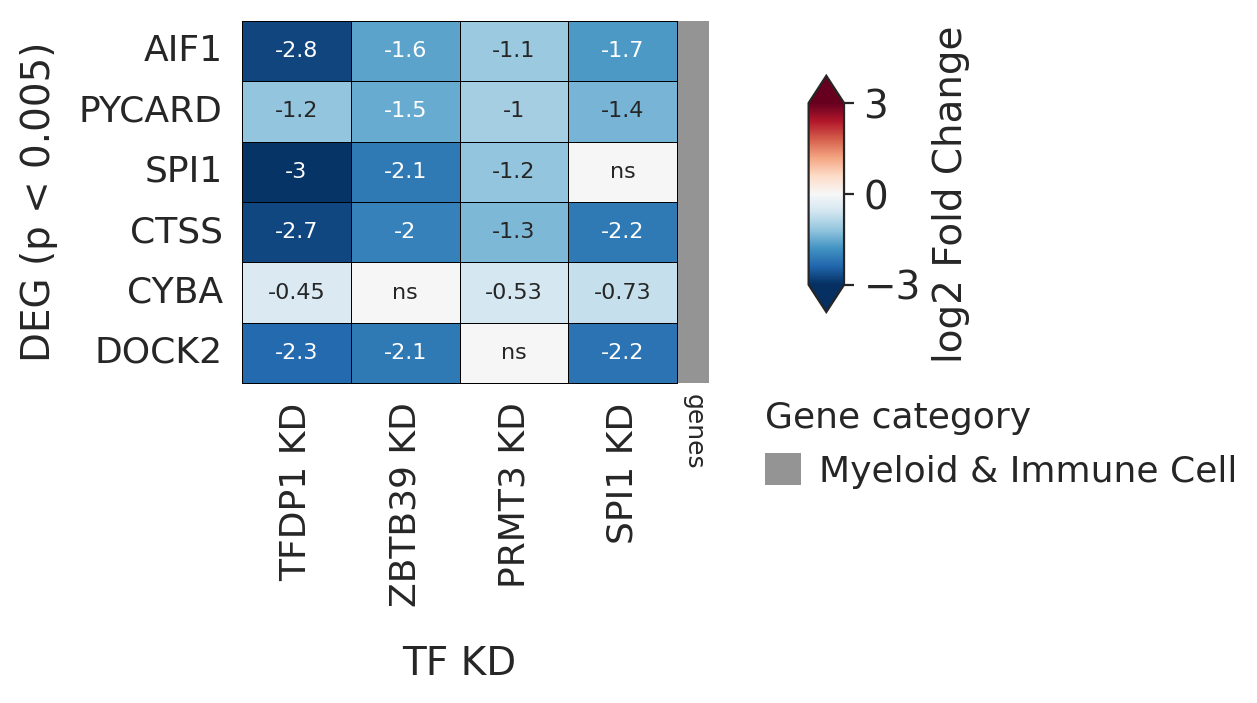

In [119]:
plot_DEG_LFC_heatmap(k562_deg_lfcs,
                         ylabel="DEG (p < 0.005)", drop_nan_rows=False, xlabel="TF KD",
                         kds=cl0_tf_kds,
                         degs=myeloid_degs, sort_columns=False, sort_rows=False,
                         annot_legend_position=(1.16, 0), ylabel_pad=62,
                         annotations_for_bars=myeloid_deg_categories, 
                         annotation_colors=myeloid_deg_colors,
                         figsize=(3,2), vmin=-3, vmax=3,
                         save_path="/home/ranwyl/figures_tf_project/k562_cl0_myeloid_degs.png",
                         save_format="png", dpi=300)

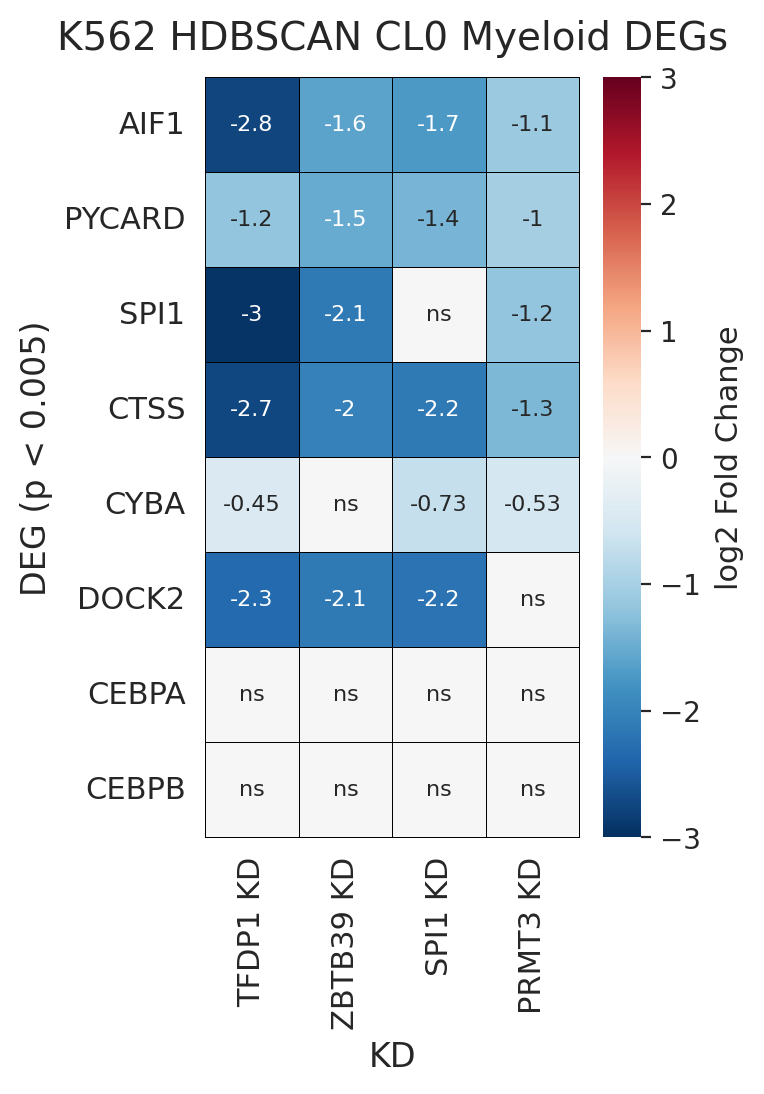

In [85]:
cl0_myeloid_degs = ['AIF1', 'PYCARD', 'SPI1', 'CTSS', 'CYBA', 'DOCK2', 'CEBPA', 'CEBPB']
_ = plot_DEG_LFC_heatmap(k562_deg_lfcs, title="K562 HDBSCAN CL0 Myeloid DEGs", 
                         cluster_df=hdbscan_clusters_k562, cluster=0,
                         ylabel="DEG (p < 0.005)", sort_rows=False,
                         degs=cl0_myeloid_degs, sort_columns=True, figsize=(3,5))

In [64]:
collectri[(collectri['source'] == 'SPI1') & collectri['target'].isin(cl0_myeloid_degs)]

,source,target,weight,resources,references,sign_decision
2496,SPI1,SPI1,1.0,ExTRI;NTNU.Curated;SIGNOR;TFactS,11114304;11835402;11997509;12027437;12032776;1...,PMID
10225,SPI1,CTSS,1.0,DoRothEA-A;ExTRI;TFactS;TRRUST,16365419,PMID
39568,SPI1,CYBA,1.0,GEREDB,11241298,default activation


No cluster-wide erythroid up or down signature from DEGs

Starting..
Calculating row orders..
Reordering rows..
Calculating col orders..
Reordering cols..
Plotting matrix..
Plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 7.5 mm


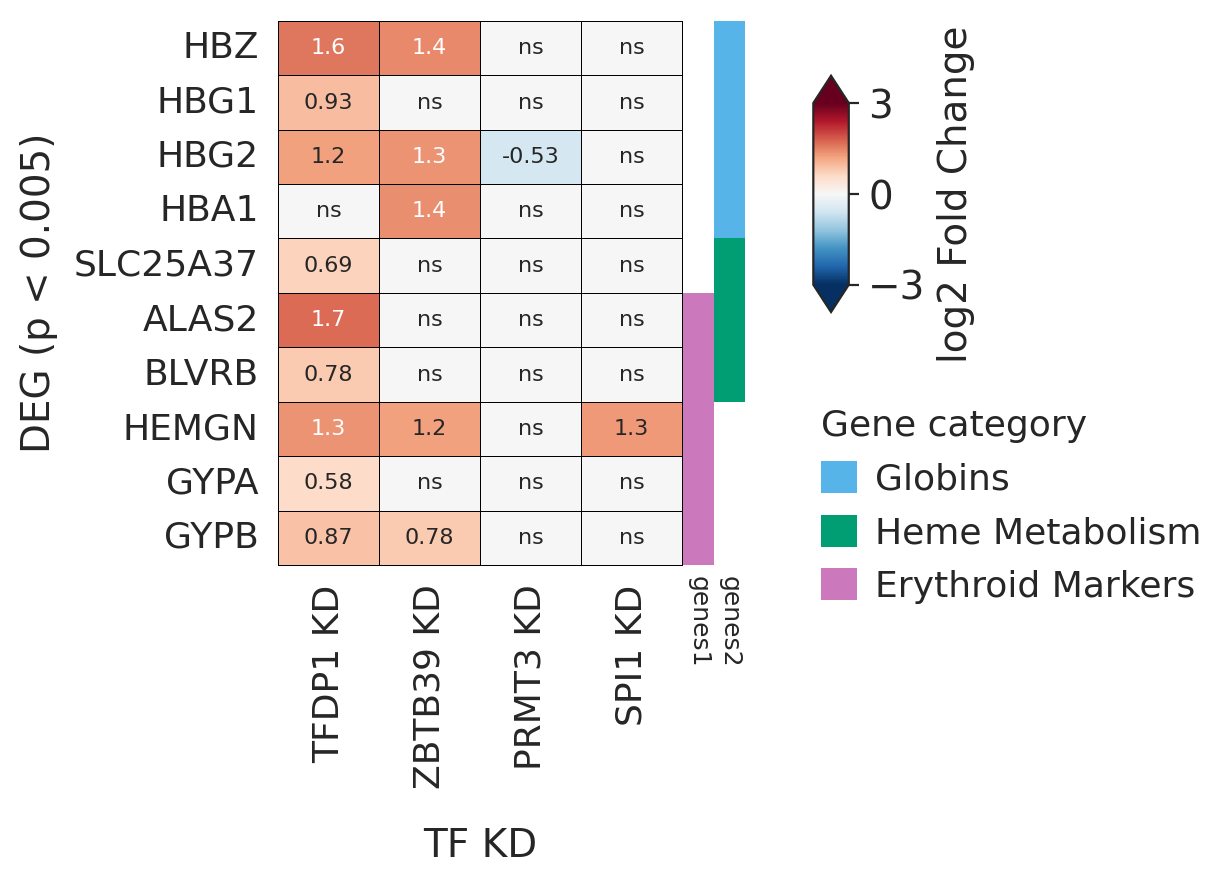

In [69]:
_ = plot_DEG_LFC_heatmap(k562_deg_lfcs, kds=cl0_tf_kds,
                         ylabel="DEG (p < 0.005)", drop_nan_rows=False,
                         xlabel="TF KD",
                         annotations_for_bars=erythroid_deg_categories, 
                         annotation_colors=erythroid_deg_colors,
                         annotation_bar_1_label='Erythroid Markers',
                         n_annotation_bars=2, vmin=-3, vmax=3,
                         annot_legend_position=(1.3, 0.32),
                         degs=erythroid_degs, sort_columns=False, sort_rows=False,
                         figsize=(3,3), ylabel_pad=75,
                         save_path="/home/ranwyl/figures_tf_project/k562_cl0_erythroid_degs.png",
                         save_format="png", dpi=300)

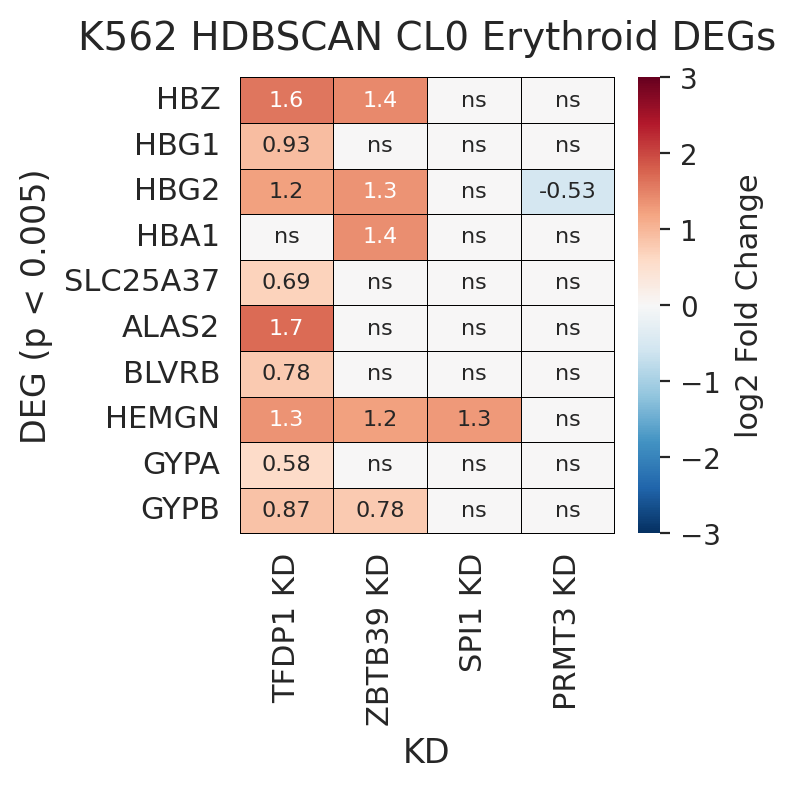

In [33]:
_ = plot_DEG_LFC_heatmap(k562_deg_lfcs, title="K562 HDBSCAN CL0 Erythroid DEGs", 
                         cluster_df=hdbscan_clusters_k562, cluster=0,
                         ylabel="DEG (p < 0.005)", drop_nan_rows=False, sort_rows=False,
                         degs=erythroid_degs, sort_columns=True, figsize=(3,3),
                         vmin=-3, vmax=3)

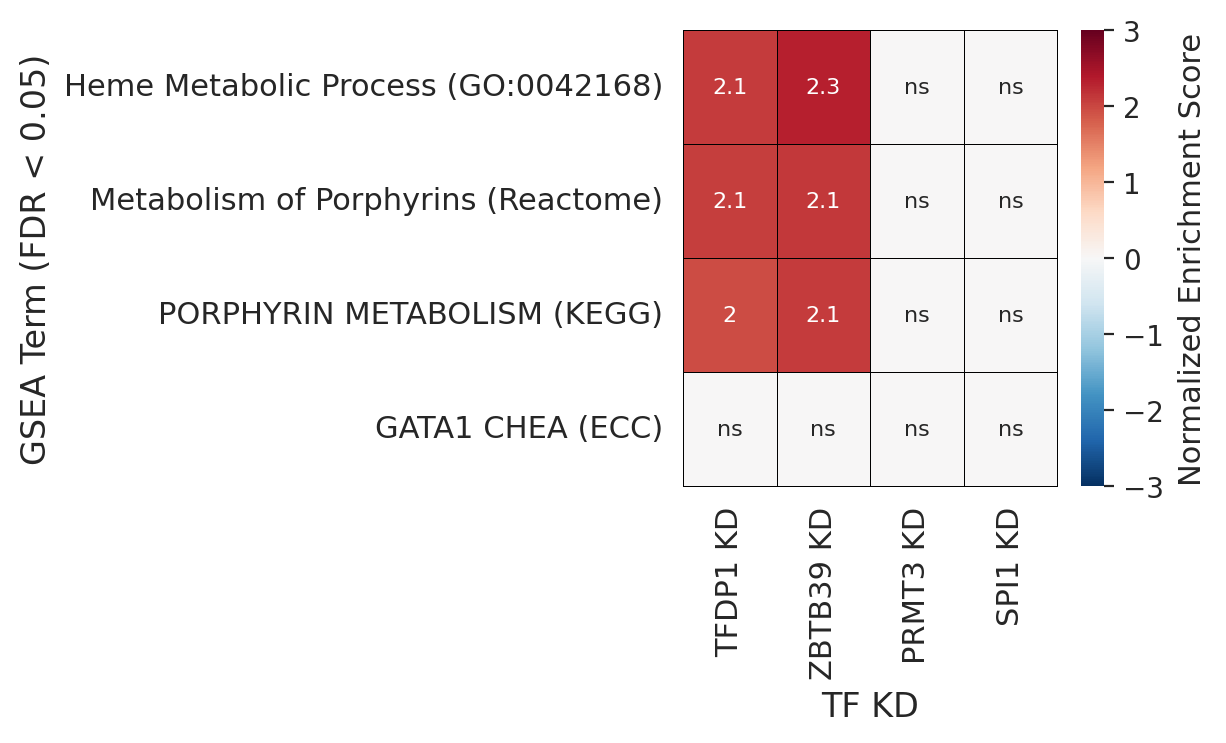

In [70]:
_ = plot_gsea_heatmap(k562_gsea_results, kds=cl0_tf_kds, sort_columns=False,
                    terms=erythroid_terms, drop_nan_rows=False,
                    ylabel="GSEA Term (FDR < 0.05)",
                    kd_col="TF KD", xlabel="TF KD",
                    cbar_size=1, figsize=(3,3),
                    cbar_label="Normalized Enrichment Score", vmin=-3, vmax=3,
                    save_path="/home/ranwyl/figures_tf_project/k562_cl0_erythroid_gsea.png",
                    save_format="png", dpi=300)

Starting..
Calculating row orders..
Reordering rows..
Calculating col orders..
Reordering cols..
Plotting matrix..
Plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 7.5 mm


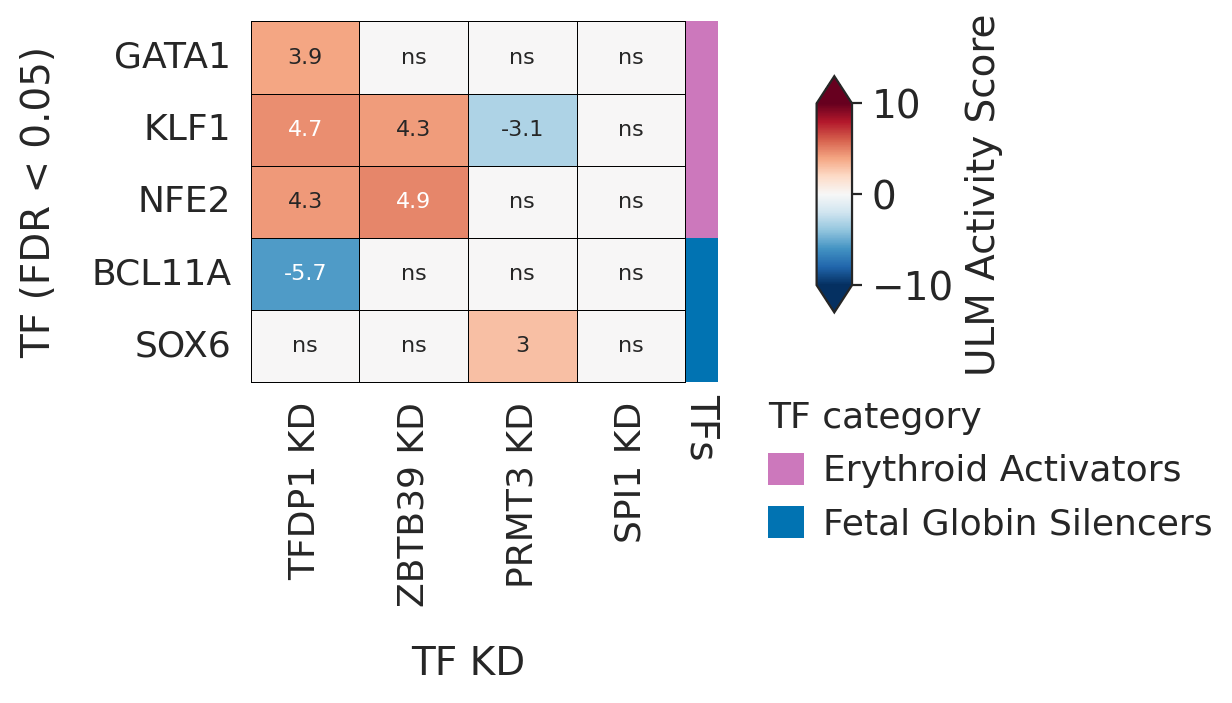

In [76]:
plot_tf_pw_activity_heatmap(k562_tf_acts_kds, kds=cl0_tf_kds,
                            terms=erythroid_tfs,
                            xlabel="TF KD", ylabel="TF (FDR < 0.05)", figsize=(3,2),
                            xvals="kds", sort_rows=False, sort_columns=False, 
                            drop_nan_rows=False,
                            vmin=-10, vmax=10, annot_legend_position=(1.15, 0),
                            annotations_for_bars=erythroid_tf_categories, 
                            annotation_colors=erythroid_tf_colors, ylabel_pad=65,
                            save_path="/home/ranwyl/figures_tf_project/k562_cl0_erythroid_tf_acts.png",
                            save_format="png", dpi=300)

No cluster-wide TF activity signature

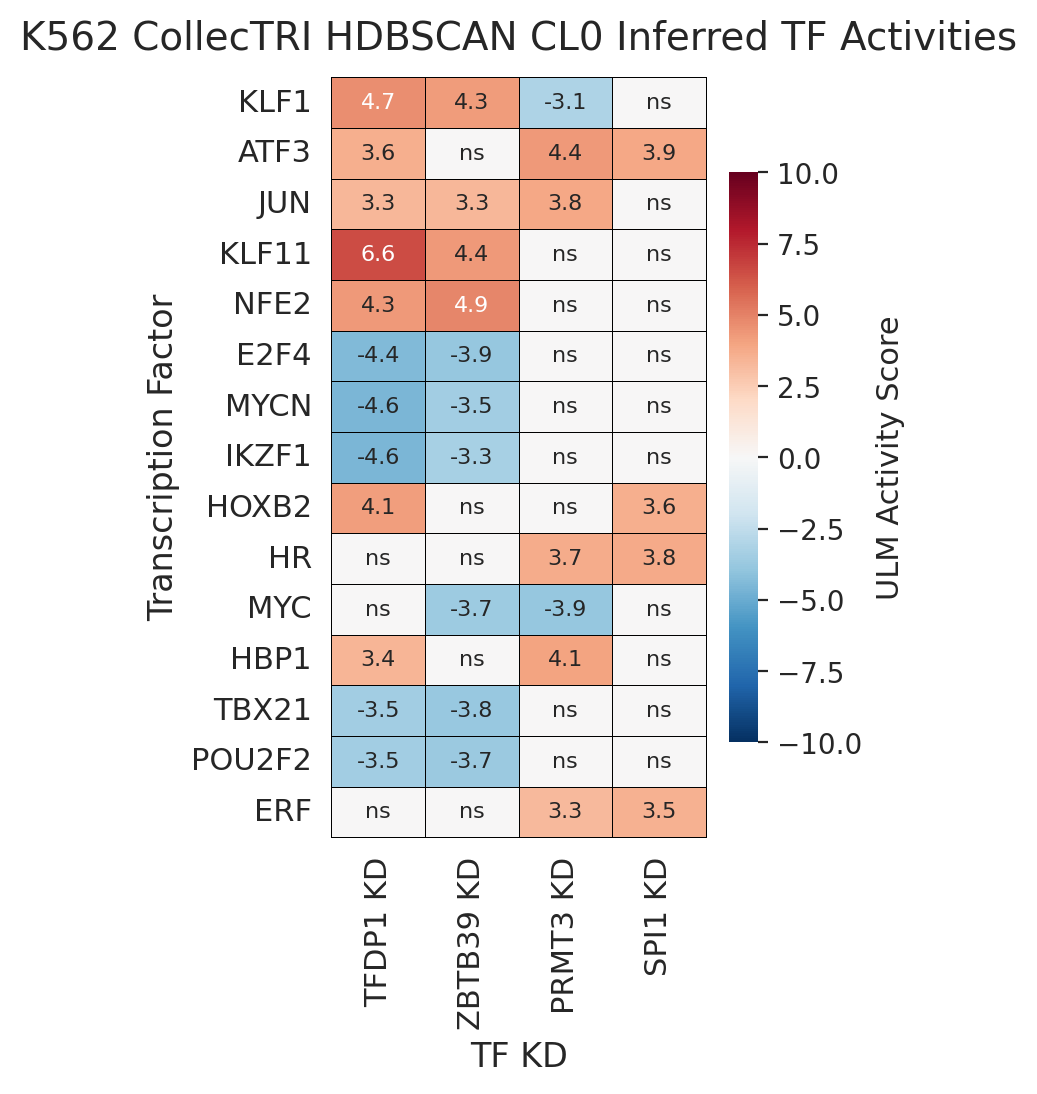

In [34]:
plot_tf_pw_activity_heatmap(k562_tf_acts_kds, cluster=0, cluster_df=hdbscan_clusters_k562, 
                            title="K562 CollecTRI HDBSCAN CL0 Inferred TF Activities",
                            xlabel="TF KD", ylabel="Transcription Factor", figsize=(3,5),
                            xvals="kds", top=15, sort_columns=True, cbar_size=0.75,
                            vmin=-10, vmax=10)

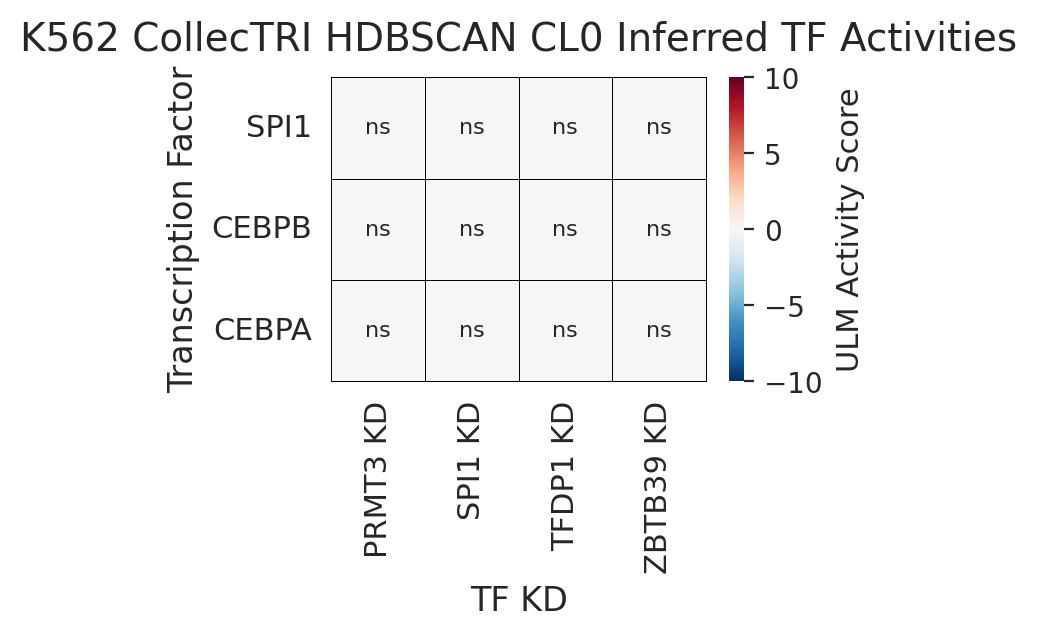

In [84]:
plot_tf_pw_activity_heatmap(k562_tf_acts_kds, cluster=0, cluster_df=hdbscan_clusters_k562, 
                            terms=["SPI1", "CEBPA", "CEBPB"],
                            title="K562 CollecTRI HDBSCAN CL0 Inferred TF Activities",
                            xlabel="TF KD", ylabel="Transcription Factor", figsize=(3,2),
                            xvals="kds", drop_nan_rows=False, sort_columns=True,
                            vmin=-10, vmax=10)

ChIP-seq targets

In [ ]:
find_encode_chea_tf_experiments(cl0_tf_kds, "K562")

ENCODE 2015: ['SPI1 K562 hg19']
ChEA 2022: ['SPI1 23127762 ChIP-Seq K562 Human']


In [ ]:
spi1_kd_up_degs = kd_deg_dict_k562_self_degs_direction["SPI1"]["UP"]
spi1_kd_down_degs = kd_deg_dict_k562_self_degs_direction["SPI1"]["DOWN"]
spi1_kd_degs = spi1_kd_up_degs | spi1_kd_down_degs
print(f"{len(spi1_kd_degs)} K562 SPI1 KD DEGs")

17 K562 SPI1 KD DEGs


In [ ]:
spi1_chip_seq_targets_encode = set(encode2015['SPI1 K562 hg19'])
print(f"{len(spi1_chip_seq_targets_encode)} K562 SPI1 ENCODE ChIP-seq targets")
spi1_chip_seq_targets_chea = set(chea['SPI1 23127762 ChIP-Seq K562 Human'])
print(f"{len(spi1_chip_seq_targets_chea)} K562 SPI1 ChEA ChIP-seq targets")

1543 K562 SPI1 ENCODE ChIP-seq targets
1157 K562 SPI1 ChEA ChIP-seq targets


In [ ]:
print(f"Intersection of K562 SPI1 KD DEGs and ENCODE ChIP-seq binding targets: "
      f"{len((spi1_chip_seq_targets_encode & spi1_kd_degs))} genes")
print(f"Up DEGs: {', '.join(sorted(list(spi1_chip_seq_targets_encode & spi1_kd_up_degs)))}")
print(f"Down DEGs: {', '.join(sorted(list(spi1_chip_seq_targets_encode & spi1_kd_down_degs)))}")

Intersection of K562 SPI1 KD DEGs and ENCODE ChIP-seq binding targets: 4 genes
Up DEGs: BTG2
Down DEGs: CTSS, DOCK2, PYCARD


In [ ]:
print(f"Intersection of K562 SPI1 KD DEGs and ChEA ChIP-seq binding targets: "
      f"{len((spi1_chip_seq_targets_chea & spi1_kd_degs))} genes")
print(f"Up DEGs: {', '.join(sorted(list(spi1_chip_seq_targets_chea & spi1_kd_up_degs)))}")
print(f"Down DEGs: {', '.join(sorted(list(spi1_chip_seq_targets_chea & spi1_kd_down_degs)))}")

Intersection of K562 SPI1 KD DEGs and ChEA ChIP-seq binding targets: 3 genes
Up DEGs: 
Down DEGs: AIF1, CTSS, DOCK2


# HDBSCAN Cluster 4

## Potential analysis

### Find cluster 4 neighbors + members

Which cluster 4 members are part of the cholesterol-down program?

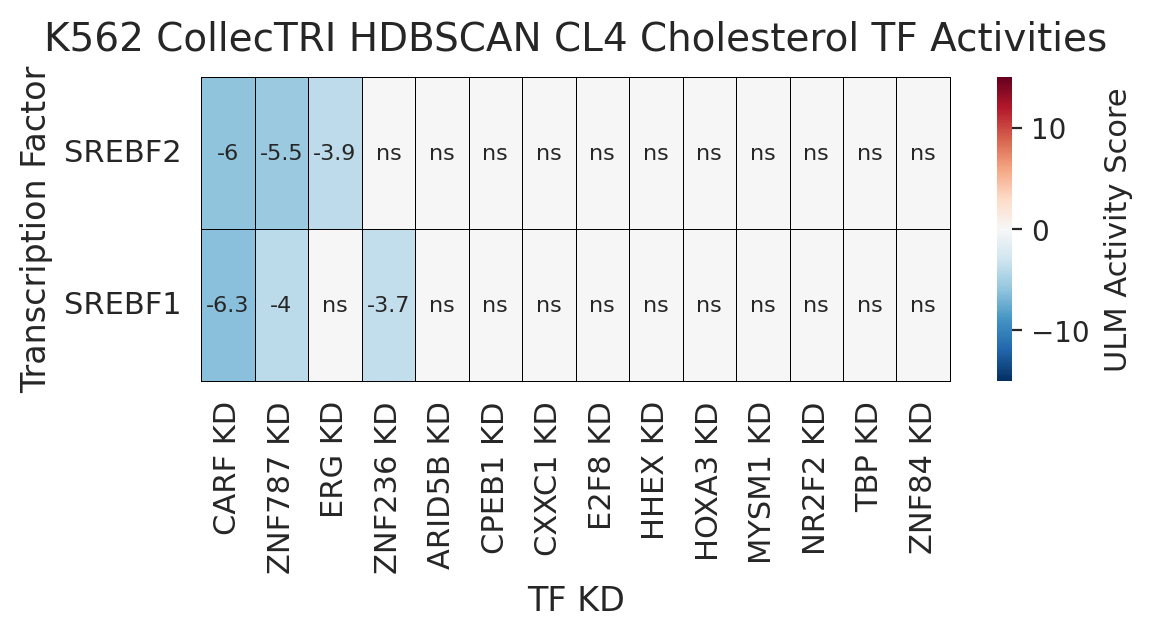

In [34]:
plot_tf_pw_activity_heatmap(k562_tf_acts_kds[['SREBF2', 'SREBF1']], cluster=4,
                            cluster_df=hdbscan_clusters_k562,
                            title="K562 CollecTRI HDBSCAN CL4 Cholesterol TF Activities",
                            xlabel="TF KD", ylabel="Transcription Factor", figsize=(6,2),
                            xvals="kds", top=25, sort_rows=False, sort_columns=True, 
                            cbar_size=1, vmin=-15, vmax=15)

Which potential neighbors have cholesterol-down signal?

In [35]:
subcluster_4 = ['CARF', 'NR2F2', 'ZNF787', 'ZNF236', 'ZNF84']
subcluster_4_nbrs = ['ZBTB24', 'DNMT1', 'NKX6-1']
subcluster_4_plus_nbrs = subcluster_4 + subcluster_4_nbrs
subcluster_4_nbrs_rename = {'ZBTB24 KD': 'ZBTB24 KD (nbr)', 'DNMT1 KD': 'DNMT1 KD (nbr)',
                            'NKX6-1 KD': 'NKX6-1 KD (nbr)'}

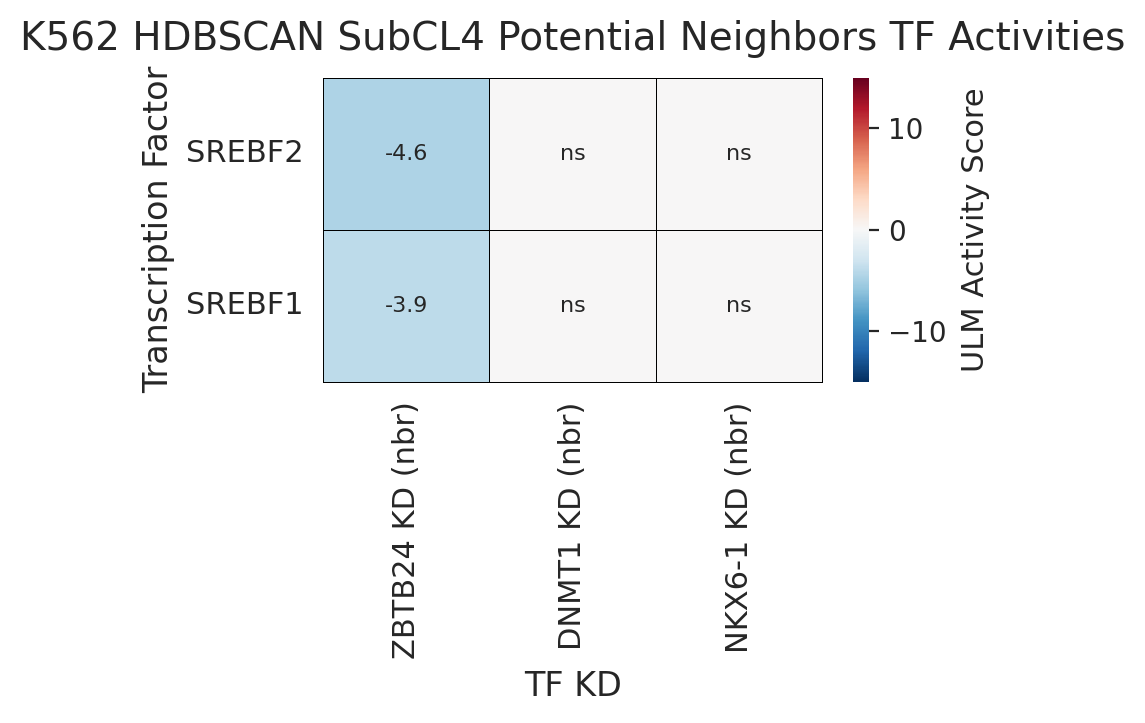

In [56]:
plot_tf_pw_activity_heatmap(k562_tf_acts_kds[['SREBF2', 'SREBF1']],
                            kds=subcluster_4_nbrs, 
                            rename_columns=subcluster_4_nbrs_rename,
                            title="K562 HDBSCAN SubCL4 Potential Neighbors TF Activities",
                            xlabel="TF KD", ylabel="Transcription Factor", figsize=(4,2),
                            xvals="kds", top=25, sort_rows=False, sort_columns=True, 
                            cbar_size=1, vmin=-15, vmax=15)

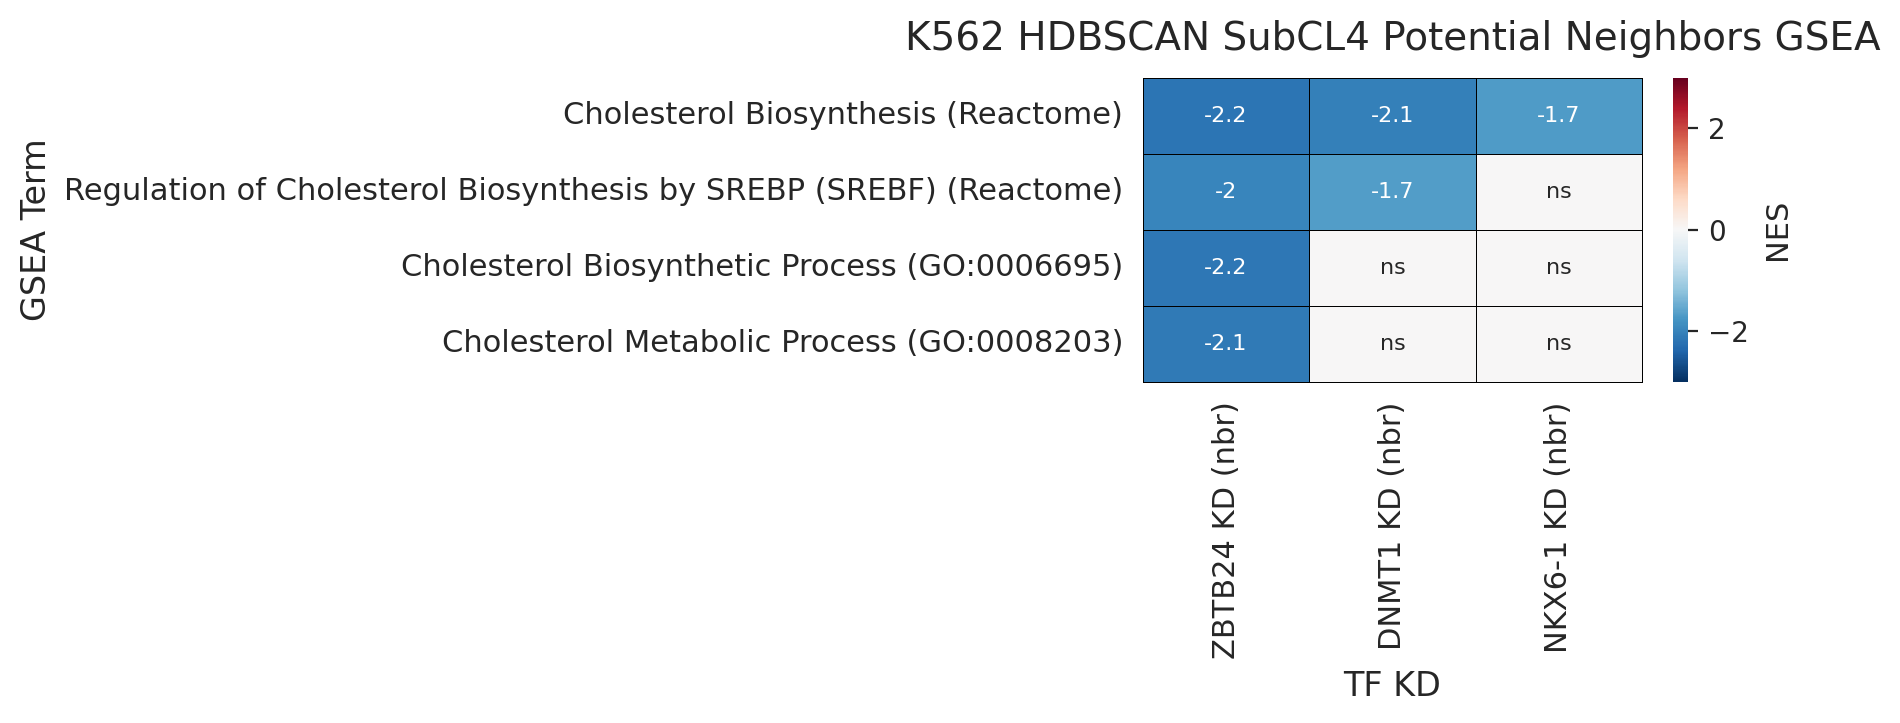

In [57]:
cholesterol_terms = ['Cholesterol Biosynthetic Process (GO:0006695)',
                      'mTORC1 Signaling', 'Cholesterol Biosynthesis',
                      'Cholesterol Homeostasis', 'Cholesterol Metabolic Process (GO:0008203)',
                      'Regulation of Cholesterol Biosynthesis by SREBP (SREBF)']
_ = plot_gsea_heatmap(k562_gsea_results, kds=subcluster_4_nbrs,
                    title="K562 HDBSCAN SubCL4 Potential Neighbors GSEA",
                    terms=cholesterol_terms, rename_kds=subcluster_4_nbrs_rename,
                    kd_col="TF KD", xlabel="TF KD",
                    cbar_size=1, figsize=(4,2),
                    cbar_label="NES")

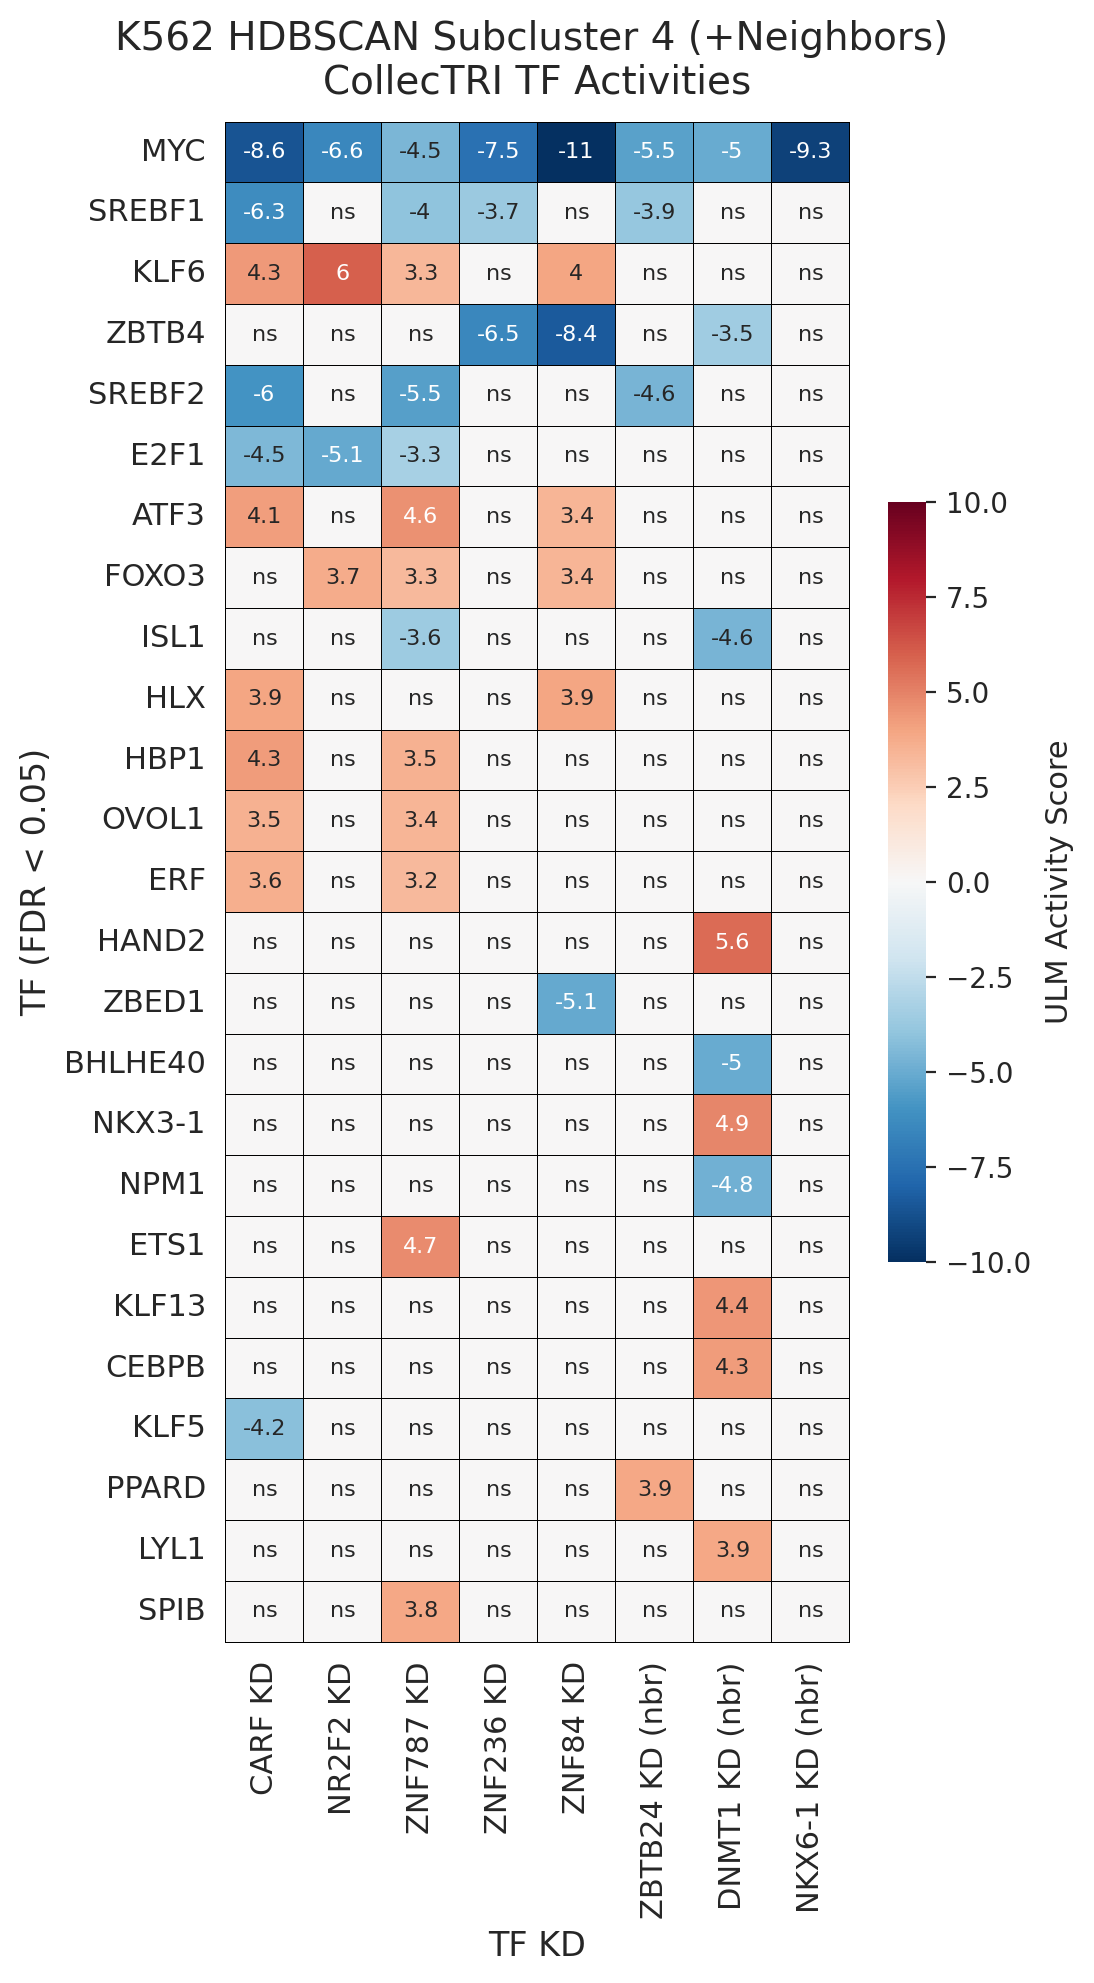

In [58]:
plot_tf_pw_activity_heatmap(k562_tf_acts_kds, kds=subcluster_4_plus_nbrs,
                            rename_columns=subcluster_4_nbrs_rename,
                            title="K562 HDBSCAN Subcluster 4 (+Neighbors) \nCollecTRI TF Activities",
                            xlabel="TF KD", ylabel="TF (FDR < 0.05)", top=25, figsize=(5,10),
                            xvals="kds", 
                            cbar_size=0.5, vmin=-10, vmax=10)

Include neighbor ZBTB24

## Analysis

Cholesterol biosynthesis down cluster

In [59]:
subcl4 = ['CARF', 'NR2F2', 'ZNF787', 'ZNF236']
subcl4_nbrs = ['ZBTB24', 'DNMT1']
subcl4_plus_nbrs = ['CARF', 'ZNF787', 'ZBTB24', 'NR2F2', 'ZNF236']
subcl4_nbrs_rename = {'ZBTB24 KD': 'ZBTB24 KD (nbr)'}

In [25]:
n_degs_df_k562[n_degs_df_k562.index.isin(subcl4_plus_nbrs)]

,n_DEGs
DNMT1,405
CARF,48
ZNF236,34
ZNF787,17
NR2F2,13
ZBTB24,8


In [78]:
print(', '.join(subcl4_plus_nbrs))

CARF, ZNF787, ZBTB24, DNMT1, NR2F2, ZNF236


GSEA

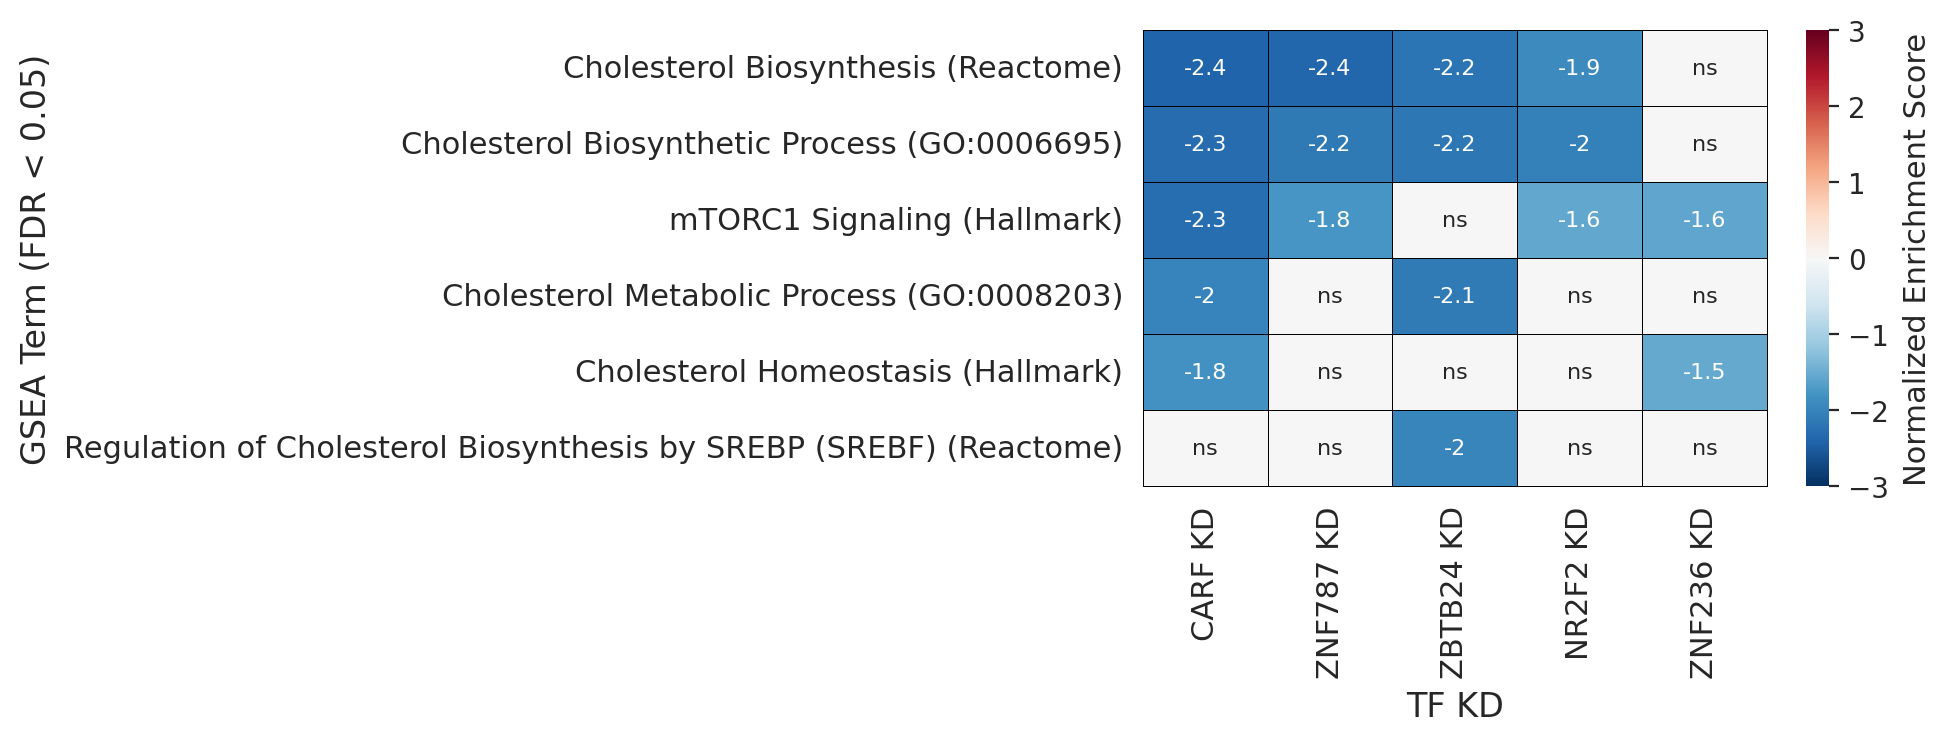

In [61]:
cholesterol_terms = ['Cholesterol Biosynthetic Process (GO:0006695)',
                      'mTORC1 Signaling', 'Cholesterol Biosynthesis',
                      'Cholesterol Homeostasis', 'Cholesterol Metabolic Process (GO:0008203)',
                      'Regulation of Cholesterol Biosynthesis by SREBP (SREBF)']
_ = plot_gsea_heatmap(k562_gsea_results, kds=subcl4_plus_nbrs,
                    terms=cholesterol_terms,
                    kd_col="TF KD", xlabel="TF KD", sort_columns=False,
                    cbar_size=1, figsize=(5,3), ylabel="GSEA Term (FDR < 0.05)",
                    cbar_label="Normalized Enrichment Score",
                    save_path="/home/ranwyl/figures_tf_project/k562_subcl4_gsea.png",
                    save_format="png", dpi=300)

SREBF1 and SREBF2 have negatively enriched TF activities but are not down DEGs

In [41]:
cholesterol_tfs = ['SREBF2', 'SREBF1']
cholesterol_tf_categories = {'Sterol Regulators': ['SREBF2', 'SREBF1']}
cholesterol_tf_colors = {'Sterol Regulators': "#FCE029"}

Starting..
Calculating row orders..
Reordering rows..
Calculating col orders..
Reordering cols..
Plotting matrix..
Plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 7.5 mm


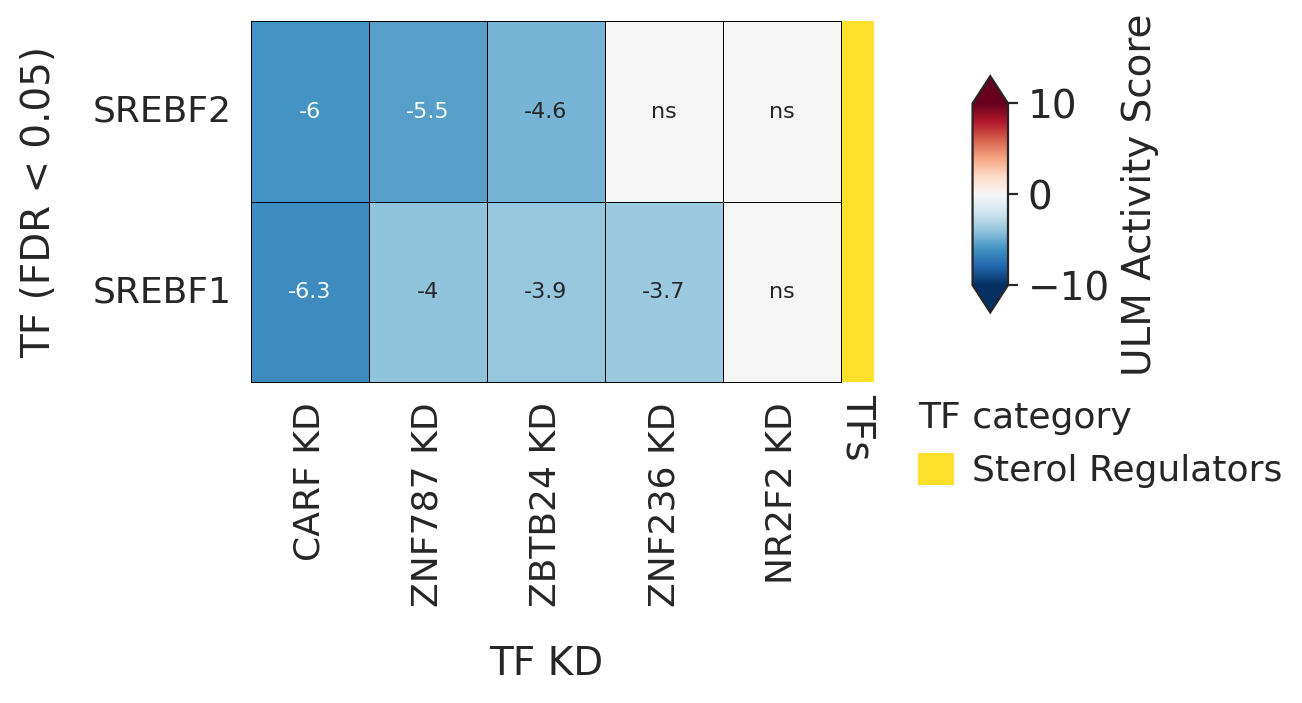

In [58]:
plot_tf_pw_activity_heatmap(k562_tf_acts_kds, kds=subcl4_plus_nbrs,
                            terms=cholesterol_tfs,
                            xlabel="TF KD", ylabel="TF (FDR < 0.05)", figsize=(4,2),
                            xvals="kds", sort_rows=False, sort_columns=True, 
                            vmin=-10, vmax=10, annot_legend_position=(1.1, 0),
                            annotations_for_bars=cholesterol_tf_categories, 
                            annotation_colors=cholesterol_tf_colors, ylabel_pad=65,
                            xlabel_pad=90,
                            save_path="/home/ranwyl/figures_tf_project/k562_subcl4_cholesterol_tf_acts.png",
                            save_format="png", dpi=300)

In [ ]:
plot_tf_pw_activity_heatmap(k562_tf_acts_kds, kds=subcl4_plus_nbrs,
                            rename_columns=subcl4_nbrs_rename, terms=cholesterol_tfs,
                            xlabel="TF KD", ylabel="TF (FDR < 0.05)", figsize=(5,2),
                            xvals="kds", sort_rows=False, sort_columns=False, 
                            cbar_size=1, vmin=-10, vmax=10)

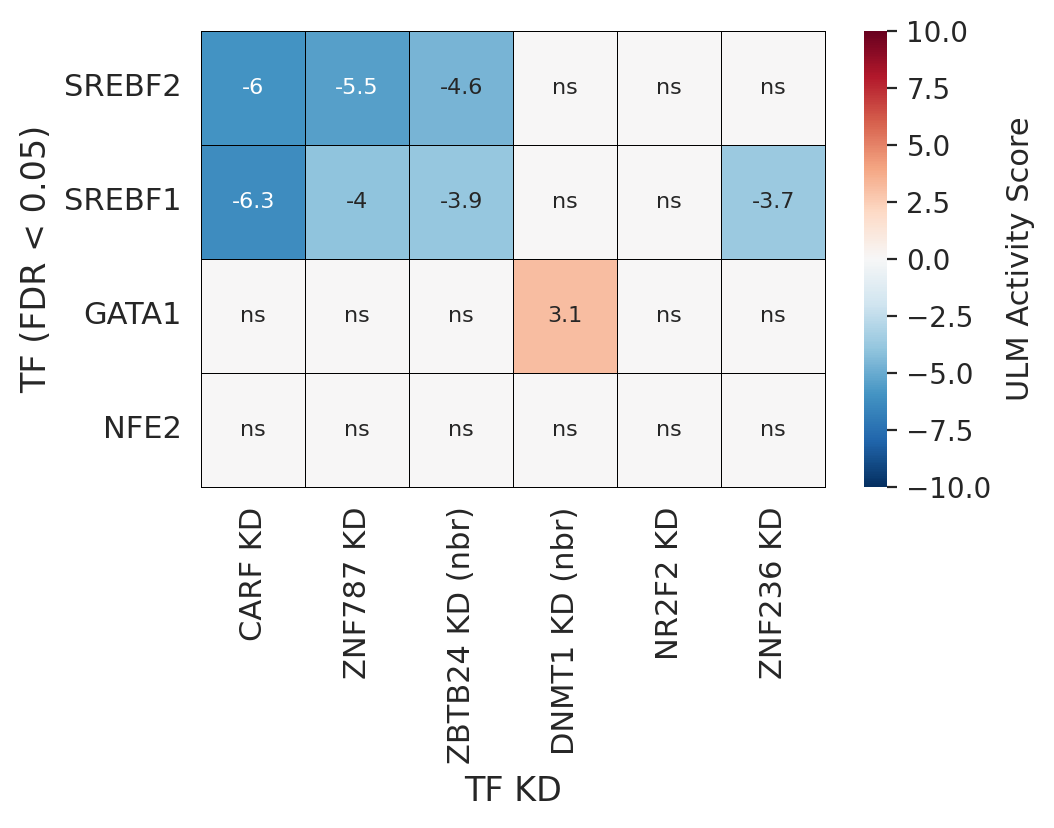

In [106]:
plot_tf_pw_activity_heatmap(k562_tf_acts_kds[['SREBF2', 'SREBF1', 'GATA1', 'NFE2']], 
                            kds=subcl4_plus_nbrs,
                            rename_columns=subcl4_nbrs_rename,
                            xlabel="TF KD", ylabel="TF (FDR < 0.05)", figsize=(5,3),
                            xvals="kds", sort_rows=False, sort_columns=False, 
                            drop_nan_rows=False,
                            cbar_size=1, vmin=-10, vmax=10)

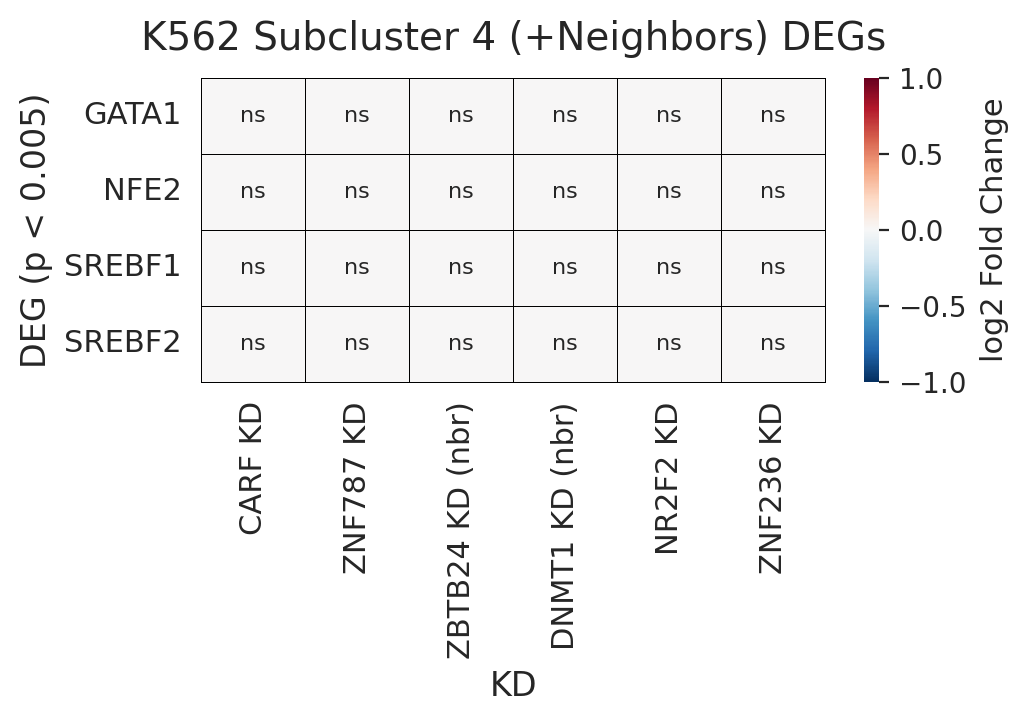

In [107]:
_ = plot_DEG_LFC_heatmap(k562_deg_lfcs, 
                         title="K562 Subcluster 4 (+Neighbors) DEGs", 
                         kds=subcl4_plus_nbrs,
                         rename_columns=subcl4_nbrs_rename,
                         ylabel="DEG (p < 0.005)", drop_nan_rows=False,
                         degs=['SREBF1', 'SREBF2', 'GATA1', 'NFE2'], sort_columns=False, figsize=(5,2))

Check erythroid GSEA terms

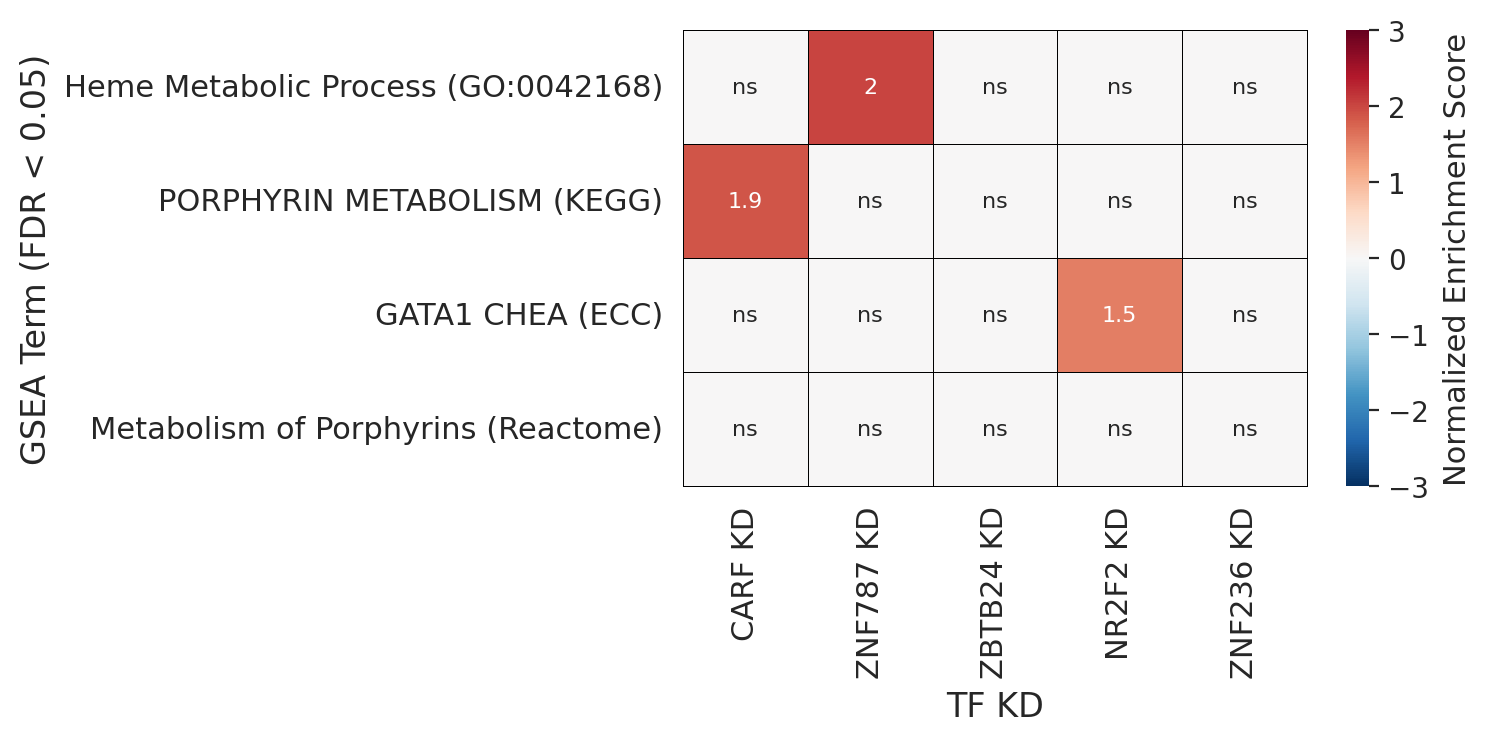

In [49]:
plot_gsea_heatmap(k562_gsea_results, kds=subcl4_plus_nbrs,
                    terms=erythroid_terms,
                    kd_col="TF KD", xlabel="TF KD", drop_nan_rows=False,
                    cbar_size=1, figsize=(5,3), sort_columns=False,
                    cbar_label="Normalized Enrichment Score", ylabel="GSEA Term (FDR < 0.05)",
                    save_path="/home/ranwyl/figures_tf_project/k562_subcl4_erythroid_gsea.png",
                    save_format="png", dpi=300)

Check erythroid TFs

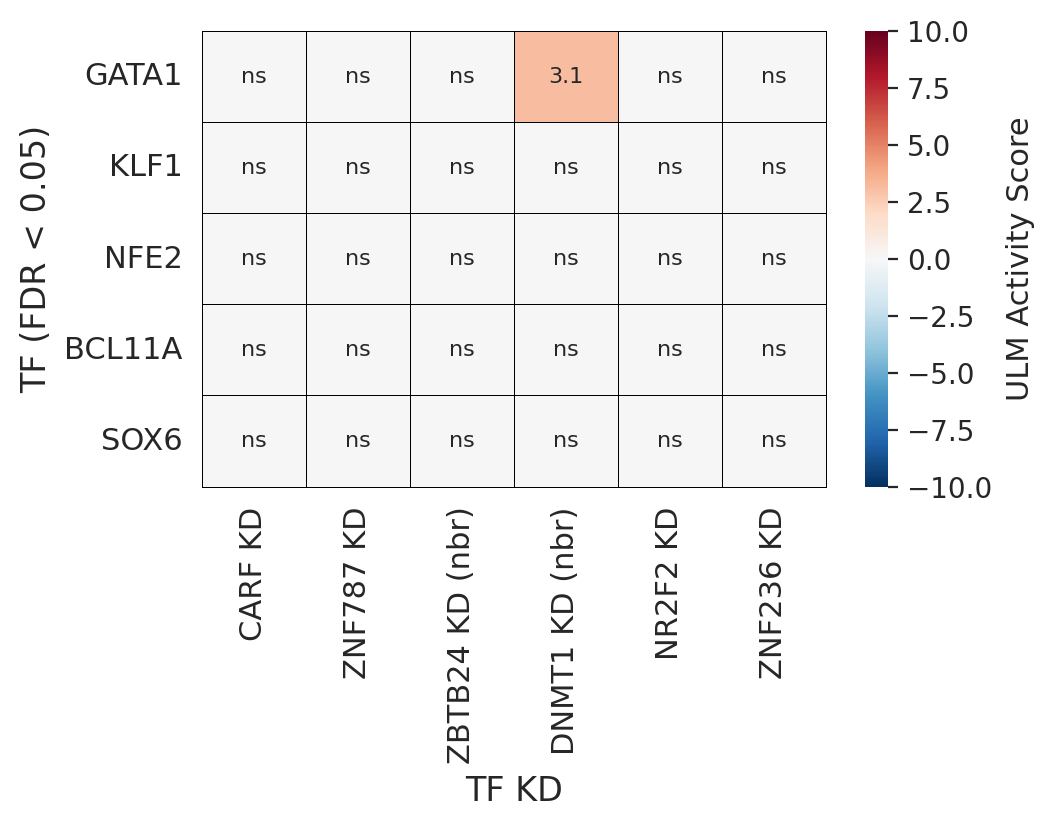

In [ ]:
plot_tf_pw_activity_heatmap(k562_tf_acts_kds, kds=subcl4_plus_nbrs,
                            rename_columns=subcl4_nbrs_rename, terms=erythroid_tfs,
                            xlabel="TF KD", ylabel="TF (FDR < 0.05)", figsize=(5,3),
                            xvals="kds", sort_rows=False, sort_columns=False,
                            drop_nan_rows=False,
                            cbar_size=1, vmin=-10, vmax=10)

Starting..
Calculating row orders..
Reordering rows..
Calculating col orders..
Reordering cols..
Plotting matrix..
Plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 7.5 mm


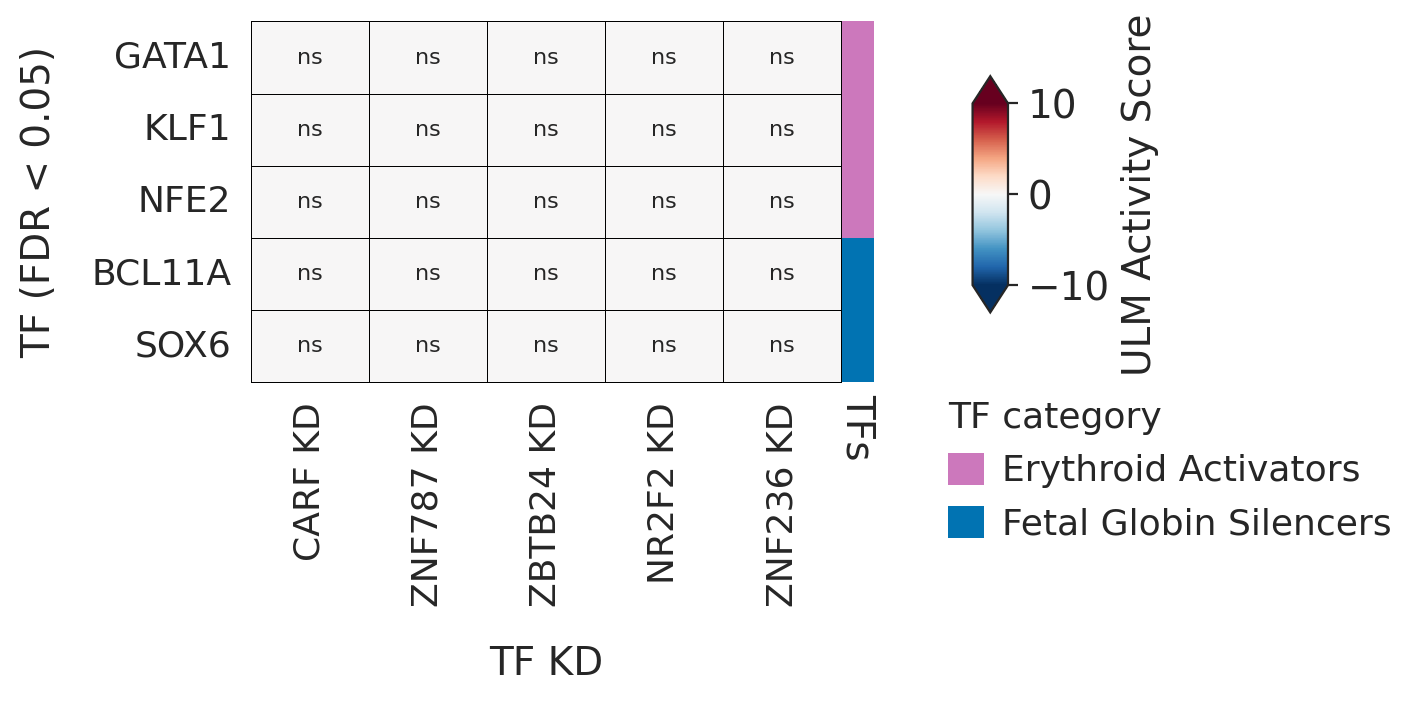

In [52]:
plot_tf_pw_activity_heatmap(k562_tf_acts_kds, kds=subcl4_plus_nbrs,
                            terms=erythroid_tfs,
                            xlabel="TF KD", ylabel="TF (FDR < 0.05)", figsize=(4,2),
                            xvals="kds", sort_rows=False, sort_columns=False, 
                            vmin=-10, vmax=10, annot_legend_position=(1.15, 0),
                            annotations_for_bars=erythroid_tf_categories, 
                            annotation_colors=erythroid_tf_colors, ylabel_pad=65,
                            xlabel_pad=90,
                            save_path="/home/ranwyl/figures_tf_project/k562_subcl4_erythroid_tf_acts.png",
                            save_format="png", dpi=300)

Check expression of erythroid and myeloid genes cluster

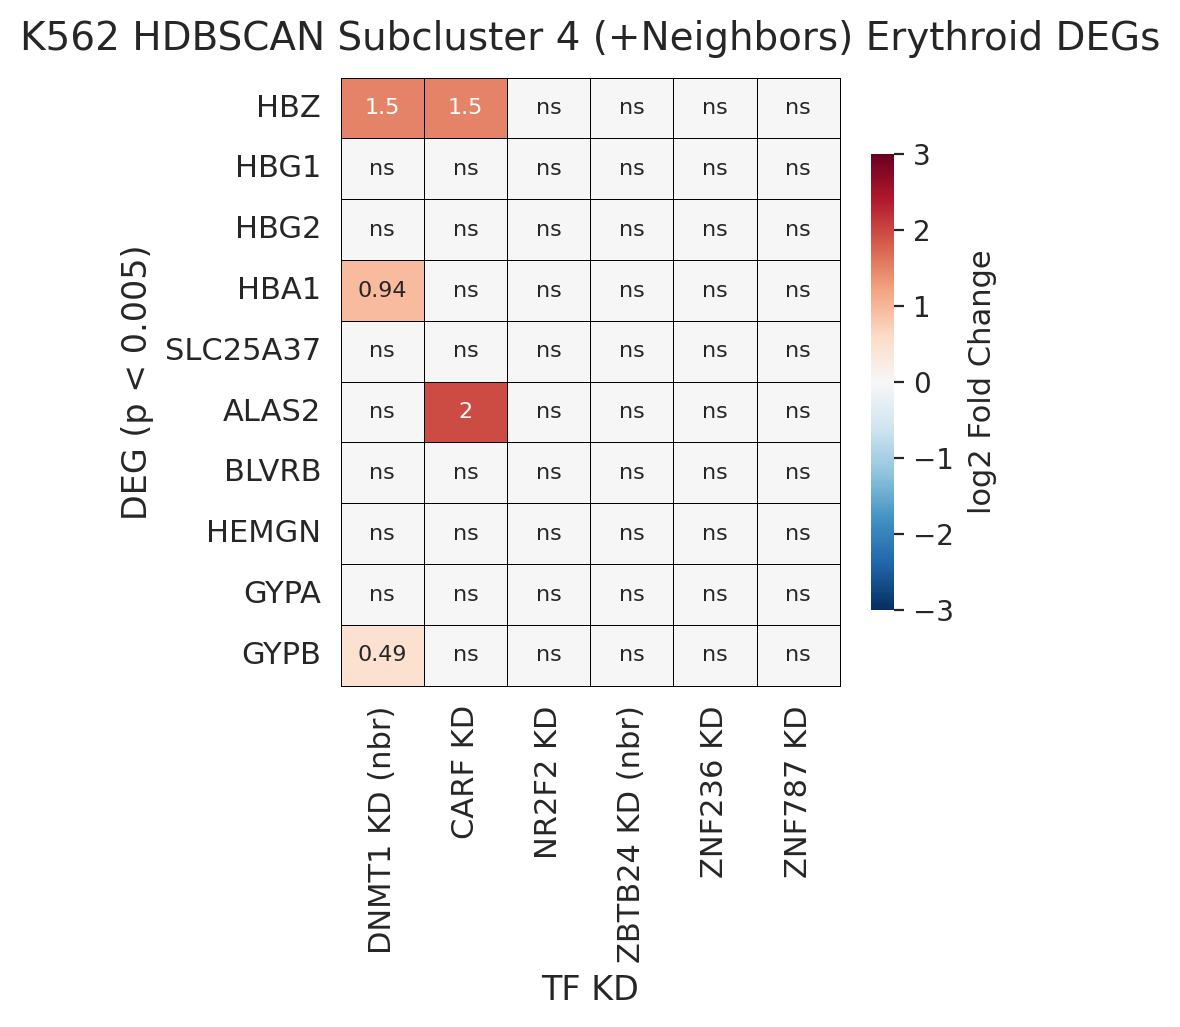

In [ ]:
_ = plot_DEG_LFC_heatmap(k562_deg_lfcs, 
                         title="K562 HDBSCAN Subcluster 4 (+Neighbors) Erythroid DEGs", 
                         kds=subcl4_plus_nbrs, xlabel="TF KD",
                         rename_columns=subcl4_nbrs_rename,
                         ylabel="DEG (p < 0.005)", vmin=-3, vmax=3, sort_rows=False,
                         degs=erythroid_degs, drop_nan_rows=False,
                         sort_columns=True, figsize=(4,4), cbar_size=0.75)

Starting..
Calculating row orders..
Reordering rows..
Calculating col orders..
Reordering cols..
Plotting matrix..
Plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 7.5 mm


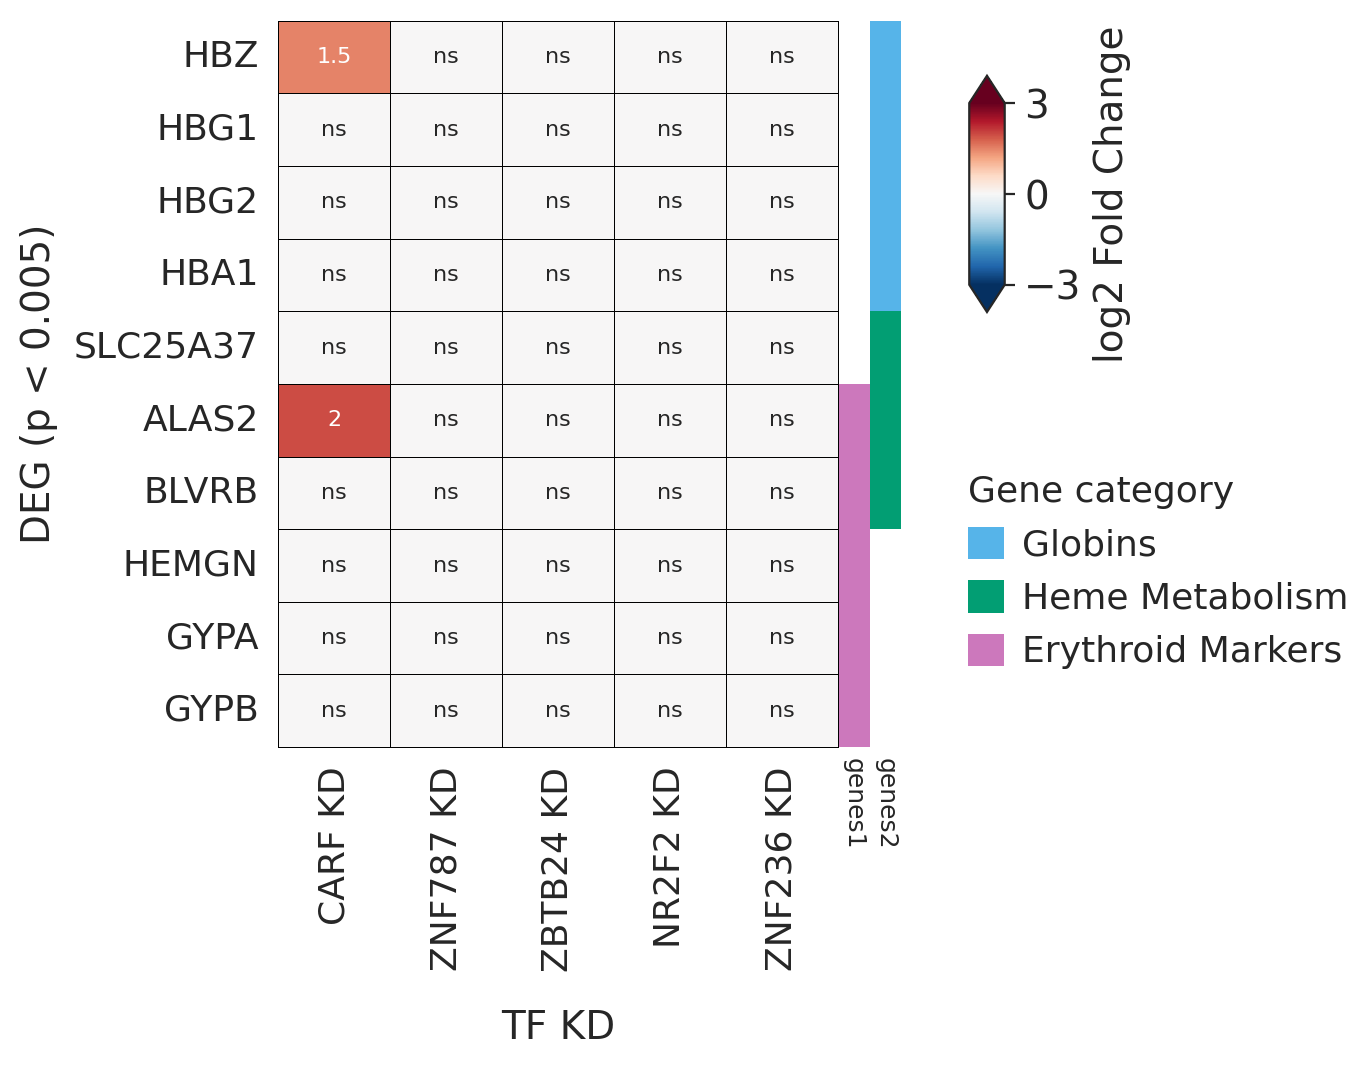

In [53]:
_ = plot_DEG_LFC_heatmap(k562_deg_lfcs, kds=subcl4_plus_nbrs,
                         ylabel="DEG (p < 0.005)", drop_nan_rows=False,
                         xlabel="TF KD",
                         annotations_for_bars=erythroid_deg_categories, 
                         annotation_colors=erythroid_deg_colors,
                         annotation_bar_1_label='Erythroid Markers',
                         n_annotation_bars=2, vmin=-3, vmax=3,
                         annot_legend_position=(1.2, 0.4),
                         degs=erythroid_degs, sort_columns=False, sort_rows=False,
                         figsize=(4,4), ylabel_pad=75, xlabel_pad=90,
                         save_path="/home/ranwyl/figures_tf_project/k562_subcl4_erythroid_degs.png",
                         save_format="png", dpi=300)

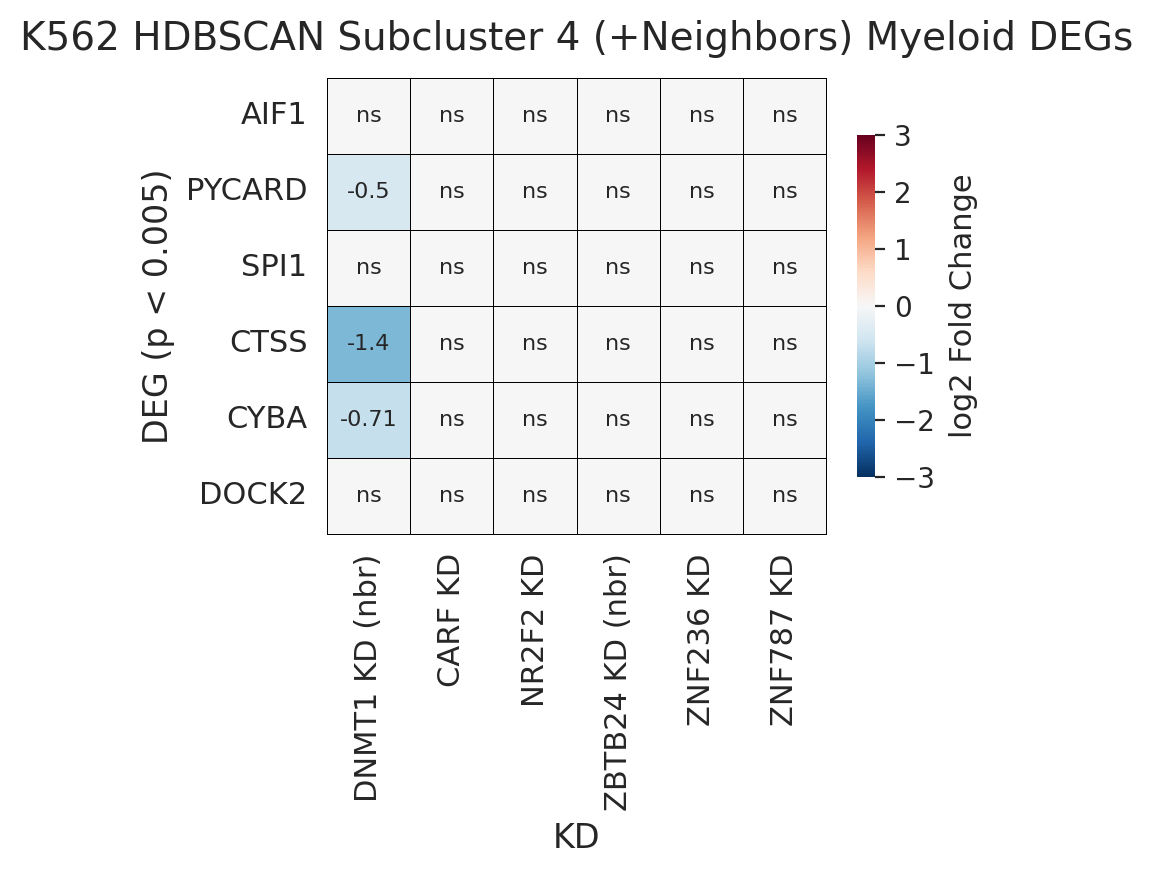

In [114]:
_ = plot_DEG_LFC_heatmap(k562_deg_lfcs, 
                         title="K562 HDBSCAN Subcluster 4 (+Neighbors) Myeloid DEGs", 
                         kds=subcl4_plus_nbrs,
                         rename_columns=subcl4_nbrs_rename,
                         ylabel="DEG (p < 0.005)", vmin=-3, vmax=3,
                         degs=myeloid_degs, drop_nan_rows=False, sort_rows=False,
                         sort_columns=True, figsize=(4,3), cbar_size=0.75)

Starting..
Calculating row orders..
Reordering rows..
Calculating col orders..
Reordering cols..
Plotting matrix..
Plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 7.5 mm


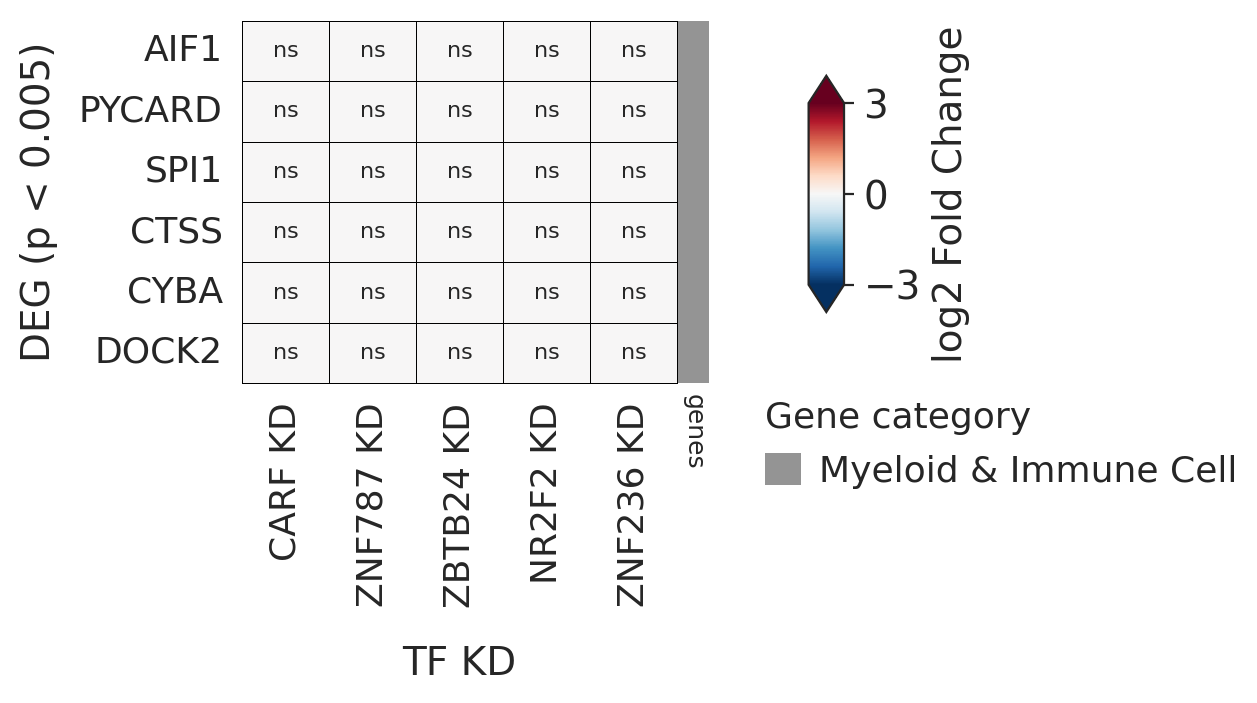

In [56]:
plot_DEG_LFC_heatmap(k562_deg_lfcs,
                         ylabel="DEG (p < 0.005)", drop_nan_rows=False, xlabel="TF KD",
                         kds=subcl4_plus_nbrs,
                         degs=myeloid_degs, sort_columns=False, sort_rows=False,
                         annot_legend_position=(1.16, 0), ylabel_pad=62,
                         annotations_for_bars=myeloid_deg_categories, 
                         annotation_colors=myeloid_deg_colors,
                         figsize=(3,2), vmin=-3, vmax=3,
                         save_path="/home/ranwyl/figures_tf_project/k562_subcl4_myeloid_degs.png",
                         save_format="png", dpi=300)

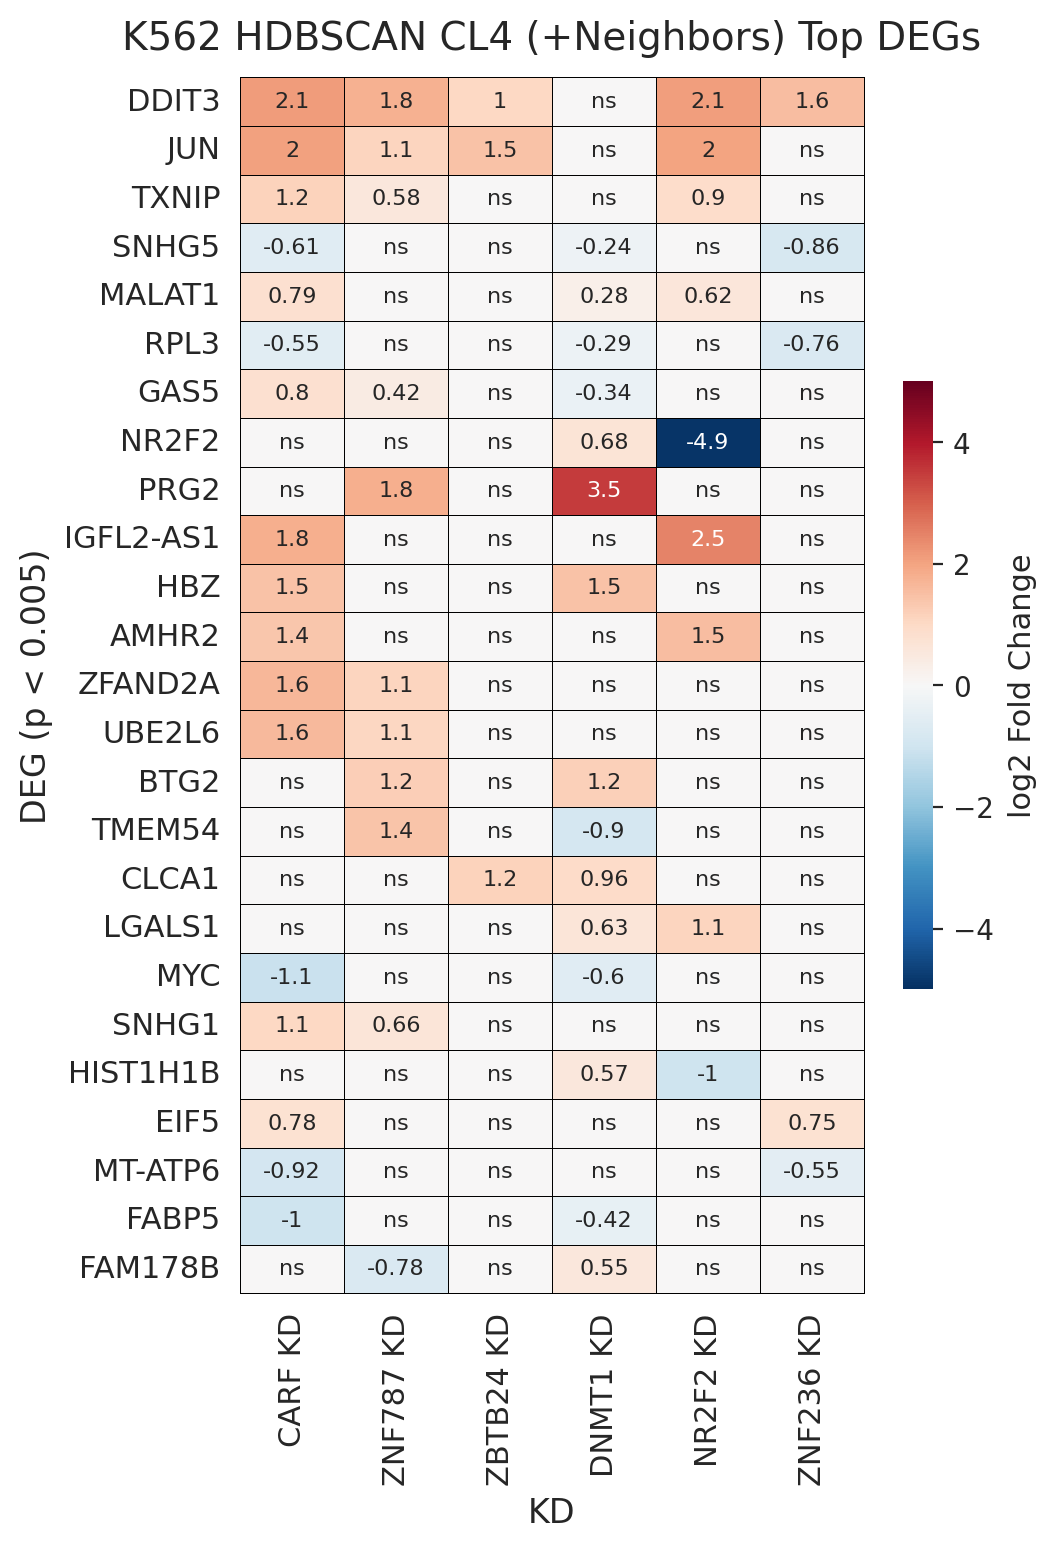

In [115]:
_ = plot_DEG_LFC_heatmap(k562_deg_lfcs, kds=subcl4_plus_nbrs,
                         title="K562 HDBSCAN CL4 (+Neighbors) Top DEGs", 
                         ylabel="DEG (p < 0.005)", top=25,
                         figsize=(5,8), cbar_size=0.5)

Compare to cholesterol GSEA terms in rest of dataset

In [ ]:
with pd.option_context('display.max_colwidth', 100):
    display(k562_kd_shared_gsea_terms[
        k562_kd_shared_gsea_terms["Term"].str.contains("sterol", case=False)
        ].sort_values(by=["Term", "Direction"]))

,Gene set,Term,Direction,# TF KDs,% TF KDs,Mean NES
1383,KEGG,CHOLESTEROL METABOLISM,DOWN,1,0,-2.178
391,Reactome,Cholesterol Biosynthesis,DOWN,13,3,-2.151
556,Reactome,Cholesterol Biosynthesis,UP,8,1,2.021
468,GO:BP,Cholesterol Biosynthetic Process (GO:0006695),DOWN,10,2,-2.217
1130,GO:BP,Cholesterol Biosynthetic Process (GO:0006695),UP,2,0,2.230
640,Hallmark,Cholesterol Homeostasis,DOWN,6,1,-1.904
44,Hallmark,Cholesterol Homeostasis,UP,144,33,1.748
1906,GO:BP,Cholesterol Homeostasis (GO:0042632),DOWN,1,0,-1.978
613,GO:BP,Cholesterol Metabolic Process (GO:0008203),DOWN,6,1,-2.198
1596,GO:BP,Cholesterol Metabolic Process (GO:0008203),UP,1,0,2.094


In [ ]:
build_mean_nes_inside_outside_kd_set_df(
    k562_gsea_enriched, subcl4_plus_nbrs,
    [('Cholesterol Biosynthetic Process (GO:0006695)', 'GO_Biological_Process_2025'),
     ('Cholesterol Biosynthesis', 'Reactome_Pathways_2024'),
     ('Cholesterol Homeostasis', 'MSigDB_Hallmark_2020'),
     ('Cholesterol Metabolic Process (GO:0008203)', 'GO_Biological_Process_2025'),
     ('Regulation of Cholesterol Biosynthesis by SREBP (SREBF)', 'Reactome_Pathways_2024'),
     ('mTORC1 Signaling', 'MSigDB_Hallmark_2020')],
    kd_col="TF KD", kd_set_label="SubCL4(+nbrs)", n_dataset_kds=429)

,Term,NES inside SubCL4(+nbrs),NES outside SubCL4(+nbrs),# enriched TF KDs inside,# enriched TF KDs outside
0,Cholesterol Biosynthetic Process (GO:0006695),-2.17,-1.13,4/6,8/423
1,Cholesterol Biosynthesis (Reactome),-2.19,-0.05,5/6,16/423
2,Cholesterol Homeostasis (Hallmark),-1.68,1.65,2/6,148/423
3,Cholesterol Metabolic Process (GO:0008203),-2.06,-1.40,2/6,5/423
4,Regulation of Cholesterol Biosynthesis by SREB...,-1.83,-1.38,2/6,6/423
5,mTORC1 Signaling (Hallmark),-1.80,-0.16,4/6,22/423


In [ ]:
build_mean_activity_inside_outside_kd_set_df(
    k562_tf_acts_kds, kds=subcl4_plus_nbrs, term_type="TF",
    terms=['SREBF1', 'SREBF2'],
    kd_set_label="CL7(+nbrs)"
)

,TF,Activity inside CL7(+nbrs),Activity outside CL7(+nbrs),# enriched KDs inside,# enriched KDs outside
0,SREBF1,-4.47,1.00,4/6,10/423
1,SREBF2,-5.39,-1.14,3/6,9/423


ChIP-seq targets

In [ ]:
find_encode_chea_tf_experiments(subcl4_plus_nbrs, "K562")

ENCODE 2015: ['NR2F2 K562 hg19']


# Individual TF KDs

## TAL1

### Test analyses

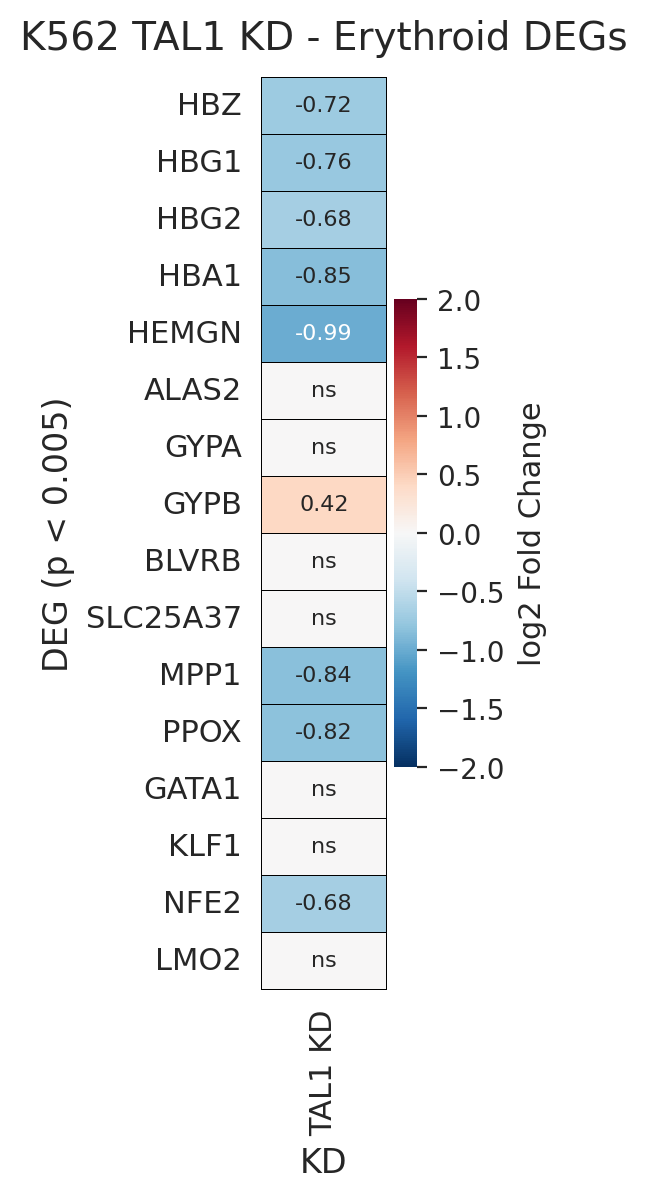

In [116]:
all_erythroid_genes = ['HBZ', 'HBG1', 'HBG2', 'HBA1', 'HEMGN', 'ALAS2', 'GYPA', 'GYPB', 'BLVRB', 
                          'SLC25A37', 'MPP1', 'PPOX', 'GATA1', 'KLF1', 'NFE2', 'LMO2']
_ = plot_DEG_LFC_heatmap(k562_deg_lfcs, 
                         title="K562 TAL1 KD - Erythroid DEGs", 
                         kds=['TAL1'], sort_rows=False,
                         ylabel="DEG (p < 0.005)", drop_nan_rows=False,
                         degs=all_erythroid_genes, 
                         figsize=(1,6), cbar_size=0.75,
                         vmin=-2, vmax=2)

### Results

DEGs

In [69]:
tal1_erythroid_degs = ['HEMGN', 'NFE2', 'MPP1', 'HBA1', 'HBG1', 'HBG2', 'HBZ', 'PPOX']
tal1_erythroid_deg_categories = {'Erythroid Markers and TFs': ['HEMGN', 'NFE2', 'MPP1'],
                                 'Globins': ['HBZ', 'HBG1', 'HBG2', 'HBA1'],
                  'Heme Metabolism': ['PPOX']}
tal1_erythroid_deg_colors = {'Erythroid Markers and TFs': '#CC78BC', 'Globins': '#56B4E9', 'Heme Metabolism': '#029E73'}

Starting..
Calculating row orders..
Reordering rows..
Calculating col orders..
Reordering cols..
Plotting matrix..
Plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 7.5 mm


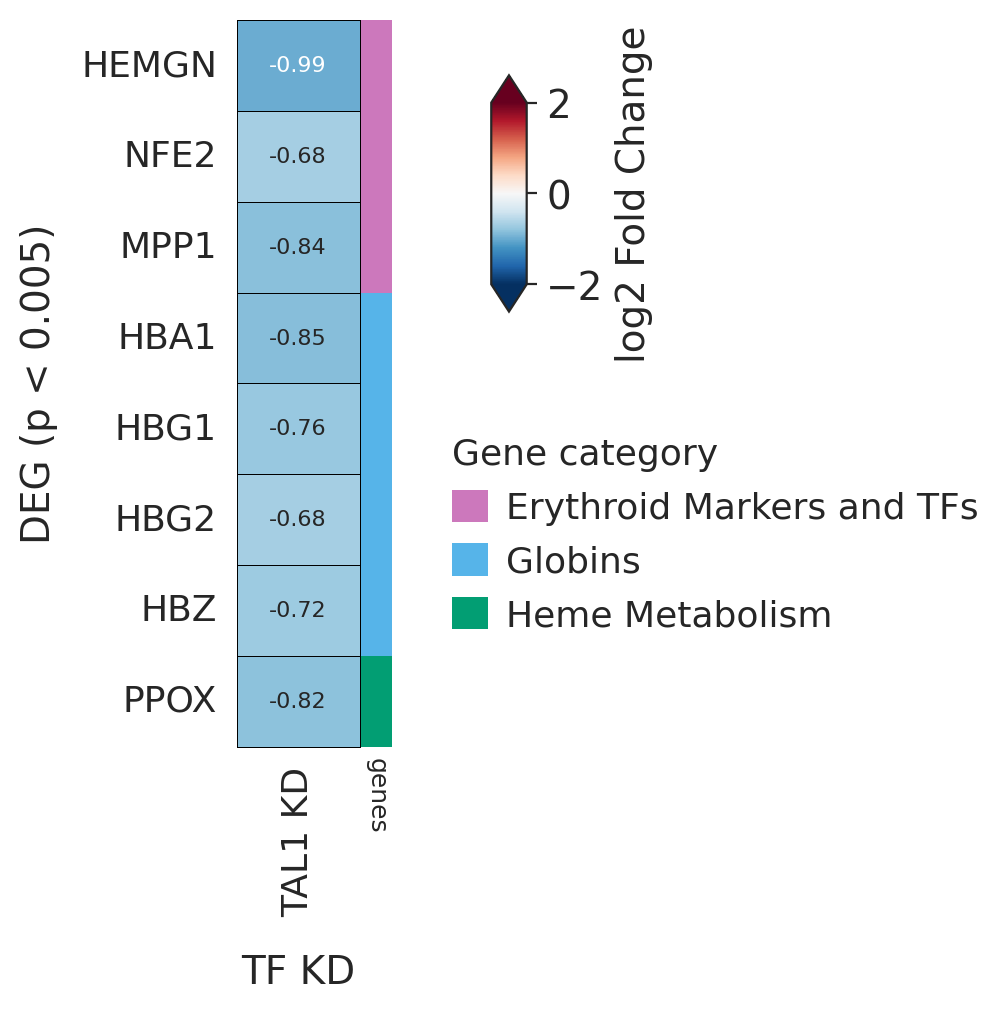

In [88]:
_ = plot_DEG_LFC_heatmap(k562_deg_lfcs, kds=['TAL1'],
                         ylabel="DEG (p < 0.005)", drop_nan_rows=False,
                         xlabel="TF KD", vmin=-2, vmax=2,
                         annotations_for_bars=tal1_erythroid_deg_categories, 
                         annotation_colors=tal1_erythroid_deg_colors,
                         annot_legend_position=(1.6, 0.45),
                         degs=tal1_erythroid_degs, sort_columns=True, sort_rows=False,
                         figsize=(1,4), ylabel_pad=60, xlabel_pad=70,
                         save_path="/home/ranwyl/figures_tf_project/k562_tal1_kd_erythroid_degs.png",
                         save_format="png", dpi=300)

Starting..
Calculating row orders..
Reordering rows..
Calculating col orders..
Reordering cols..
Plotting matrix..
Plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 7.5 mm


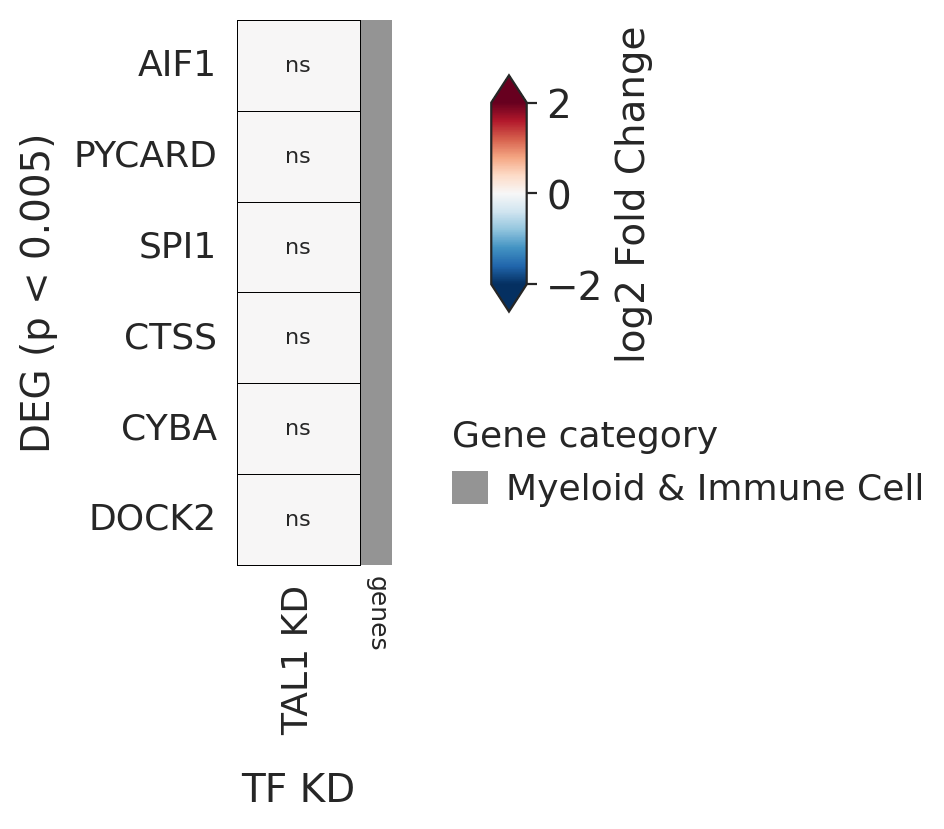

In [89]:
myeloid_degs = ['AIF1', 'PYCARD', 'SPI1', 'CTSS', 'CYBA', 'DOCK2']
myeloid_deg_categories = {'Myeloid & Immune Cell': ['AIF1', 'PYCARD', 'SPI1', 'CTSS', 'CYBA', 'DOCK2']}
myeloid_deg_colors = {'Myeloid & Immune Cell': '#949494'}
_ = plot_DEG_LFC_heatmap(k562_deg_lfcs, kds=['TAL1'],
                         ylabel="DEG (p < 0.005)", drop_nan_rows=False,
                         xlabel="TF KD", vmin=-2, vmax=2,
                         annotations_for_bars=myeloid_deg_categories, 
                         annotation_colors=myeloid_deg_colors,
                         annot_legend_position=(1.6, 0.3),
                         degs=myeloid_degs, sort_columns=True, sort_rows=False,
                         figsize=(1,3), ylabel_pad=60, xlabel_pad=70,
                         #save_path="/home/ranwyl/figures_tf_project/k562_tal1_kd_erythroid_degs.png",
                         save_format="png", dpi=300)

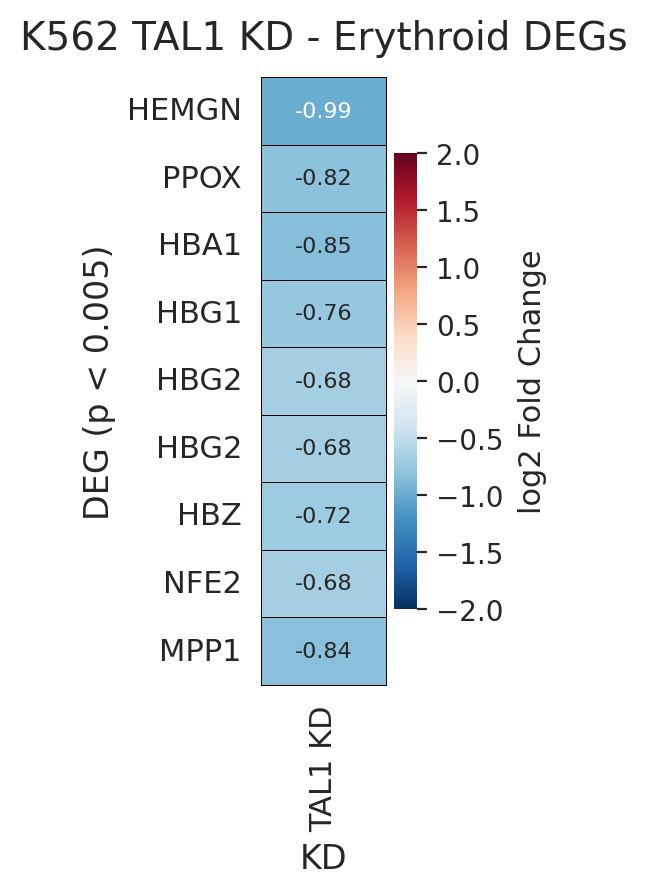

In [ ]:
_ = plot_DEG_LFC_heatmap(k562_deg_lfcs, 
                         title="K562 TAL1 KD - Erythroid DEGs", 
                         kds=['TAL1'], sort_rows=False,
                         ylabel="DEG (p < 0.005)",
                         degs=tal1_erythroid_degs, 
                         figsize=(1,4), cbar_size=0.75,
                         vmin=-2, vmax=2)

TF activities

In [83]:
tal1_kd_wald_df = k562_wald_df_kds.loc[["TAL1 KD"]].dropna(axis=1)
tal1_kd_degs = list(kd_deg_dict_k562["TAL1"])
print(len(tal1_kd_degs))

49


In [84]:
tal1_kd_tf_acts = k562_tf_acts_kds.loc[["TAL1 KD"]].dropna(axis=1)
print(f"TFs up: {tal1_kd_tf_acts[tal1_kd_tf_acts > 0].count().sum()}")
print(f"TFs down: {tal1_kd_tf_acts[tal1_kd_tf_acts < 0].count().sum()}")

TFs up: 30
TFs down: 4


In [ ]:
print(', '.join(tal1_kd_tf_acts[tal1_kd_tf_acts > 0].dropna(axis=1).columns.tolist()))

ATF2, ATF4, NFATC3, ATF3, DMTF1, ELK4, ETS1, FOXO3, STAT1, STAT2, XBP1, IRF1, KLF6, BCL11A, SOX6, RB1, ENO1, HMGA2, HBP1, CEBPB, CEBPG, VDR, HR, FOS, PRDM1, MAFA, SSRP1, TP53, FOXP3, IRF2


In [ ]:
print(', '.join(tal1_kd_tf_acts[tal1_kd_tf_acts < 0].dropna(axis=1).columns.tolist()))

MYC, KLF11, ISL1, LMO2


In [95]:
tal1_tfs = ['BCL11A', 'SOX6', 'LMO2']
tal1_tf_categories = {
                     'Fetal Globin Silencers': ['BCL11A', 'SOX6'],
                     'Erythroid Activators': ['LMO2']}
tal1_tf_colors = {'Erythroid Activators': '#CC78BC', 'Fetal Globin Silencers': '#0173B2'}

Starting..
Calculating row orders..
Reordering rows..
Calculating col orders..
Reordering cols..
Plotting matrix..
Plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 7.5 mm


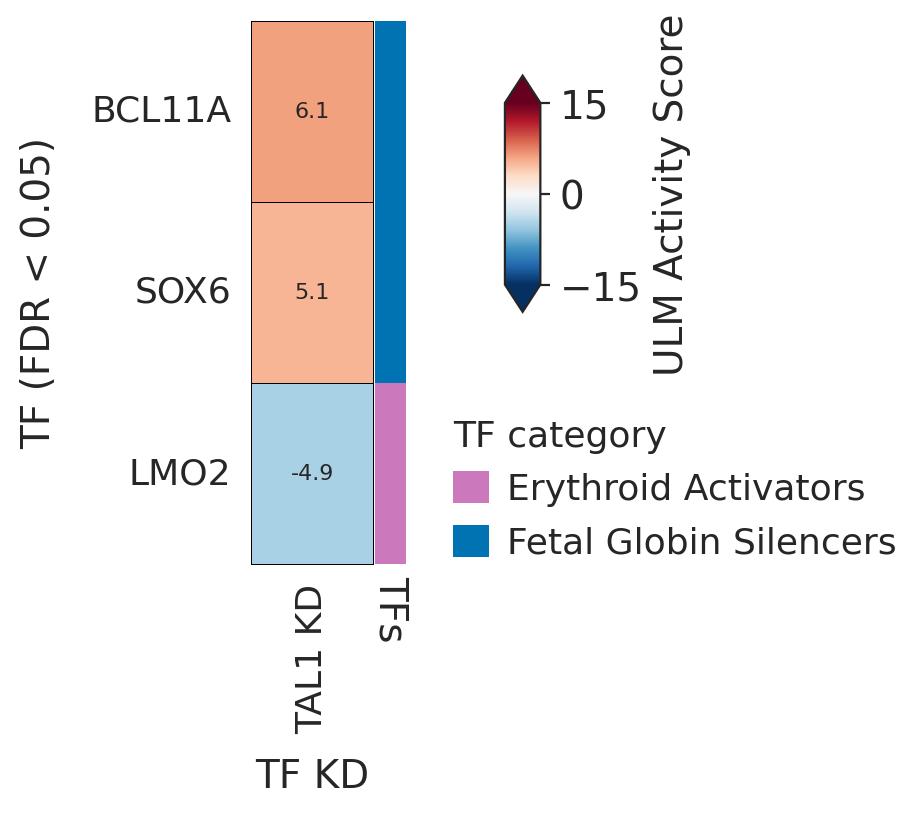

In [97]:
plot_tf_pw_activity_heatmap(k562_tf_acts_kds, kds=['TAL1'],
                            terms=tal1_tfs,
                            xlabel="TF KD", ylabel="TF (FDR < 0.05)", figsize=(1,3),
                            xvals="kds", sort_rows=False, sort_columns=True, 
                            vmin=-15, vmax=15, annot_legend_position=(1.5, 0.3),
                            annotations_for_bars=tal1_tf_categories, 
                            annotation_colors=tal1_tf_colors, ylabel_pad=65,
                            xlabel_pad=65,
                            save_path="/home/ranwyl/figures_tf_project/k562_tal1_kd_tf_acts.png",
                            save_format="png", dpi=300)

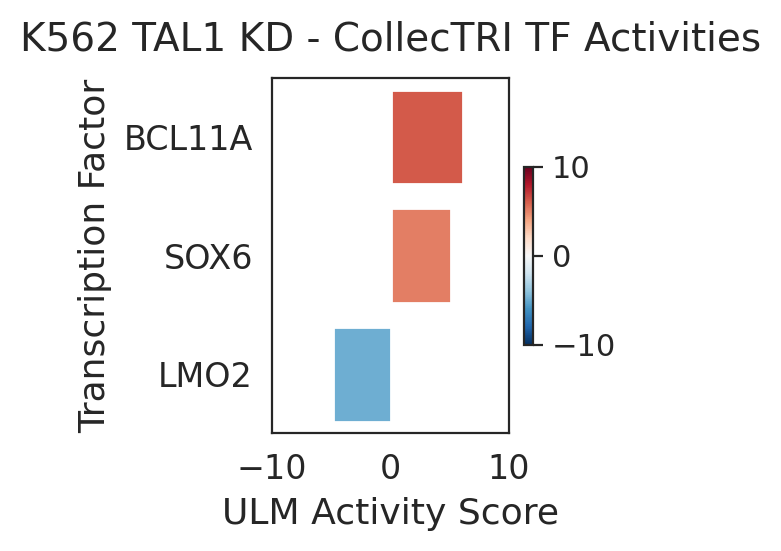

In [ ]:
plot_activity_barplot(tal1_kd_tf_acts[tal1_tfs], figsize=(3,3), ylabel="Transcription Factor",
                     title="K562 TAL1 KD - CollecTRI TF Activities", vmin=-10, vmax=10)

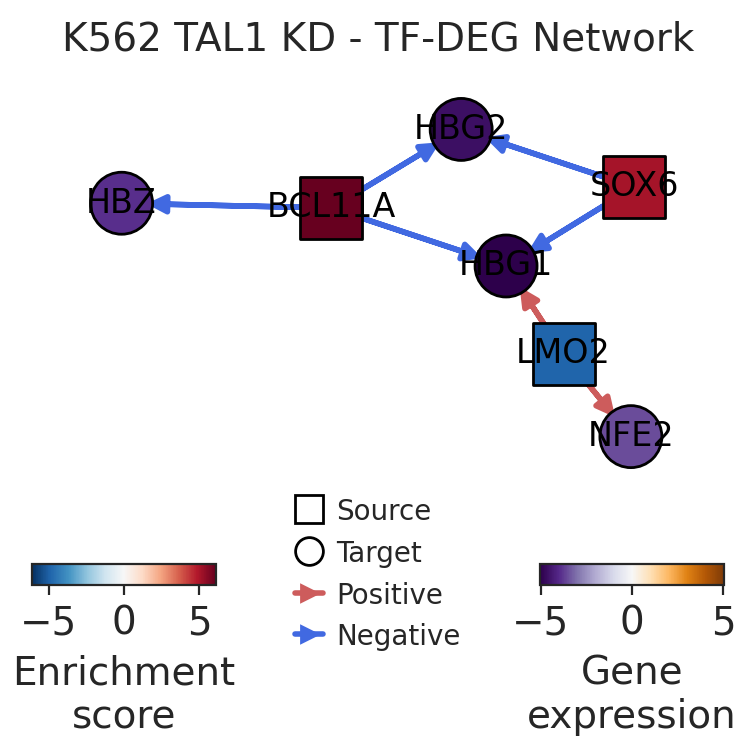

In [85]:
plot_tf_activity_network(grn=collectri, 
                         wald_df=tal1_kd_wald_df, 
                         tf_activities=tal1_kd_tf_acts,
                         filter_genes_to_degs=True,
                         degs=tal1_kd_degs,
                         sources=['BCL11A', 'SOX6', 'LMO2'],
                         targets=10,
                         figsize=(4,4),
                         size_node=10,
                         size_label=0.75,
                         title="K562 TAL1 KD - TF-DEG Network")

ChIP-seq data

In [ ]:
tal1_kd_up_degs = kd_deg_dict_k562_self_degs_direction["TAL1"]["UP"]
tal1_kd_down_degs = kd_deg_dict_k562_self_degs_direction["TAL1"]["DOWN"]
tal1_kd_degs = tal1_kd_up_degs | tal1_kd_down_degs
print(f"{len(tal1_kd_degs)} K562 TAL1 KD DEGs")

50 K562 TAL1 KD DEGs


In [ ]:
print([expt for expt in encode2015 if "TAL1" in expt and "K562" in expt])

['TAL1 K562 hg19']


In [ ]:
tal1_chip_seq_targets = set(encode2015['TAL1 K562 hg19'])
print(f"{len(tal1_chip_seq_targets)} K562 TAL1 ChIP-seq targets")

2000 K562 TAL1 ChIP-seq targets


In [ ]:
print(f"Intersection of K562 TAL1 KD DEGs and ChIP-seq binding targets: "
      f"{len((tal1_chip_seq_targets & tal1_kd_degs))} genes")

Intersection of K562 TAL1 KD DEGs and ChIP-seq binding targets: 7 genes


In [ ]:
print(f"TAL1 up DEGs & ChIP-seq binding targets ({len(tal1_chip_seq_targets & tal1_kd_up_degs)} genes): "
      f"{', '.join(sorted(list(tal1_chip_seq_targets & tal1_kd_up_degs)))}")
print(f"TAL1 down DEGs & ChIP-seq binding targets ({len(tal1_chip_seq_targets & tal1_kd_down_degs)} genes): "
      f"{', '.join(sorted(list(tal1_chip_seq_targets & tal1_kd_down_degs)))}")

TAL1 up DEGs & ChIP-seq binding targets (5 genes): IER3, JUN, RAB11FIP1, RHOB, SAT1
TAL1 down DEGs & ChIP-seq binding targets (2 genes): HEMGN, MPP1


### Potential results

Choose some DEGs from Replogle erythroid gene expr cluster

In [ ]:
plot_DEG_LFC_heatmap(k562_deg_lfcs, 
                         title="K562 TAL1 KD - Replogle Erythroid DEGs", 
                         kds=['TAL1'],
                         ylabel="DEG (p < 0.005)",
                         degs=replogle_erythroid_genes, 
                         figsize=(1,4), cbar_size=0.75,
                         vmin=-2, vmax=2)

No myeloid-specific genes from Replogle myeloid gene expression cluster are TAL1 KD DEGs

In [ ]:
plot_DEG_LFC_heatmap(k562_deg_lfcs, 
                         title="K562 TAL1 KD - Replogle Myeloid DEGs", 
                         kds=['TAL1'],
                         ylabel="DEG (p < 0.005)",
                         degs=replogle_myeloid_genes, 
                         figsize=(1,4), cbar_size=0.75,
                         vmin=-2, vmax=2)

Use TF-DEG network instead

In [ ]:
plot_tf_activity_network(grn=collectri, 
                         wald_df=tal1_kd_wald_df, 
                         tf_activities=tal1_kd_tf_acts,
                         filter_genes_to_degs=False,
                         sources=['BCL11A', 'SOX6', 'LMO2'],
                         targets=5,
                         figsize=(5,5),
                         size_node=15,
                         size_label=1,
                         title="K562 TAL1 KD TF-Target Network")

## DNMT1 KD

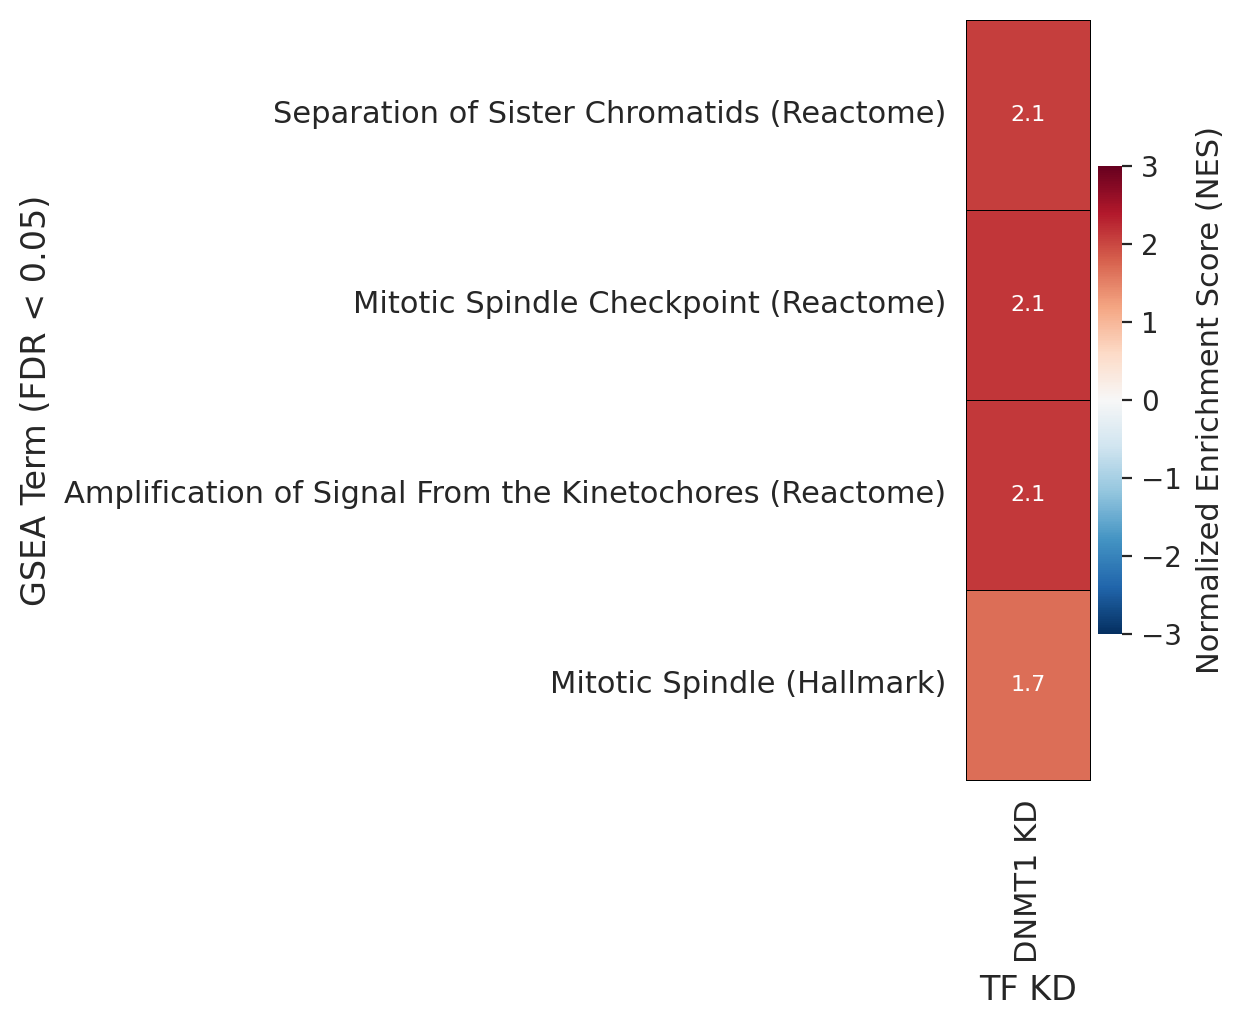

In [ ]:
dnmt1_gsea_terms = [
    'Separation of Sister Chromatids', 'Mitotic Spindle Checkpoint', 'Amplification of Signal From the Kinetochores', 
    'Mitotic Spindle']
_ = plot_gsea_heatmap(k562_gsea_results, kds=['DNMT1'], 
                    sort_columns=False, ylabel="GSEA Term (FDR < 0.05)",
                    terms=dnmt1_gsea_terms, sort_rows=False,
                    kd_col="TF KD", xlabel="TF KD", cbar_size=1,
                    figsize=(1,5), cbar_label="Normalized Enrichment Score (NES)",
                    #save_path="/home/ranwyl/figures_tf_project/kolf_dnmt1_kd_gsea.png",
                    save_format="png", dpi=300)

## MAX KD

In [ ]:
max_kd_up_degs = kd_deg_dict_k562_self_degs_direction["MAX"]["UP"]
max_kd_down_degs = kd_deg_dict_k562_self_degs_direction["MAX"]["DOWN"]
max_kd_degs = max_kd_up_degs | max_kd_down_degs
print(f"{len(max_kd_degs)} K562 MAX KD DEGs")

150 K562 MAX KD DEGs


In [ ]:
print([expt for expt in encode2015 if "MAX" in expt and "K562" in expt])

['MAX K562 hg19']


In [ ]:
max_chip_seq_targets = set(encode2015['MAX K562 hg19'])
print(f"{len(max_chip_seq_targets)} K562 MAX ChIP-seq targets")

3845 K562 MAX ChIP-seq targets


In [ ]:
print(f"Intersection of K562 MAX KD DEGs and ChIP-seq binding targets: "
      f"{len((max_chip_seq_targets & max_kd_degs))} genes")

Intersection of K562 MAX KD DEGs and ChIP-seq binding targets: 40 genes


In [ ]:
print(f"MAX up DEGs & ChIP-seq binding targets ({len(max_chip_seq_targets & max_kd_up_degs)} genes): "
      f"{', '.join(sorted(list(max_chip_seq_targets & max_kd_up_degs)))}")
print(f"MAX down DEGs & ChIP-seq binding targets ({len(max_chip_seq_targets & max_kd_down_degs)} genes): "
      f"{', '.join(sorted(list(max_chip_seq_targets & max_kd_down_degs)))}")

MAX up DEGs & ChIP-seq binding targets (22 genes): ANKRD10, ARFGAP3, ARL4A, ASH2L, BLVRB, DDIT3, ERP44, GADD45A, GDF15, GLCE, GSTP1, KLF1, NARF, PPP1R15A, PSME1, RAB11FIP1, RFESD, SAMSN1, STMN1, TXNIP, UBAC1, UCP2
MAX down DEGs & ChIP-seq binding targets (18 genes): C1QBP, EIF5A, ENO1, GMFG, HSPD1, LAPTM4B, MAX, MIF, NCL, NEFH, PPA1, PPAN, PRDX1, PTMA, RAN, SERBP1, SRM, TRAP1
